In [1]:
#import scarches as sca
#import torch
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os
import time
import pickle
from itertools import chain
import itertools
from tqdm.auto import tqdm
from adjustText import adjust_text
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# FUNCTIONS

In [2]:
###=======================
## Run scanpy's DGE (Preferably with Wilcoxon method, but can be other) and 
#  return the dataframe containing DGE between the clusters in 'leiden_cluster_coln' column
def run_scanpy_dge(adata,leiden_cluster_coln,clusts_to_compare,de_method):
    
    #adata.X=adata.layers['norm_by_area']
    adata.X=adata.layers['acosh']
    
    sc.tl.rank_genes_groups(adata, groupby=leiden_cluster_coln, groups=clusts_to_compare,method=de_method, key_added=f'dea_{leiden_cluster_coln}')
    dge_df=sc.get.rank_genes_groups_df(adata, group=None,key=f'dea_{leiden_cluster_coln}')#,gene_symbols='HGNC')
    
    ## Rename column names to the same as DEseq2 output for easier code handling
    dge_df=dge_df.rename(columns={'group':'cluster','logfoldchanges':'log2FC','pvals':'pvalue','pvals_adj':'padj','names':'gene'})
    dge_df['gene_hgnc']=adata.var.loc[dge_df['gene'].tolist(),'HGNC_NAME'].tolist()
    
    return dge_df


###=======================
## Run DEseq2's DGE and return the dataframe containing DGE between the clusters in 'groupby_cluster_coln' column
#  - as running DEseq2 can take a long time, run it only for the clusters possibly containing multiple celltypes (==clusters_to_compare)
#  ==> clusters_to_compare: list of cluster names to compare in a "cluster vs. rest' fashion
#  - show_r_output: show output of R or not
def run_deseq2_dge(adata,leiden_clust_coln,clusters_to_compare,cols_to_correct_for,show_r_output):
    import tempfile
    import os
    import subprocess
    import pandas as pd
    import scanpy as sc
    with tempfile.TemporaryDirectory() as tmpdirname:
        ifn, ofn, rfn = [os.path.join(tmpdirname, e) for e in ["in.h5ad", "out.csv","script.R"]]

        ## If multiple facors to correct for, concatenate them into one column 
        #  => Batch1 only contains P1, to correct for Batch + Patient thay have to be concatenated, correcting for them simultaneously
        #  result in design matrix not being full rank
        #adata.obs['_'.join(cols_to_correct_for)] = adata.obs[cols_to_correct_for].astype(str).agg('_'.join, axis=1)
 
        adata.write_h5ad(ifn,compression='gzip')
        
        #joined_correct_coln='_'.join(cols_to_correct_for)
        cols_to_correct_for_str = 'c("{}")'.format('", "'.join(cols_to_correct_for))
        clusters_to_compare_str = 'c("{}")'.format('", "'.join(clusters_to_compare))

        rcmd=f'''.libPaths("/data/gpfs/projects/punim2121/R_libs/4.2.1");\
                options(show.error.locations = TRUE);\
                suppressPackageStartupMessages(library(DESeq2));\
                suppressPackageStartupMessages(library(muscat));\
                suppressPackageStartupMessages(library(SingleCellExperiment));\
                suppressPackageStartupMessages(library(zellkonverter));\
                suppressPackageStartupMessages(library(BiocParallel));\
                get_leiden_marker_genes=function(dat,leiden_clust_colname,coldata,col_to_sum_by,cols_to_correct_for,clusters_to_compare){{;\
                    de_result_list=list();\
                        for (leiden_clust in sort(clusters_to_compare)){{;\
                        print(paste0("Leiden cluster:",leiden_clust));\
                        leid_clust_dat=dat[,dat@colData[,leiden_clust_colname]==leiden_clust];\
                        rest_dat=dat[,dat@colData[,leiden_clust_colname]!=leiden_clust];\
                        leid_clust_pb=aggregateData(leid_clust_dat, assay="cellbender", fun="sum", by=c(col_to_sum_by));\
                        rest_pb=aggregateData(rest_dat, assay="cellbender", fun="sum", by=c(col_to_sum_by));\
                        leid_clust_pb_coln=paste(colnames(assay(leid_clust_pb)), "_clust", sep = "");\
                        rest_pb_coln=paste(colnames(assay(rest_pb)), "_rest", sep = "");\
                        coldata_clust=coldata[colnames(assay(leid_clust_pb)),];\
                        coldata_rest=coldata[colnames(assay(rest_pb)),];\
                        contr_data=cbind(assay(leid_clust_pb),assay(rest_pb));\
                        contr_data_coln=c(leid_clust_pb_coln,rest_pb_coln);\
                        colnames(contr_data)=contr_data_coln;\
                        contr_data_coldata=rbind(coldata_clust,coldata_rest);\
                        rownames(contr_data_coldata)=contr_data_coln;\
                        contr_data_coldata[,"contrast"]=c(rep("clust",length(leid_clust_pb_coln)),rep("rest",length(rest_pb_coln)));\
                        contr_data_coldata$contrast=factor(contr_data_coldata$contrast, levels=c("rest","clust"));\
                        contr_data_coldata=contr_data_coldata[colnames(contr_data),];\
                        print(contr_data_coldata);\
                     dds=tryCatch({{;\
                        design_form=as.formula(paste(c("~","contrast"),collapse="+"));\
                        print(design_form);\
                        dge=DESeqDataSetFromMatrix(contr_data, colData=contr_data_coldata, design=design_form);\
                        dds=DESeq(dge);\
                        }}, error = function(e) {{;\
                            message("An error occurred while processing Leiden cluster ", leiden_clust, e$message);\
                            if (grepl("every gene contains at least one zero, cannot compute log geometric means",e$message)){{;\
                                zero_rows=apply(contr_data, 1, function(row) all(row == 0));\
                                contr_data=contr_data[!zero_rows, ];\
                                contr_data=contr_data + 1;\
                                design_form=as.formula(paste(c("~","contrast"),collapse="+"));\
                                dge=DESeqDataSetFromMatrix(contr_data, colData=contr_data_coldata,design=design_form);\
                                dds=DESeq(dge)}}\
                            else {{stop(e$message)}};\
                        return (dds)}});\
                res=results(dds, contrast=c("contrast","clust","rest"));\
                deseq_out=as.data.frame(res@listData, row.names = res@rownames);\
                df=deseq_out[,c("log2FoldChange","pvalue","padj")];\
                df$gene=rownames(deseq_out);\
                colnames(df)=c("log2FC","pvalue","padj","gene");\
                df[,"cluster"]=leiden_clust;\
                df=df[(!is.na(df$padj)),];\
                df=df[order(df$padj),];\
                de_result_list[[leiden_clust]]=df;\
                }};\
                return (de_result_list);\
                }};\
                adata=zellkonverter::readH5AD(file="{ifn}",reader="python");\
                meta=adata@colData;\
                coldata=aggregate(x=meta[,c("patient","condition")],by=list(original_sample=meta$original_sample),FUN=unique);\
                rownames(coldata)=coldata$original_sample;\
                leiden_clust_colname="{leiden_clust_coln}";\
                col_to_sum_by="original_sample";\
                cols_to_correct_for={cols_to_correct_for_str};\
                print(paste(c("cols_to_corect_for",cols_to_correct_for)));\
                clusters_to_compare={clusters_to_compare_str};\
                marker_df_list=get_leiden_marker_genes(adata,leiden_clust_colname,coldata,col_to_sum_by,cols_to_correct_for,clusters_to_compare);\
                concatenated_df <- do.call(rbind, marker_df_list);\
                rownames(concatenated_df) <- NULL;\
                write.csv(concatenated_df,file="{ofn}");'''#.format(ifn,leiden_clust_coln,ofn)
            
        #cols_to_correct_for=c("patient","condition");\
        #coldata=aggregate(x=meta[,c("patient","batch")],by=list(original_sample=meta$original_sample),FUN=unique);\
        #rcmd = rcmd.replace('\\', '\\\\')
        with open(rfn, "w") as f:
            f.write(rcmd)
        #print("Running DEseq2 DGE ...")
        #proc = subprocess.Popen(["Rscript", rfn,], stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        proc=subprocess.Popen(f"module load foss/2022a R/4.2.1;R < {rfn} --no-save",
                              shell=True,stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        while not proc.poll():
            ## To print output of R script
            output = proc.stdout.readline()
            if show_r_output==True:
                if output:
                    try:
                        print(output.decode("utf-8"))
                    except UnicodeDecodeError as e:
                        print(f"Error decoding output: {e}")
                        print("Raw output:", output)   
            c = proc.stdout.read(1)
            if not c:
                break
        try:        
            dge_df=pd.read_csv(ofn,index_col=0)
            dge_df['gene_hgnc']=adata.var.loc[dge_df['gene'].tolist(),'HGNC_NAME'].tolist()
            return dge_df
            
        except FileNotFoundError:
            return None



## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes")

## Return the set of parameters in search_space as a string, to distinguish models trained with different parameter sets
def return_parameter_set(final_search_space):
    
    # Create a list of dictionaries where each dictionary represents a set of hyperparameters
    parameter_combinations = list(itertools.product(*final_search_space.values()))
    hyperparameter_sets = [{key: value for key, value in zip(final_search_space.keys(), combination)} for combination in parameter_combinations]
    
    # Print the list of hyperparameter sets
    for n,hyperparameters in enumerate(hyperparameter_sets):
        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in hyperparameters.items()]
        param_set_string='-'.join(pairs)

    return param_set_string



# LOAD DATA

In [3]:
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']

adata_dict={}

for intron_status in ['with_intron','without_intron'][:]:  
    adata_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_annotated.h5ad'
        adata=sc.read_h5ad(fn)
    
        adata_dict[intron_status][ref_genome]=adata

In [29]:
adata_dict['with_intron'].keys()

dict_keys(['GRCh38-p14-Gencode_v44'])

In [9]:
adata.shape

(14641, 28816)

# ADD METADATA OF PATIENTS

In [4]:
## Load metadata
metadata=pd.read_excel('../../data/ScSeq_Patinfo1-17_toextern_18062024_NS-MVB.xlsx',
                       index_col=0,skiprows=[0]) 

## CREATE column with mathcing pat id values as in the anndata + shorten some column names
#metadata['condition']=metadata['sample_id'].str.split('_',expand=True)[1]
metadata['pat_id']=[id.replace(' ','') for id in metadata.index]
metadata['Symptomatic']=metadata['Symptomatic (a/s)'].replace({'a':'asympt.','s':'sympt.'},regex=True).values
metadata['Stability']=metadata['stability (+/-)'].replace({'+':'stable','-':'unstable'}).values
metadata['Symptoms']=metadata['Symptoms (AF: Amaourosis fugax ipsilateral; TIA: Transitorischen Ischämischen Attacke; MCA-I:middle cerebral artery infarct)'].replace({'-':np.nan}).values


metadata['rupture (+/-)'] = metadata['rupture (+/-)'].astype(str).str.strip()
metadata['Rupture']=metadata['rupture (+/-)'].replace({'+':'yes','-':'no','?':np.nan,'+?':'yes'},regex=False).values
metadata['Stenosis_perc']=metadata['% of stenosis (NASCET)']
metadata['Size']=metadata['Size (cm)']
metadata['Weight']=metadata['Weight (kg)']
metadata['Smoking_ever']=metadata['Smoking'].replace({'ex':'yes'})
metadata['AHA_class.']=metadata['AHA classification'].replace({'III':3,'V':5,'VI':6,'VI/VII':6.5})
metadata['ASA_stadium']=metadata['ASA Stadium'].astype(str)


metadata=metadata.set_index('pat_id',drop=True)


for intron_status in ['with_intron','without_intron'][:]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome)
        adata=adata_dict[intron_status][ref_genome]
    
        #metadata=metadata.set_index('pat_id',drop=False)
        for meta_coln in ['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                           'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes', 'Smoking',
                           'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                           'PAD', 'ASA Stadium','ASA_stadium','Statin','Symptoms']:
            
            mat_coln_dict=metadata[meta_coln].to_dict()
            adata.obs[meta_coln]=adata.obs['patient'].map(mat_coln_dict)
    
        adata_dict[intron_status][ref_genome]=adata

GRCh38-p14-Gencode_v44
GRCh38-p14-Gencode_v44


In [ ]:
metadata[['Symptomatic','Symptoms (AF: Amaourosis fugax ipsilateral; TIA: Transitorischen Ischämischen Attacke; MCA-I:middle cerebral artery infarct)']]

In [8]:
for col in ['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                       'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes', 'Smoking',
                       'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                       'PAD', 'ASA Stadium','ASA_stadium','Statin','Symptoms']:
    print(col,metadata[col].unique())

Age [70 72 74 81 71 80 78 69 82 79 50 75 61]
Sex ['male' 'female']
Symptomatic ['asympt.' 'sympt.']
Stability ['stable' 'unstable']
Rupture ['no' nan 'yes']
Stenosis_perc [81. 90. 50. 80. 60. 85. nan 75. 95. 65.]
Size [167. 160. 176.  nan 179. 174. 170. 165. 173. 192.]
Weight [ 60  49 100  72  83  90 102  70  80  79  56  73  75]
Smoking_ever ['yes' 'no']
AHA_class. [5.  6.  3.  6.5]
Hypertension ['yes' 'no']
Diabetes ['no' 'yes']
Smoking ['ex' 'yes' 'no']
Dyslipidemia ['yes' 'no']
CHD ['no' 'yes']
Myocardial infarction ['no' nan 'yes']
Atrial fibrillation ['no' 'yes']
PAD ['no' 'yes']
ASA Stadium [2 3 1]
ASA_stadium ['2' '3' '1']
Statin ['yes' 'no']
Symptoms [nan 'AF' 'TIA' 'MCA-I']


In [20]:
final_colname_descr={'background_fraction':'Cellbender background fraction.',
                     'cell_probability':'Cellbender cell probability.',
                     'droplet_efficiency':'Cellbenderdroplet_efficiency',    
                     'patient':'Patient ID.',
                     'condition':'Sample condition (plaque or control)',
                     'batch':'Sample preprocessing batch number.',
                     'ribo_frac':'Ribosomal transcript fraction.',
                     'mt_frac':'Mitochondrial transcript fraction.',
                     'original_sample':'Original sample of cell, concatenated as the patient ID and sample condition (plaque or control).',
                     'scDblFinder.class':'Doublet class, as determined by scDblFinder.',
                     'scDblFinder.score':'Doublet score, as determined by scDblFinder.',
                     'preparation_kit':'Preparation kit used for library preparation.',
                     'Age':'Patient age.',
                     'Sex':'Patient sex.',
                     'Hypertension':'Presence of hypertension in patient.',
                     'AHA classification':'Classification of plaque per the American Heart Association.',
                     'Diabetes':'Presence of diabetes in patient.',
                     'Smoking':'Smoking status of patient.',
                     'Dyslipidemia':'Presence of dyslipidemia in patient.',
                     'CHD':'Presence of coronary heart disease  in patient.',
                     'BMI':'Body-mass-index of patient.',
                     'Statin':'Statin therapy applied in patient.',
                     'seq_facility':'Facility performing sequencing.',
                                   
                     'Symptomatic':'Variable describing if patient presented symptoms caused by plaque.',
                     'Rupture':'Occurrence of rupture in given sample.',
                     
                     'Stenosis_perc':'% of arterial narrowing.',
                     'Height':'Height of patient in centimeters.',
                     'Weight':'Weight of patient in kilograms.',
                     'Smoking_ever':"Composite label, with current or ex-smokers indicated as 'yes', patients who never smoked with 'no'.",
                     'Myocardial infarction':'Occurrence of previous heart attack in patient.',
                     'Atrial fibrillation':'Presence of atrial fibrillation in patient.',

                     'PAD':'Presence of peripheral artery disease in patient.',

                     'ASA_stadium':'Classification of patient physical status per the American Society of Anaesthesiologists.',
                     'Symptoms':'Description of symptoms caused by plaque in patient.',
                     'final_low_level_celltype':'Final low level celltype, representing main cell identities.',
                     'final_high_level_celltype':'Final low level celltype, representing known subtypes within major identities.',
                    }


def create_readme(column_dict, output_file=None, title="Data Dictionary"):
    """
    Create a README.md file from a column description dictionary.

    Parameters
    ----------
    column_dict : dict
        Dictionary with column names as keys and descriptions as values.
    output_file : str
        Name of the output markdown file.
    title : str
        Title to include at the top of the README.
    """

    with open(output_file, "w") as f:
        f.write(f"# {title}\n\n")
        f.write("This file provides a description of each column in the dataset.\n\n")
        f.write("| Column Name | Description |\n")
        f.write("|-------------|-------------|\n")
        
        for key, value in column_dict.items():
            f.write(f"| `{key}` | {value} |\n")

    print(f"{output_file} file created successfully as '{output_file}'")

# Run the function
proc_dir_final='../../data/final_dataset'
os.makedirs(proc_dir_final,exist_ok=True)
fn=os.path.join(proc_dir_final,f'scRNA_data_column_descriptions.md')
create_readme(final_colname_descr,
              output_file=fn)



../../data/final_dataset/scRNA_data_column_descriptions.md file created successfully as '../../data/final_dataset/scRNA_data_column_descriptions.md'


,background_fraction,cell_probability,cell_size,droplet_efficiency,n_counts_raw,n_counts_cellbender,patient,condition,batch,ribo_frac,...,Height,Weight,Smoking_ever,AHA_class.,Myocardial infarction,Atrial fibrillation,PAD,ASA Stadium,ASA_stadium,Symptoms
TTCAATCAGGTGATCG-1,0.013439,0.999955,1092.159912,1.367693,1265.0,1248.0,CAR5,Control,3,0.273237,...,176.0,83,no,5.0,NaN,no,no,3,3,NaN
GTATTTCGTGGATACG-1,0.064593,0.997192,465.286804,1.035829,418.0,391.0,CAR16,Control,5,0.268542,...,192.0,73,yes,6.0,yes,no,yes,3,3,NaN
GGGATGAAGAAATTGC-1,0.067692,0.994794,382.414673,1.015377,325.0,303.0,CAR16,Control,5,0.346535,...,192.0,73,yes,6.0,yes,no,yes,3,3,NaN
TTGTGGAAGGTGCAGT-1-3,0.033956,0.999955,564.748779,1.215852,589.0,569.0,CAR3,Plaque,2,0.430580,...,176.0,100,yes,3.0,no,no,no,2,2,AF
TCGGGCAGTAGCCCTG-1-1,0.135011,0.998652,567.420776,0.955713,437.0,378.0,CAR6,Plaque,3,0.150794,...,176.0,90,yes,6.0,no,no,no,2,2,AF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AACTCAGTCAGAGCTT-1,0.008951,0.999955,1811.096069,1.184533,2011.0,1993.0,CAR1,Plaque,1,0.289513,...,167.0,60,yes,5.0,no,no,no,2,2,NaN
GGGACCTCAAGGTTCT-1,0.005386,0.999955,1984.700073,1.175487,2228.0,2216.0,CAR1,Plaque,1,0.178700,...,167.0,60,yes,5.0,no,no,no,2,2,NaN
ATCGATGCACGTAACT-1,0.129129,0.998515,490.303680,0.869978,333.0,290.0,CAR16,Plaque,6,0.106897,...,192.0,73,yes,6.0,yes,no,yes,3,3,NaN
TGACTTTGTCCAACTA-1,0.004317,0.999955,2347.844482,1.242972,2780.0,2768.0,CAR1,Plaque,1,0.289379,...,167.0,60,yes,5.0,no,no,no,2,2,NaN


In [7]:
for intron_status in ['with_intron','without_intron'][:1]:  
    adata_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_annotated.h5ad'
        adata=sc.read_h5ad(fn)

   
        
        adata_dict[intron_status][ref_genome]=adata

['background_fraction',
 'cell_probability',
 'cell_size',
 'droplet_efficiency',
 'n_counts_raw',
 'n_counts_cellbender',
 'patient',
 'condition',
 'batch',
 'ribo_frac',
 'mt_frac',
 'original_sample',
 'scDblFinder.class',
 'scDblFinder.score',
 'n_genes_raw',
 'n_genes_cellbender',
 'preparation_kit',
 'n_counts',
 'n_genes',
 'fastcluster',
 'Age',
 'Sex',
 'Hypertension',
 'AHA classification',
 'Diabetes',
 'Smoking',
 'Dyslipidemia',
 'CHD',
 'BMI',
 'Statin',
 'Stability',
 'seq_facility',
 'log_n_counts_raw',
 'log_n_genes_raw',
 'log_n_counts_cellbender',
 'log_n_genes_cellbender',
 'scpoli_pred_celltype',
 'scpoli_uncert',
 'VSMC_score',
 'FB_score',
 'Macrophage_score',
 'B-cell_score',
 'Plasma-cell_score',
 'T-cell_score',
 'NK-cell_score',
 'Monocyte_score',
 'Dendritic-cell_score',
 'Neutrophil_score',
 'Mast-cell_score',
 'Endothelial_score',
 'VSMC-contr_score',
 'VSMC-myofb-like_score',
 'VSMC-ec-like_score',
 'VSMC-foam_score',
 'VSMC_3_score',
 'VSMC_2_score',
 '

# CORRELATION BETWEEN CELL TYPE FRACTIONS - METADATA

## Basic plot

In [10]:
nrows

152

In [19]:
#adata.obs
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import pointbiserialr
from scipy.stats import mannwhitneyu, pearsonr, linregress
from scipy.stats import zscore
import warnings
warnings.filterwarnings("ignore")

meta_cols=['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                       'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes',
                       'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                       'PAD', 'ASA_stadium','Statin'][:]

#meta_cols=['Smoking_ever']
fdr_sign_thr=0.05

for intron_status in ['with_intron','without_intron'][:]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]

        adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
        
        orig_samples=adata.obs.loc[:,'original_sample'].unique()
    
    
        color_var='final_low_level_celltype'
        color_var='final_high_level_celltype'
        
        l=[]
        for n,orig_sample in enumerate(orig_samples[:]):
            #print(orig_sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
            
            adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
    
            celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=True,dropna=False) * 100
            #celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=False,dropna=False)
            #celltype_freqs=adata_sample.obs.groupby('sample_region').apply(lambda x: x[color_var].value_counts(normalize=True,dropna=False))
            
            #if 'T-cell_0' in celltype_freqs.index:
            #    celltype_freqs=celltype_freqs.drop(['T-cell_0'],axis=0)
            l.append(celltype_freqs)
    
            
        sns.set_style("whitegrid", {'axes.grid' : False})
        
        ## Concatenate the frequencias of the individual samples + fill Na with 0
        cellt_freq_df=pd.concat(l,axis=1)
        cellt_freq_df.columns=orig_samples
        cellt_freq_df=cellt_freq_df.fillna(0)
    
        
        a=cellt_freq_df.T
        
        ## Split the 'D' or 'H' from the end of the index names, to match the metadata index names
        a.index=[id.split('_')[0] for id in a.index]
        #a = cellt_freq_df.apply(zscore).T
    
        sign_meta_coln_dict={}
        
        for cluster in a.columns:
            #if 'VSMC' not in cluster:
            #    continue
            
            l,k=[],[]
            for met_coln in meta_cols:
                #print(met_coln)
                
                if np.issubdtype(metadata[met_coln].dtype, np.number):
                    pats_wo_nans=list(set(metadata[met_coln].dropna().index)&set(a.index))
                    
                    corr, p_value = pearsonr(a.loc[pats_wo_nans,cluster], metadata.loc[pats_wo_nans,met_coln])
                    #if p_value<0.05:
                     #   print(cluster,met_coln,corr, p_value)           
                    l.append(p_value)
                    k.append(met_coln)
                    #m.append(corr)
                    
                if np.issubdtype(metadata[met_coln].dtype, np.number)==False and metadata[met_coln].unique().shape[0]>1:
                    #corr, p_value = pointbiserialr( pd.factorize(metadata_.loc[a.index,met_coln])[0],a[cluster])
    
                    pats_wo_nans=list(set(metadata[met_coln].dropna().index)&set(a.index))
                    
                    #print(met_coln)
                    # Get values of the continuous variable grouped by binary variable
                    group1 = a.loc[pats_wo_nans,cluster][metadata.loc[pats_wo_nans, met_coln] == metadata.loc[pats_wo_nans,met_coln].unique()[0]]
                    group2 = a.loc[pats_wo_nans,cluster][metadata.loc[pats_wo_nans, met_coln] == metadata.loc[pats_wo_nans,met_coln].unique()[1]]
                    
                    # Perform Wilcoxon rank-sum test (equivalent to Mann-Whitney U)
                    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
                    #m.append(corr)
        
                    l.append(p_value)
                    k.append(met_coln)
    
            
            _, p_values_fdr = fdrcorrection(l, alpha=0.05, method='indep')
        
            sign_met_colnames=np.array(k)[p_values_fdr<fdr_sign_thr]
    
            if len(sign_met_colnames)>0:
                #print(cluster,sign_clust,p_values_fdr,sign_met_colnames)
                sign_meta_coln_dict[cluster]={}
                sign_meta_coln_dict[cluster]['sign_met_colnames']=sign_met_colnames
                sign_meta_coln_dict[cluster]['fdr']=p_values_fdr[p_values_fdr<fdr_sign_thr]
                sign_meta_coln_dict[cluster]['p_val_raw']=np.array(l)[p_values_fdr<fdr_sign_thr]
    
        
        ## Plot all the significant metadata columns with clusters
        n_plots=len(list(itertools.chain(*[sign_meta_coln_dict[cluster]['sign_met_colnames'] for cluster in  sign_meta_coln_dict.keys()])))
    
        ncols=3
        ncols=1
        nrows=int(np.ceil((n_plots)/ncols))
        fig=plt.figure(figsize=(4.5*ncols,4*nrows))
        #repr_key_ = repr_key.replace('radius_','radius\n')
        fig.suptitle(f"scRNA-seq - Cell type fractions",y=1.05,fontweight='bold',fontsize=12)
    
        n=0
        
        for cluster in sign_meta_coln_dict.keys():
            
            sign_met_colnames=sign_meta_coln_dict[cluster]['sign_met_colnames']
    
            
            for i,sign_clust in enumerate(sign_met_colnames):
                #print(cluster,sign_clust,sign_meta_coln_dict[cluster]['p_val_raw'][i],sign_meta_coln_dict[cluster]['fdr'][i])
                
                fdr=sign_meta_coln_dict[cluster]['fdr'][i]
                ax=fig.add_subplot(nrows,ncols,n+1)
    
                dd=pd.concat([a.loc[:,cluster],metadata.loc[a.index,sign_clust]],axis=1)
    
                if np.issubdtype(metadata[sign_clust].dtype, np.number):
                    # Ensure x and y are pandas Series
                    x = dd[sign_clust]
                    y = dd[cluster]
    
                    # Plot scatter plot with regression line
                    sns.regplot(x=x, y=y, ax=ax,scatter_kws={'s': 6}, line_kws={'color': 'red'})
    
                    # Calculate linear regression statistics
                    slope, intercept, r_value, p_value, std_err = linregress(x, y)
                    r_squared = r_value**2
                                        
                    # Add R-squared and p-value to the plot
                    ax.text(0.65, 0.95, f'$R^2$: {r_squared:.2f}\n$p$: {p_value:.5f}\n$fdr$: {fdr:.5f}', 
                            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
                else:
                    sns.stripplot(data=dd,y=cluster,x=sign_clust,ax=ax,s=6)
                    sns.boxplot(data=dd,y=cluster,x=sign_clust,ax=ax,boxprops={'facecolor':'none'})
    
                    # Add R-squared and p-value to the plot
                    ax.text(0.45, 0.95, f'$fdr$: {fdr:.5f}', 
                            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
                
                ax.set_ylabel(f'{cluster}n\cell fraction per sample %',fontsize=10,fontweight='bold')
                ax.set_title(sign_clust,fontweight='bold')
                #ax.set_xlabel(None,fontweight='bold')
                n=n+1
                #plt.grid()
                
            plt.tight_layout()

GRCh38-p14-Gencode_v44 with_intron
GRCh38-p14-Gencode_v44 without_intron


<Figure size 1350x0 with 0 Axes>

<Figure size 1350x0 with 0 Axes>

## Suppl.FIG.Q

GRCh38-p14-Gencode_v44 with_intron


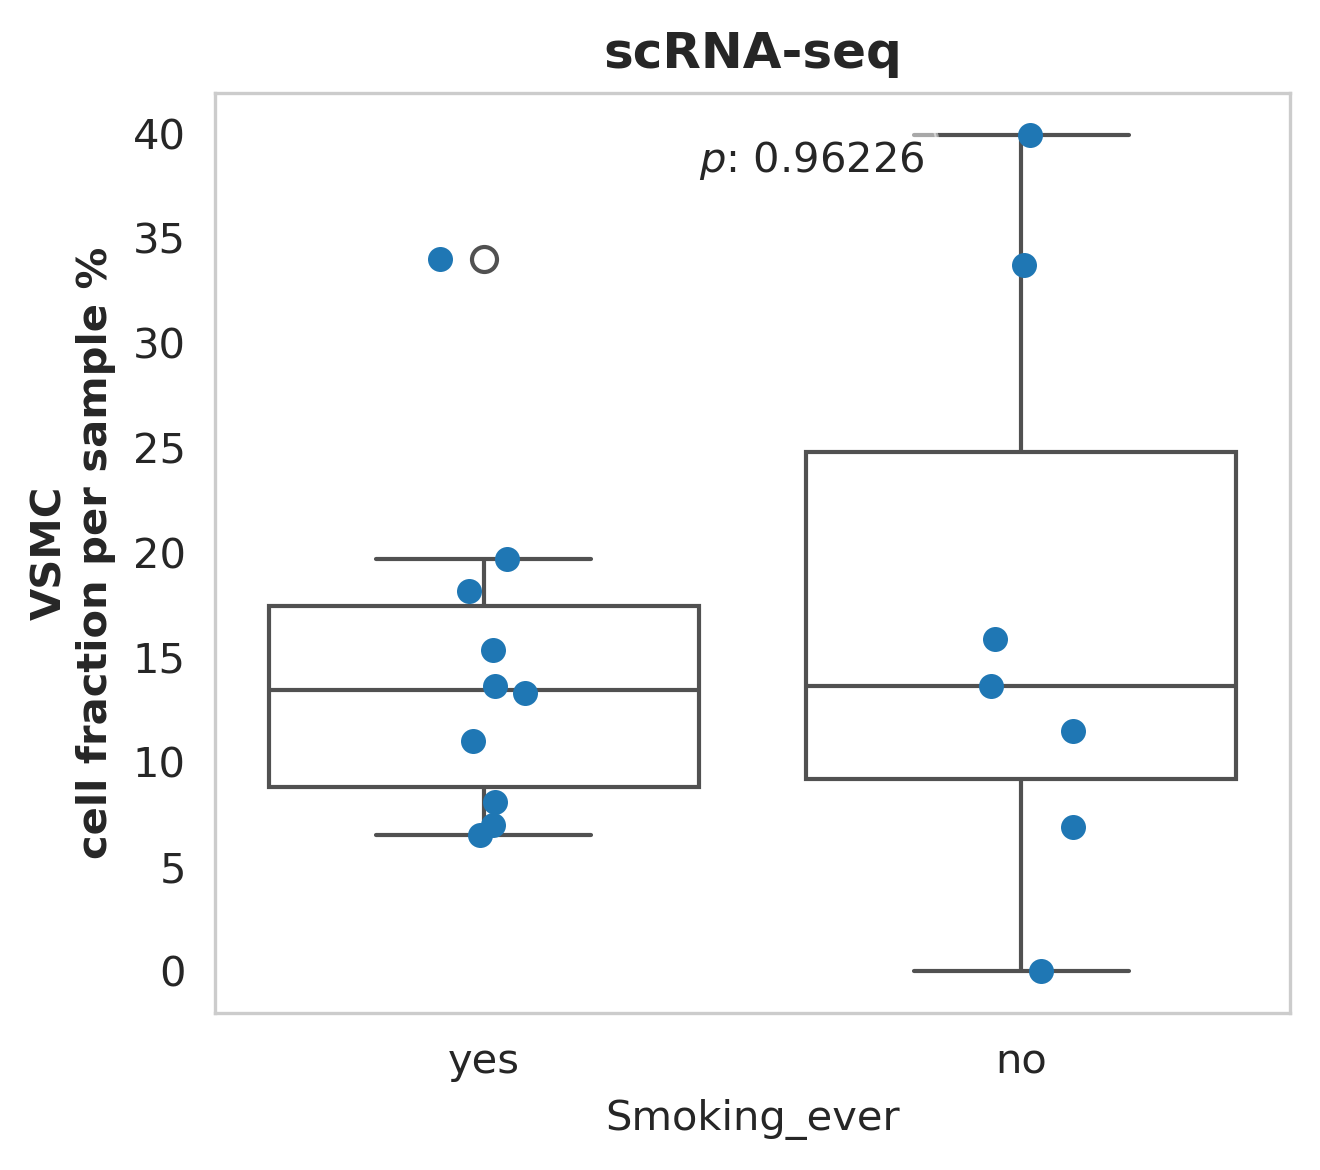

In [32]:
#adata.obs
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import pointbiserialr
from scipy.stats import mannwhitneyu, pearsonr, linregress
from scipy.stats import zscore
import warnings
warnings.filterwarnings("ignore")

meta_cols=['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                       'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes',
                       'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                       'PAD', 'ASA_stadium','Statin'][:]

meta_cols=['Smoking_ever']
fdr_sign_thr=1

for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]

        adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
        
        orig_samples=adata.obs.loc[:,'original_sample'].unique()
    
    
        color_var='final_low_level_celltype'
        color_var='final_high_level_celltype'
        
        l=[]
        for n,orig_sample in enumerate(orig_samples[:]):
            #print(orig_sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
            
            adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
    
            celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=True,dropna=False) * 100
            #celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=False,dropna=False)
            #celltype_freqs=adata_sample.obs.groupby('sample_region').apply(lambda x: x[color_var].value_counts(normalize=True,dropna=False))
            
            #if 'T-cell_0' in celltype_freqs.index:
            #    celltype_freqs=celltype_freqs.drop(['T-cell_0'],axis=0)
            l.append(celltype_freqs)
    
            
        sns.set_style("whitegrid", {'axes.grid' : False})
        
        ## Concatenate the frequencias of the individual samples + fill Na with 0
        cellt_freq_df=pd.concat(l,axis=1)
        cellt_freq_df.columns=orig_samples
        cellt_freq_df=cellt_freq_df.fillna(0)
    
        
        a=cellt_freq_df.T
        
        ## Split the 'D' or 'H' from the end of the index names, to match the metadata index names
        a.index=[id.split('_')[0] for id in a.index]
        #a = cellt_freq_df.apply(zscore).T
    
        sign_meta_coln_dict={}
        
        for cluster in a.columns:
            if 'VSMC' not in cluster:
                continue
            
            l,k=[],[]
            for met_coln in meta_cols:
                #print(met_coln)
                
                if np.issubdtype(metadata[met_coln].dtype, np.number):
                    pats_wo_nans=list(set(metadata[met_coln].dropna().index)&set(a.index))
                    
                    corr, p_value = pearsonr(a.loc[pats_wo_nans,cluster], metadata.loc[pats_wo_nans,met_coln])
                    #if p_value<0.05:
                     #   print(cluster,met_coln,corr, p_value)           
                    l.append(p_value)
                    k.append(met_coln)
                    #m.append(corr)
                    
                if np.issubdtype(metadata[met_coln].dtype, np.number)==False and metadata[met_coln].unique().shape[0]>1:
                    #corr, p_value = pointbiserialr( pd.factorize(metadata_.loc[a.index,met_coln])[0],a[cluster])
    
                    pats_wo_nans=list(set(metadata[met_coln].dropna().index)&set(a.index))
                    
                    #print(met_coln)
                    # Get values of the continuous variable grouped by binary variable
                    group1 = a.loc[pats_wo_nans,cluster][metadata.loc[pats_wo_nans, met_coln] == metadata.loc[pats_wo_nans,met_coln].unique()[0]]
                    group2 = a.loc[pats_wo_nans,cluster][metadata.loc[pats_wo_nans, met_coln] == metadata.loc[pats_wo_nans,met_coln].unique()[1]]
                    
                    # Perform Wilcoxon rank-sum test (equivalent to Mann-Whitney U)
                    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
                    #m.append(corr)
        
                    l.append(p_value)
                    k.append(met_coln)
    
            
            _, p_values_fdr = fdrcorrection(l, alpha=0.05, method='indep')
        
            sign_met_colnames=np.array(k)[p_values_fdr<fdr_sign_thr]
    
            if len(sign_met_colnames)>0:
                #print(cluster,sign_clust,p_values_fdr,sign_met_colnames)
                sign_meta_coln_dict[cluster]={}
                sign_meta_coln_dict[cluster]['sign_met_colnames']=sign_met_colnames
                sign_meta_coln_dict[cluster]['fdr']=p_values_fdr[p_values_fdr<fdr_sign_thr]
                sign_meta_coln_dict[cluster]['p_val_raw']=np.array(l)[p_values_fdr<fdr_sign_thr]
    
        
        ## Plot all the significant metadata columns with clusters
        n_plots=len(list(itertools.chain(*[sign_meta_coln_dict[cluster]['sign_met_colnames'] for cluster in  sign_meta_coln_dict.keys()])))
    
        ncols=3
        ncols=1
        nrows=int(np.ceil((n_plots)/ncols))
        fig=plt.figure(figsize=(4.5*ncols,4*nrows))
        #repr_key_ = repr_key.replace('radius_','radius\n')
        #fig.suptitle(f"scRNA-seq - Cell type fractions",y=1.05,fontweight='bold',fontsize=12)
    
        n=0
        
        for cluster in sign_meta_coln_dict.keys():
            
            sign_met_colnames=sign_meta_coln_dict[cluster]['sign_met_colnames']
    
            
            for i,sign_clust in enumerate(sign_met_colnames):
                #print(cluster,sign_clust,sign_meta_coln_dict[cluster]['p_val_raw'][i],sign_meta_coln_dict[cluster]['fdr'][i])
                
                fdr=sign_meta_coln_dict[cluster]['fdr'][i]
                ax=fig.add_subplot(nrows,ncols,n+1)
    
                dd=pd.concat([a.loc[:,cluster],metadata.loc[a.index,sign_clust]],axis=1)
    
                if np.issubdtype(metadata[sign_clust].dtype, np.number):
                    # Ensure x and y are pandas Series
                    x = dd[sign_clust]
                    y = dd[cluster]
    
                    # Plot scatter plot with regression line
                    sns.regplot(x=x, y=y, ax=ax,scatter_kws={'s': 6}, line_kws={'color': 'red'})
    
                    # Calculate linear regression statistics
                    slope, intercept, r_value, p_value, std_err = linregress(x, y)
                    r_squared = r_value**2
                                        
                    # Add R-squared and p-value to the plot
                    ax.text(0.65, 0.95, f'$R^2$: {r_squared:.2f}\n$p$: {p_value:.5f}\n$fdr$: {fdr:.5f}', 
                            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
                else:
                    sns.stripplot(data=dd,y=cluster,x=sign_clust,ax=ax,s=6)
                    sns.boxplot(data=dd,y=cluster,x=sign_clust,ax=ax,boxprops={'facecolor':'none'})
    
                    # Add R-squared and p-value to the plot
                    ax.text(0.45, 0.95, f'$p$: {fdr:.5f}', 
                            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
                
                ax.set_ylabel(f'{cluster}\ncell fraction per sample %',fontsize=10,fontweight='bold')
                #ax.set_title(sign_clust,fontweight='bold')
                ax.set_title('scRNA-seq',fontweight='bold')
                #ax.set_xlabel(None,fontweight='bold')
                n=n+1
                #plt.grid()
                
            plt.tight_layout()
    
            ## SAvefig
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            data_dir_=os.path.join(proc_dir, 'figure_plots','SFigQ')
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                            f"{ref_genome}_{intron_status}_assoc_with_smoking_ever_VSMC_{color_var}_boxplots.png")
            fig.savefig(fn, dpi=300, bbox_inches='tight')

            ## SAVE SOURCE DATAFRAME FOR PLOT
            source_df = dd.reset_index()
            source_df.columns=['original_sample','VSMC_cell_fraction','Smoking_ever']
            
            source_dir=os.path.join(proc_dir,'source_data','first_revision')
            os.makedirs(source_dir,exist_ok=True)
            
            if intron_status=='with_intron':                  
                fn=os.path.join(source_dir,'Suppl_Fig18B.xlsx')
                source_df.to_excel(fn)

In [30]:
dd['Smoking_ever'].value_counts(dropna=False)
dd

,VSMC,Smoking_ever
CAR3,13.636364,yes
CAR16,10.984848,yes
CAR12,11.486486,no
CAR9,33.740289,no
CAR1,6.527197,yes
CAR14,7.009346,yes
CAR5,39.950062,no
CAR6,34.011091,yes
CAR10,13.612565,no
CAR7,13.278008,yes


# CELL HIGH-LEVEL CELL COUNTS/PROPORTIONS

## scRNA-seq

### DEPRECATED - Fig.2

GRCh38-p14-Gencode_v44 with_intron
(14641, 28816)


/tmp/ipykernel_130975/2879442192.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


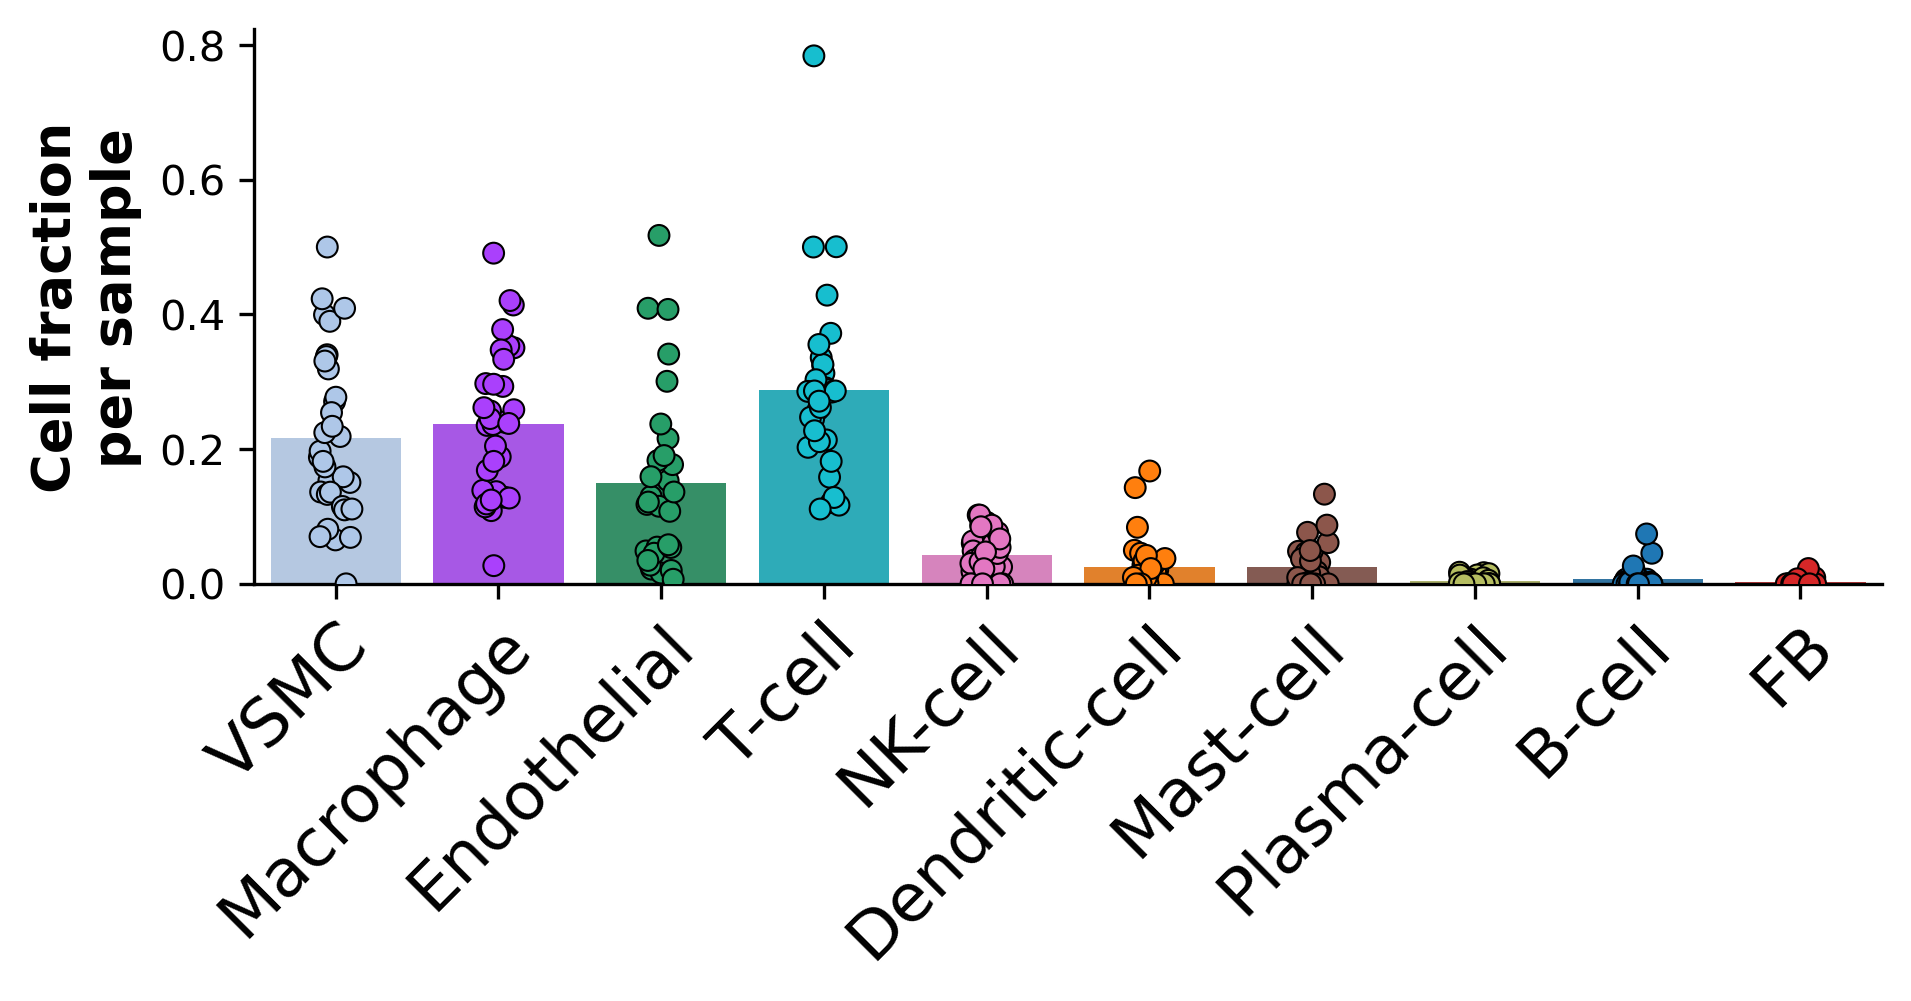

In [81]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               'T-cell':(23,190,207,255),
               'VSMC':(174,199,232,255)
              }

color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]
        print(adata.shape)


        for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][:1]:
            '''
            l=[]
            for scale_param in ['5','10','15','5|10|15'][:-1]:
                adata_subs=adata_dict_[scale_param][panel]
                adata_subs.obs['Scale parameter']=scale_param
        
                abs_counts=adata_subs.obs[cellt_coln].value_counts()
                norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
                count_df=pd.concat([abs_counts,norm_counts],axis=1)
                count_df['Scale parameter']=scale_param
                l.append(count_df)
            
            '''
            #hue_order=adata.obs[cellt_coln].value_counts().index.tolist()
            #hue_order=[]
            hue_order=['VSMC', 'T-cell', 'Macrophage', 'Endothelial', 'NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']
            hue_order=['VSMC', 'Macrophage', 'Endothelial', 'T-cell','NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']
            #print('hue_order',hue_order)
            #norm_counts=adata.obs[cellt_coln].value_counts(normalize=True)
            abs_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=False))#.reset_index()
            norm_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=True))#.reset_index()


            plot_df=pd.concat([abs_counts,norm_counts],axis=1)
            cond_df = adata.obs[['condition','original_sample']].drop_duplicates('original_sample').set_index('original_sample')
            plot_df['condition']=cond_df.loc[plot_df.reset_index()['original_sample'],'condition'].values


            # Add a pseudocount to avoid log(0)
            eps = 1e-6
            plot_df['proportion_pseudo'] = plot_df['proportion'] + eps
            
            # Compute geometric mean per sample
            geom_mean = (
                plot_df.groupby('original_sample')['proportion_pseudo']
                .apply(lambda x: np.exp(np.mean(np.log(x))))
                .rename('geom_mean')
            )
            
            # Merge back and compute CLR
            plot_df=plot_df.reset_index().set_index('original_sample')
            plot_df = plot_df.merge(geom_mean, on='original_sample', how='left')
            plot_df['CLR'] = np.log(plot_df['proportion_pseudo'] / plot_df['geom_mean'])
    
    
        
            
            met_colnames=['count','proportion','CLR'][1:2]
            met_coln_titles=['Cell count','Cell fraction\n per sample','CLR'][1:2]
            #print(plot_df)
            
            
            for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):
    
                fig,ax=plt.subplots(1,1,figsize=(7,2.4))
                #fig.suptitle('scRNA-seq',fontsize=14,fontweight='bold')
        
                sns.barplot(data=plot_df.reset_index(),
                            x=cellt_coln,
                            y=met_coln,color='dodgerblue',#alpha=0.7,
                            order=hue_order,
                            errorbar=None,
                            palette=color_palette)
                
                sns.stripplot(data=plot_df,
                             x=cellt_coln,
                            y=met_coln,color='dodgerblue',
                              #alpha=0.7,
                            order=hue_order,
                             edgecolor='black',
                              #hue='condition',
                              linewidth=0.5,
                             palette=color_palette,
                              #palette='Set2',
                             )
        
                #ax.set_ylim(None,np.quantile(plot_df[met_coln],1))
                
                # Rotate x-axis tick labels by 45 degrees
                x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
                x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
                ax.set_xticklabels(x_ticks)
                plt.xticks(rotation=45,fontsize=16,ha='right', rotation_mode='anchor')
                #ax.tick_params(axis='x',labelsize=16,labelrotation=45,ha='right', rotation_mode='anchor')
    
                ax.set_ylabel(met_coln_title,fontsize=13,fontweight='bold')
                ax.set_xlabel(None)
                ax.spines[['top','right']].set_visible(False)

                #ax.set_yscale('log')
                #ax.invert_yaxis()
           
      
                ## SAvefig    
                proc_dir='../../xenium_data/processed_data/baysor_processed_output'
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'{ref_genome}_{intron_status}_{cellt_coln}_{met_coln}_cell_counts.png')
                #fig.savefig(fn, dpi=300, bbox_inches='tight')

                
                ### Save source data for plot                 
                source_df=plot_df[['proportion']].rename(columns={'proportion':'cell_fraction'}).reset_index()
                
                source_dir=os.path.join(proc_dir,'source_data','first_revision')
                os.makedirs(source_dir,exist_ok=True)
                   
                fn=os.path.join(source_dir,'Fig2F.xlsx')           
                #source_df.to_excel(fn)
                


### Fig. 2F

GRCh38-p14-Gencode_v44 with_intron
(14641, 28816)


/tmp/ipykernel_5929/4264964517.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(
/tmp/ipykernel_5929/4264964517.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


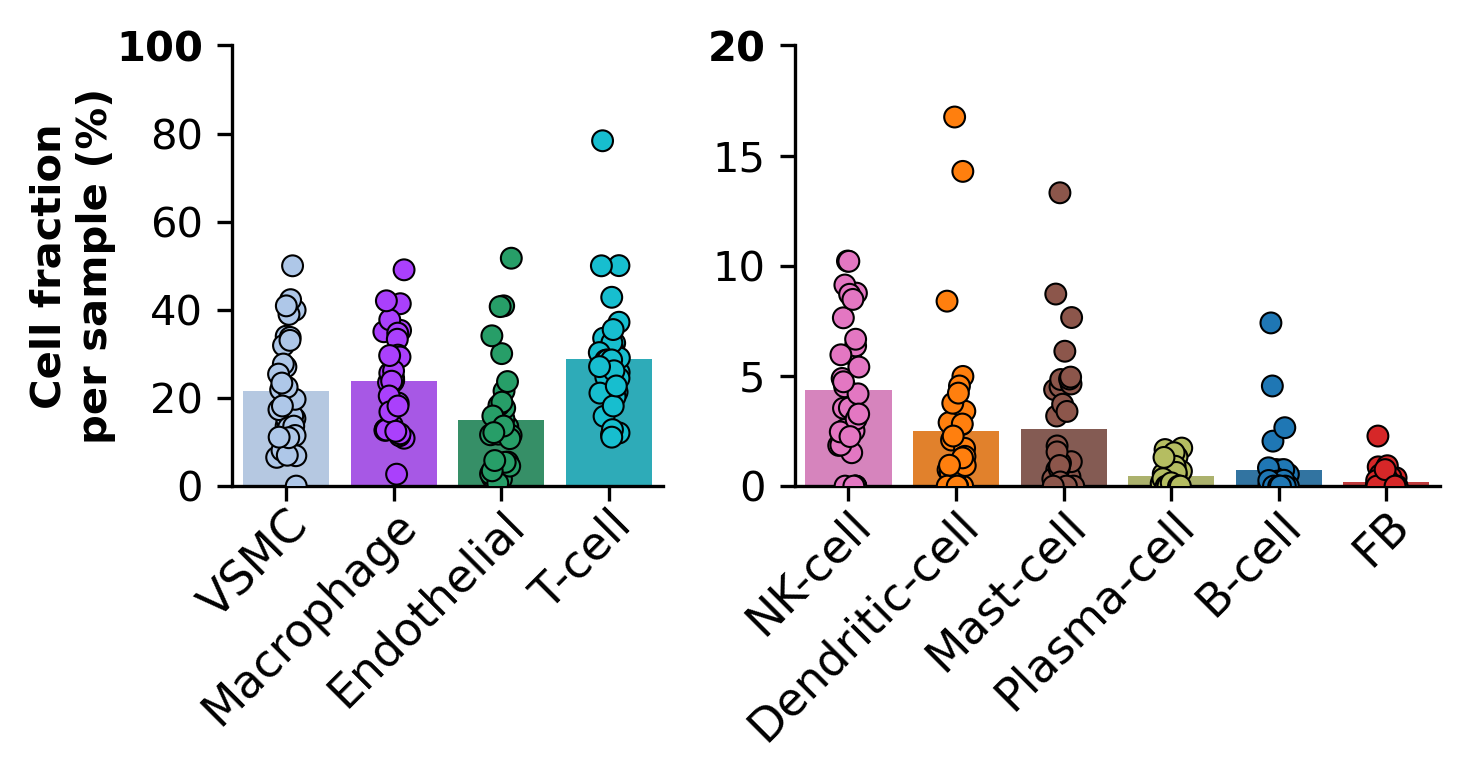

In [9]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               'T-cell':(23,190,207,255),
               'VSMC':(174,199,232,255)
              }

color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]
        print(adata.shape)


        for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][:1]:
            '''
            l=[]
            for scale_param in ['5','10','15','5|10|15'][:-1]:
                adata_subs=adata_dict_[scale_param][panel]
                adata_subs.obs['Scale parameter']=scale_param
        
                abs_counts=adata_subs.obs[cellt_coln].value_counts()
                norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
                count_df=pd.concat([abs_counts,norm_counts],axis=1)
                count_df['Scale parameter']=scale_param
                l.append(count_df)
            
            '''
            #hue_order=adata.obs[cellt_coln].value_counts().index.tolist()
            #hue_order=[]
            hue_order=['VSMC', 'T-cell', 'Macrophage', 'Endothelial', 'NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']
            hue_order=['VSMC', 'Macrophage', 'Endothelial', 'T-cell','NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']
            #print('hue_order',hue_order)
            #norm_counts=adata.obs[cellt_coln].value_counts(normalize=True)
            abs_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=False))#.reset_index()
            norm_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=True))*100#.reset_index()
            plot_df=pd.concat([abs_counts,norm_counts],axis=1)
            cond_df = adata.obs[['condition','original_sample']].drop_duplicates('original_sample').set_index('original_sample')
            plot_df['condition']=cond_df.loc[plot_df.reset_index()['original_sample'],'condition'].values
    
    
        
            
            met_colnames=['count','proportion'][1:]
            met_coln_titles=['Cell count','Cell fraction\nper sample (%)'][1:]
            #print(plot_df)
            

            # --- split groups ---
            split_label = 'T-cell'
            split_index = hue_order.index(split_label)
            left_cells = hue_order[:split_index+1]
            right_cells = hue_order[split_index+1:]
            
            for met_coln_title, met_coln in zip(met_coln_titles, met_colnames):
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7), sharey=False, 
                                               gridspec_kw={'width_ratios': [len(left_cells), len(right_cells)]})
            
                # --- left (high counts) ---
                sns.barplot(
                    data=plot_df.reset_index().query(f"{cellt_coln} in @left_cells"),
                    x=cellt_coln, y=met_coln, order=left_cells,
                    palette=color_palette, ax=ax1, errorbar=None)
                
                sns.stripplot(
                    data=plot_df.reset_index().query(f"{cellt_coln} in @left_cells"),
                    x=cellt_coln, y=met_coln, order=left_cells,
                    palette=color_palette, ax=ax1, edgecolor='black', linewidth=0.5)
                
                ax1.set_ylabel(met_coln_title, fontsize=10, labelpad=0,fontweight='bold')
                ax1.set_xlabel(None)
                ax1.spines[['top','right']].set_visible(False)
                ax1.set_xticklabels(
                    [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in left_cells],
                    rotation=45, ha='right', fontsize=11,rotation_mode='anchor')
                ax1.tick_params(axis='x', which='major', pad=0.5)

                ax1.set_ylim(0, 100)#plot_df.query(f"{cellt_coln} in @left_cells")[met_coln].max() * 1.1)

                ymin, ymax = ax1.get_ylim()
                ticks = [t for t in ax1.get_yticks() if ymin <= t <= ymax]
                ax1.set_yticks(ticks)
                ax1.get_yticklabels()[-1].set_fontweight('bold')

                '''
                # Move the axis spine and ticks to the right
                ax1.yaxis.tick_right()
                ax1.yaxis.set_label_position("left")  # keep label on left
                ax1.spines["right"].set_position(("outward", 0))  # or "zero" / specific points
                ax1.spines["right"].set_visible(True)
                ax1.spines["left"].set_visible(False)  # optional
                '''
            
                # --- right (low counts, zoomed) ---
                sns.barplot(
                    data=plot_df.reset_index().query(f"{cellt_coln} in @right_cells"),
                    x=cellt_coln, y=met_coln, order=right_cells,
                    palette=color_palette, ax=ax2, errorbar=None
                )
                sns.stripplot(
                    data=plot_df.reset_index().query(f"{cellt_coln} in @right_cells"),
                    x=cellt_coln, y=met_coln, order=right_cells,
                    palette=color_palette, ax=ax2, edgecolor='black', linewidth=0.5
                )
                #ax2.set_ylabel(met_coln_title, fontsize=13, fontweight='bold')
                ax2.set_ylabel(None)
                ax2.set_xlabel(None)
                ax2.spines[['top','right']].set_visible(False)
                ax2.set_xticklabels(
                    [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in right_cells],
                    rotation=45, ha='right', fontsize=11,rotation_mode='anchor')

                ax2.tick_params(axis='x', which='major', pad=0.5)
                
                ymin, ymax = ax1.get_ylim()
                ticks = [t for t in ax2.get_yticks() if ymin <= t <= ymax]
                ax2.set_yticks(ticks)
                ax2.get_yticklabels()[-1].set_fontweight('bold')
            
                # Adjust y-limits dynamically
                
                #ax2.set_ylim(0, plot_df.query(f"{cellt_coln} in @right_cells")[met_coln].max() * 1.2)
                #plt.xticks(rotation=45,#fontsize=16,
                #           ha='right', rotation_mode='anchor')
            
                # Remove the gap between subplots and draw a vertical divider
                fig.subplots_adjust(wspace=-0.9)
                divider_x = ax1.get_position().x1
                #fig.text(divider_x, 0.5, '', va='center', ha='center', color='black',
                #         fontsize=10, rotation=90, fontweight='bold')
                #fig.add_artist(plt.Line2D([divider_x, divider_x], [0.15, 0.85],
                #                          transform=fig.transFigure, color='black', lw=1))

                #ax1.set_yscale('log')
                #ax2.set_yscale('log')
            
                plt.tight_layout()
                plt.show()

                ## SAvefig    
                proc_dir='../../xenium_data/processed_data/baysor_processed_output'
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'{ref_genome}_{intron_status}_{cellt_coln}_{met_coln}_cell_counts.png')
                fig.savefig(fn, dpi=300, bbox_inches='tight')

                
                ### Save source data for plot                 
                source_df=plot_df[['proportion']].rename(columns={'proportion':'cell_fraction'}).reset_index()
                
                source_dir=os.path.join(proc_dir,'source_data','first_revision')
                os.makedirs(source_dir,exist_ok=True)
                   
                fn=os.path.join(source_dir,'Fig2F.xlsx')           
                #source_df.to_excel(fn)
                


### Mean  per-sample cell type fractions

In [27]:
for intron_status in ['with_intron','without_intron'][:]:  
    for ref_genome in ref_genomes[:1]:
        print('=====',ref_genome,intron_status,'=====')
        adata=adata_dict[intron_status][ref_genome]


        for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][:1]:
            '''
            l=[]
            for scale_param in ['5','10','15','5|10|15'][:-1]:
                adata_subs=adata_dict_[scale_param][panel]
                adata_subs.obs['Scale parameter']=scale_param
        
                abs_counts=adata_subs.obs[cellt_coln].value_counts()
                norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
                count_df=pd.concat([abs_counts,norm_counts],axis=1)
                count_df['Scale parameter']=scale_param
                l.append(count_df)
            
            '''
            hue_order=adata.obs[cellt_coln].value_counts().index.tolist()
            #norm_counts=adata.obs[cellt_coln].value_counts(normalize=True)
            abs_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=False))#.reset_index()
            norm_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=True))#.reset_index()
            plot_df=pd.concat([abs_counts,norm_counts],axis=1)
            cond_df = adata.obs[['condition','original_sample']].drop_duplicates('original_sample').set_index('original_sample')
            plot_df['condition']=cond_df.loc[plot_df.reset_index()['original_sample'],'condition'].values


            for cellt in plot_df.index.get_level_values('final_high_level_celltype').unique():
                print(cellt,plot_df.loc[plot_df.index.get_level_values('final_high_level_celltype')==cellt,'proportion'].mean().round(4)*100)
            
            plot_df.reset_index()['original_sample'].unique()
            print('========\n')

===== GRCh38-p14-Gencode_v44 with_intron =====
T-cell 28.83
Macrophage 23.74
Endothelial 14.92
VSMC 21.69
NK-cell 4.35
Dendritic-cell 2.52
FB 0.21
B-cell 0.72
Mast-cell 2.5700000000000003
Plasma-cell 0.44

===== GRCh38-p14-Gencode_v44 without_intron =====
T-cell 24.58
Macrophage 25.64
Endothelial 15.21
VSMC 23.72
NK-cell 4.61
Dendritic-cell 2.67
B-cell 0.33
FB 0.26
Mast-cell 2.4699999999999998
Plasma-cell 0.49



## Bulk

### DEPRECATED - Fig.2 

In [ ]:
bulk_cell_fractions=pd.read_csv('../../data/sa_for_Daniel.csv',index_col=0)
plot_df = bulk_cell_fractions[[*color_palette]].mean().reset_index()
#plot_df.columns=['Celltype','proportion']
plot_df = bulk_cell_fractions[[*color_palette]]
plot_df = np.log((plot_df + 1e-6).div(plot_df.add(1e-6).apply(lambda x: np.exp(np.mean(np.log(x))), axis=1), axis=0))

#for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):

fig,ax=plt.subplots(1,1,figsize=(7,2.4))
#fig.suptitle('Bulk RNA-seq',fontsize=14,fontweight='bold')

sns.barplot(data=plot_df,#.reset_index(),
            #x='Celltype',
            #y='proportion',
            color='dodgerblue',#alpha=0.7,
            order=hue_order,
           palette=color_palette)

sns.stripplot(data=plot_df.melt(),
                    x='variable',
                    y='value',color='dodgerblue',#alpha=0.7,
                     order=hue_order,
                    edgecolor='black',
                      linewidth=0.5,
                    palette=color_palette)

#ax.set_ylim(None,np.quantile(plot_df[met_coln],1))

# Rotate x-axis tick labels by 45 degrees
x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
ax.set_xticklabels(x_ticks)
plt.xticks(rotation=45,fontsize=16,ha='right', rotation_mode='anchor')

ax.set_ylabel('Cell fraction from\ndeconvolution',fontsize=14,fontweight='bold')
ax.set_ylabel('Cell fraction per\nsample (deconv.)',fontsize=13,fontweight='bold')
ax.set_xlabel(None)
ax.spines[['top','right']].set_visible(False)


## SAvefig    
proc_dir='../../xenium_data/processed_data/baysor_processed_output'
os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'bulk_cell_proportions.png')
fig.savefig(fn, dpi=300, bbox_inches='tight')

### Save source data for plot                 
source_df = plot_df.reset_index().melt(id_vars=['Data_ID'])
source_df.columns=['original_sample','final_high_level_celltype','celltype']

source_dir=os.path.join(proc_dir,'source_data','first_revision')
os.makedirs(source_dir,exist_ok=True)
   
fn=os.path.join(source_dir,'Fig2G.xlsx')           
source_df.to_excel(fn)


### Fig.2G - plaque + control samples

/tmp/ipykernel_5929/3672525869.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(
/tmp/ipykernel_5929/3672525869.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


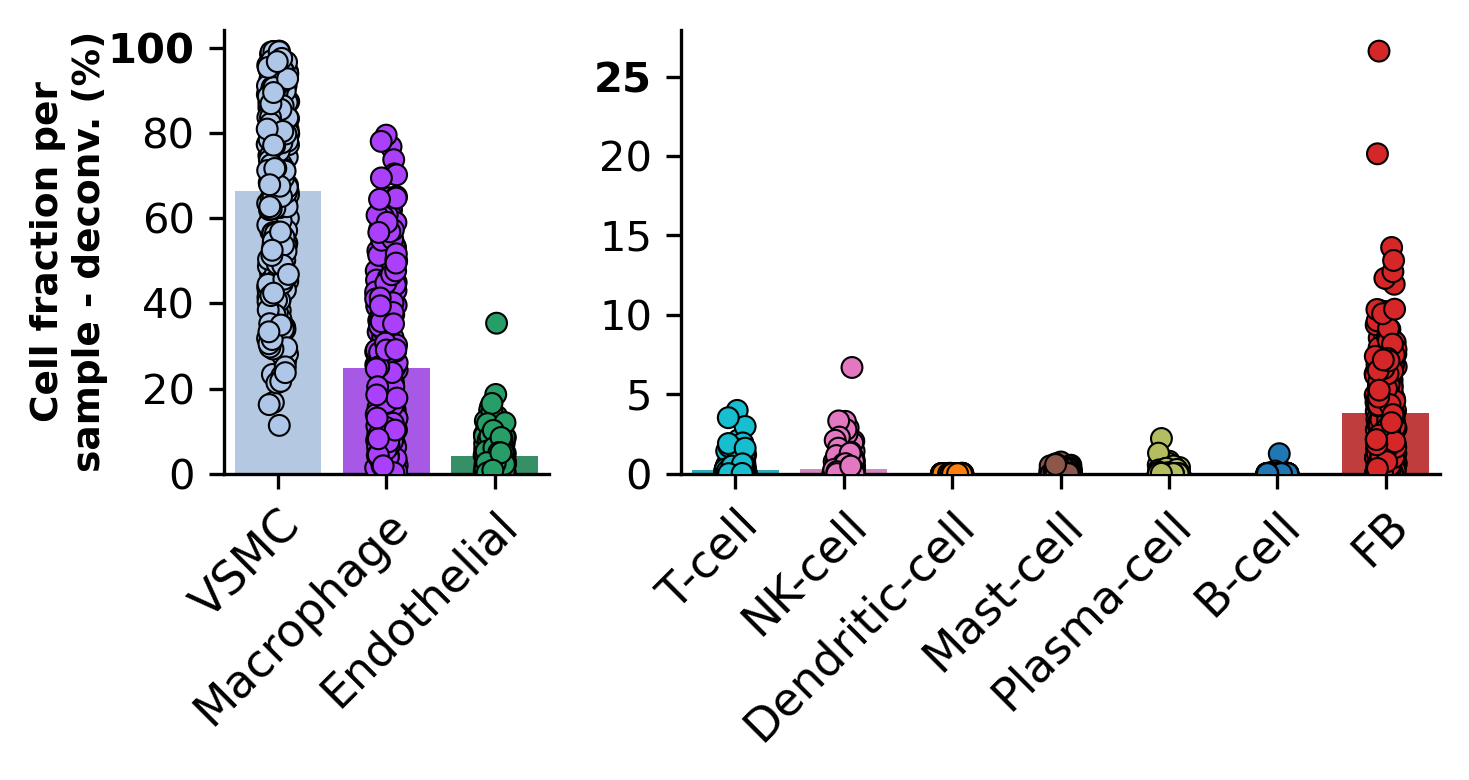

In [11]:
bulk_cell_fractions=pd.read_csv('../../data/sa_for_Daniel.csv',index_col=0)
plot_df = bulk_cell_fractions[[*color_palette]].mean().reset_index()
#plot_df.columns=['Celltype','proportion']
plot_df = bulk_cell_fractions[[*color_palette]]*100


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               'T-cell':(23,190,207,255),
               'VSMC':(174,199,232,255)
              }
color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


hue_order=['VSMC', 'Macrophage', 'Endothelial', 'T-cell','NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']


# --- split groups ---
split_label = 'Endothelial'
split_index = hue_order.index(split_label)
left_cells = hue_order[:split_index+1]
right_cells = hue_order[split_index+1:]

for met_coln_title, met_coln in zip(met_coln_titles, met_colnames):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7), sharey=False, 
                                   gridspec_kw={'width_ratios': [len(left_cells), len(right_cells)]})

    # --- left (high counts) ---
    sns.barplot(
        data=plot_df.loc[:,plot_df.columns.isin(left_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=left_cells,
        palette=color_palette, ax=ax1, errorbar=None
    )
    sns.stripplot(
        data=plot_df.loc[:,plot_df.columns.isin(left_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=left_cells,
        palette=color_palette, ax=ax1, edgecolor='black', linewidth=0.5
    )
    #ax1.set_ylabel(met_coln_title, fontsize=13, fontweight='bold')
    ax1.set_ylabel('Cell fraction per\nsample - deconv. (%)',labelpad=0,fontsize=9,fontweight='bold')
    ax1.set_xlabel(None)
    ax1.spines[['top','right']].set_visible(False)
    ax1.set_xticklabels(
        [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in left_cells],
        rotation=45, ha='right', fontsize=11,rotation_mode='anchor')

    ymin, ymax = ax1.get_ylim()
    ticks = [t for t in ax1.get_yticks() if ymin <= t <= ymax]
    ax1.set_yticks(ticks)
    ax1.get_yticklabels()[-1].set_fontweight('bold')

    # --- right (low counts, zoomed) ---
    sns.barplot(
        data=plot_df.loc[:,plot_df.columns.isin(right_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=right_cells,
        palette=color_palette, ax=ax2, errorbar=None)
    sns.stripplot(
        data=plot_df.loc[:,plot_df.columns.isin(right_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=right_cells,
        palette=color_palette, ax=ax2, edgecolor='black', linewidth=0.5)
    
    #ax2.set_ylabel(met_coln_title, fontsize=13, fontweight='bold')
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    ax2.spines[['top','right']].set_visible(False)
    ax2.set_xticklabels(
        [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in right_cells],
        rotation=45, ha='right', fontsize=11,rotation_mode='anchor')

    ymin, ymax = ax2.get_ylim()
    ticks = [t for t in ax2.get_yticks() if ymin <= t <= ymax]
    ax2.set_yticks(ticks)
    ax2.get_yticklabels()[-1].set_fontweight('bold')


    # Adjust y-limits dynamically
    #ax1.set_ylim(0, plot_df.loc[:,plot_df.columns.isin(left_cells)].max().max() * 1.1)
    #ax2.set_ylim(0, plot_df.loc[:,plot_df.columns.isin(right_cells)].max().max()  * 1.1)


    # Remove the gap between subplots and draw a vertical divider
    fig.subplots_adjust(wspace=-0.9)
    divider_x = ax1.get_position().x1
    #fig.text(divider_x, 0.5, '', va='center', ha='center', color='black',
    #         fontsize=10, rotation=90, fontweight='bold')
    #fig.add_artist(plt.Line2D([divider_x, divider_x], [0.15, 0.85],
    #                          transform=fig.transFigure, color='black', lw=1))

    plt.tight_layout()

    ax2.get_yticklabels()[-1].set_fontweight('bold')
    plt.show()


## SAvefig    
proc_dir='../../xenium_data/processed_data/baysor_processed_output'
os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'bulk_cell_proportions.png')
fig.savefig(fn, dpi=300, bbox_inches='tight')

### Save source data for plot                 
source_df = plot_df.reset_index().melt(id_vars=['Data_ID'])
source_df.columns=['original_sample','final_high_level_celltype','celltype']

source_dir=os.path.join(proc_dir,'source_data','first_revision')
os.makedirs(source_dir,exist_ok=True)
   
fn=os.path.join(source_dir,'Fig2G.xlsx')           
#source_df.to_excel(fn)



In [130]:
 ax2.get_yticklabels()

[Text(0, 0.0, '0'),
 Text(0, 10.0, '10'),
 Text(0, 20.0, '20'),
 Text(0, 30.0, '30')]

### Fig.2H_I - plaque control samples separately

Control (65, 61)


/tmp/ipykernel_5929/3043465055.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(
/tmp/ipykernel_5929/3043465055.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


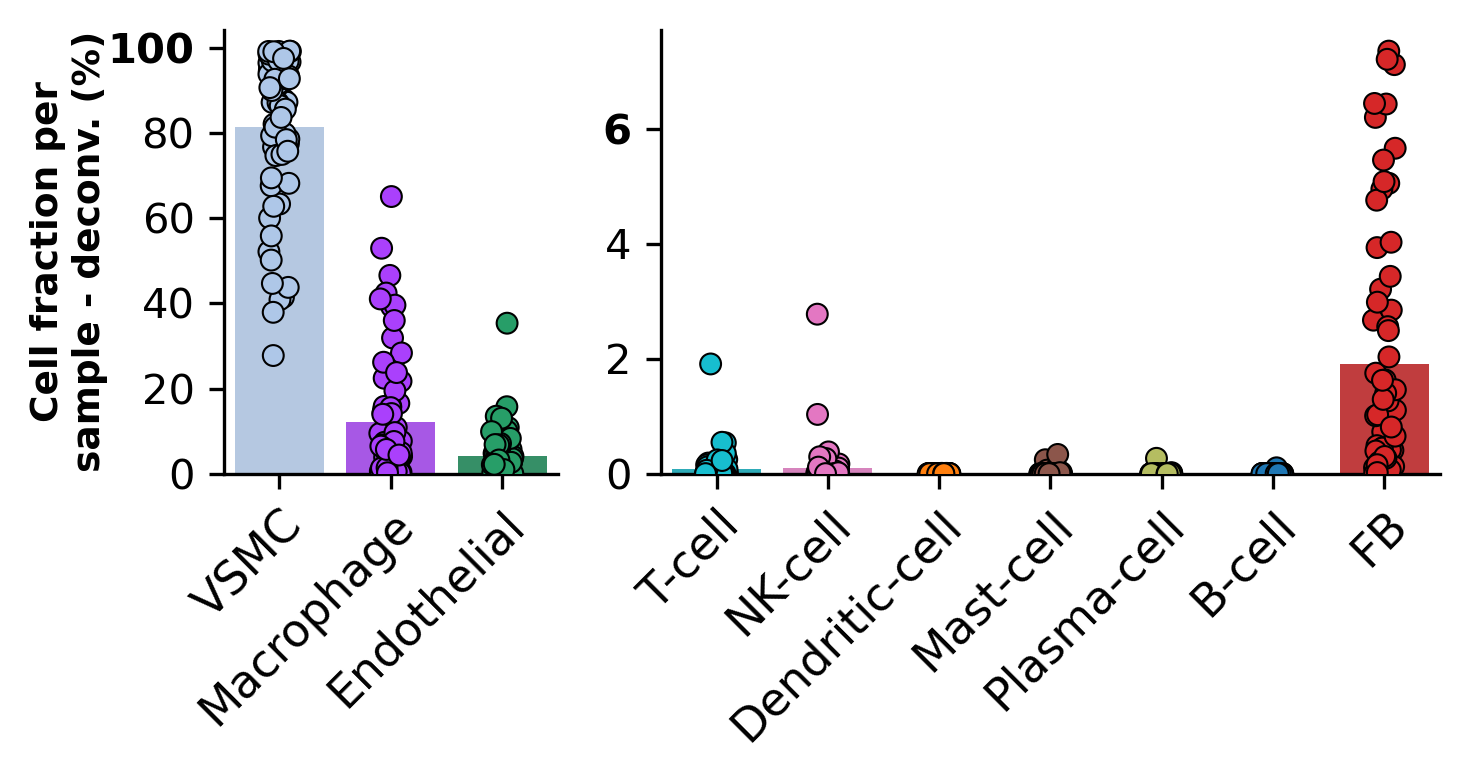

Plaque (232, 61)


/tmp/ipykernel_5929/3043465055.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(
/tmp/ipykernel_5929/3043465055.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


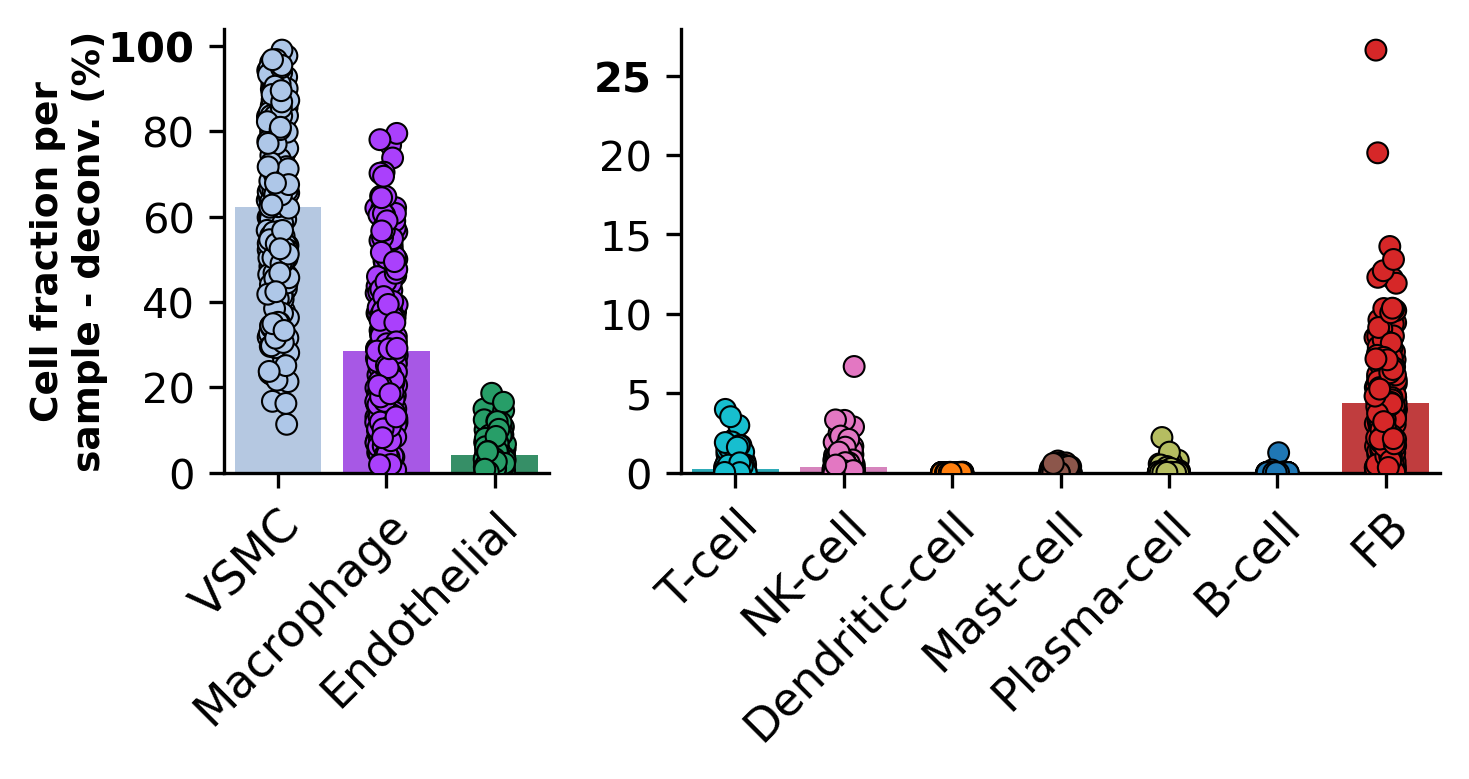

In [12]:
bulk_cell_fractions=pd.read_csv('../../data/sa_for_Daniel.csv',index_col=0)


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               'T-cell':(23,190,207,255),
               'VSMC':(174,199,232,255)
              }
color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


#plot_df = bulk_cell_fractions[[*color_palette]].mean().reset_index()
#plot_df.columns=['Celltype','proportion']
plot_df = bulk_cell_fractions[[*color_palette]]*100

hue_order=['VSMC', 'Macrophage', 'Endothelial', 'T-cell','NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']


# --- split groups ---
split_label = 'Endothelial'
split_index = hue_order.index(split_label)
left_cells = hue_order[:split_index+1]
right_cells = hue_order[split_index+1:]

for status,df in bulk_cell_fractions.groupby('status'):
    print(status,df.shape)
    plot_df = df[[*color_palette]]*100

    #for met_coln_title, met_coln in zip(met_coln_titles, met_colnames):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7), sharey=False, 
                                   gridspec_kw={'width_ratios': [len(left_cells), len(right_cells)]})

    # --- left (high counts) ---
    sns.barplot(
        data=plot_df.loc[:,plot_df.columns.isin(left_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=left_cells,
        palette=color_palette, ax=ax1, errorbar=None
    )
    sns.stripplot(
        data=plot_df.loc[:,plot_df.columns.isin(left_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=left_cells,
        palette=color_palette, ax=ax1, edgecolor='black', linewidth=0.5
    )
    #ax1.set_ylabel(met_coln_title, fontsize=13, fontweight='bold')
    ax1.set_ylabel('Cell fraction per\nsample - deconv. (%)',fontsize=9,labelpad=0,fontweight='bold')
    ax1.set_xlabel(None)
    ax1.spines[['top','right']].set_visible(False)
    ax1.set_xticklabels(
        [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in left_cells],
        rotation=45, ha='right', fontsize=11,rotation_mode='anchor')
    
    ymin, ymax = ax1.get_ylim()
    ticks = [t for t in ax1.get_yticks() if ymin <= t <= ymax]
    ax1.set_yticks(ticks)
    ax1.get_yticklabels()[-1].set_fontweight('bold')

    # --- right (low counts, zoomed) ---
    sns.barplot(
        data=plot_df.loc[:,plot_df.columns.isin(right_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=right_cells,
        palette=color_palette, ax=ax2, errorbar=None
    )
    sns.stripplot(
        data=plot_df.loc[:,plot_df.columns.isin(right_cells)],
        #x=cellt_coln, 
        #y=met_coln, 
        order=right_cells,
        palette=color_palette, ax=ax2, edgecolor='black', linewidth=0.5
    )
    #ax2.set_ylabel(met_coln_title, fontsize=13, fontweight='bold')
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    ax2.spines[['top','right']].set_visible(False)
    ax2.set_xticklabels(
        [label.replace('_mixed_cell', '\nmixed_cell').replace('/', '/\n') for label in right_cells],
        rotation=45, ha='right', fontsize=11,rotation_mode='anchor')

    ymin, ymax = ax2.get_ylim()
    ticks = [t for t in ax2.get_yticks() if ymin <= t <= ymax]
    ax2.set_yticks(ticks)
    ax2.get_yticklabels()[-1].set_fontweight('bold')

    # Adjust y-limits dynamically
    #ax1.set_ylim(0, plot_df.query(f"{cellt_coln} in @left_cells")[met_coln].max() * 1.1)
    #ax2.set_ylim(0, plot_df.query(f"{cellt_coln} in @right_cells")[met_coln].max() * 1.1)
    #plt.xticks(rotation=45,#fontsize=16,
    #           ha='right', rotation_mode='anchor')

    # Remove the gap between subplots and draw a vertical divider
    fig.subplots_adjust(wspace=-0.9)
    divider_x = ax1.get_position().x1
    #fig.text(divider_x, 0.5, '', va='center', ha='center', color='black',
    #         fontsize=10, rotation=90, fontweight='bold')
    #fig.add_artist(plt.Line2D([divider_x, divider_x], [0.15, 0.85],
    #                          transform=fig.transFigure, color='black', lw=1))

    plt.tight_layout()
    plt.show()


    ## Save figure
    if status=='Control':
   
        proc_dir='../../xenium_data/processed_data/baysor_processed_output'
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_fraction_deconvolution_controls'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_fraction_deconvolution_controls',f'cell_fractions.png')
        fig.savefig(fn, dpi=300, bbox_inches='tight')

    ## Save figure
    if status=='Plaque':
         
        proc_dir='../../xenium_data/processed_data/baysor_processed_output'
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_fraction_deconvolution_plaques'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_fraction_deconvolution_plaques',f'cell_fractions.png')
        fig.savefig(fn, dpi=300, bbox_inches='tight')

    
    ### Save source data for plot                 
    source_df = plot_df.reset_index().melt(id_vars=['Data_ID'])
    source_df.columns=['original_sample','celltype','cell_fraction']
    
    source_dir=os.path.join(proc_dir,'source_data','first_revision')
    os.makedirs(source_dir,exist_ok=True)

    if status=='Control':
        fn=os.path.join(source_dir,'Fig2H.xlsx')  

    if status=='Plaque':
        fn=os.path.join(source_dir,'Fig2I.xlsx')  
    
    #source_df.to_excel(fn)



In [48]:
plot_df.reset_index().melt(id_vars=['Data_ID'])

,Data_ID,variable,value
0,129888,B-cell,1.360695e-09
1,129913,B-cell,1.589938e-05
2,129915,B-cell,1.155758e-03
3,130002,B-cell,5.225038e-10
4,130003,B-cell,1.644980e-07
...,...,...,...
2315,23L011083,VSMC,2.373056e-01
2316,23L011084,VSMC,1.622178e-01
2317,23L011085,VSMC,5.249367e-01
2318,23L011087,VSMC,6.789872e-01


# DGE ANALYSIS

## PSEUDOBULK ACROSS ALL CELLTYPES

### Run DGE

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
#warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)
from itertools import chain
from tqdm import tqdm



## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'


cellt_var='final_low_level_celltype'
coln_for_dge_list=['stability','condition','symptomatic','Smoking_ever','Hypertension', 'Diabetes', 'Dyslipidemia','CHD','PAD','Sex']#,'symptomatic',]

coln_for_dge_list =['condition','Smoking_ever', 'AHA classification','Hypertension', 'Diabetes', 'Sex', 'Symptomatic', 'Stability', 'Rupture','ASA_stadium',
                        'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation','PAD','Statin']

for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    #adata=adata_dict_filt[ref_genome]
    adata.X=adata.layers['acosh']

    #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
    
    ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####

    for coln_for_dge in coln_for_dge_list[1:]:
    #for coln_for_dge in coln_for_dge_list[2:]:

        if coln_for_dge!='condition':
            adata_=adata[#(~adata.obs['original_sample'].str.contains('_H'))\&
                        (~adata.obs[coln_for_dge].isna())\
                        ,:].copy()

        if coln_for_dge=='condition':
            adata_=adata[#adata.obs['patient'].isin(['P1','P2','P3','P4'])\&
                         (~adata.obs[coln_for_dge].isna()),:].copy()
        
        dge_conditions=adata_.obs[coln_for_dge].unique()

        l=[]
        for de_method in de_methods[:1]:
            print(f'\nRunning DGE with {de_method} as DE method - variable for DGE: {coln_for_dge}\n')
                  

            #for celltype in adata_.obs[cellt_var].unique()[:]:
    
            adata_dge=adata_.copy() #adata_[adata_.obs[cellt_var]==celltype,:].copy()
            print(adata_dge.shape)

            cell_counts_per_cat=adata_dge.obs[coln_for_dge].value_counts(dropna=False)
            if any(cell_counts_per_cat.values<2):
                print(f'DGE not possible for {celltype}, only {cell_counts_per_cat[cell_counts_per_cat<2].values[0]} cells in cluster "{cell_counts_per_cat[cell_counts_per_cat<2].index.tolist()[0]}"')
                continue

            if adata_dge.obs[coln_for_dge].unique().shape[0] < dge_conditions.shape[0]:
                print(f'DGE not possible for {celltype}, only cells with condition {adata_dge.obs[coln_for_dge].unique()}, expected conditions: {dge_conditions}')
                continue
                
            clusts_to_compare=adata_dge.obs[coln_for_dge].unique().tolist()

            if any(cell_counts_per_cat.values<2):
                clusts_to_compare=cell_counts_per_cat[cell_counts_per_cat.values>2].index.tolist()
            else:
                clusts_to_compare=adata_dge.obs[coln_for_dge].unique().tolist()

    
            if de_method!='deseq2':
                # Check the number of cells in each group
                #group_counts = adata_dge.obs[coln_for_dge].value_counts()
                #print(sample_region,celltype,group_counts)
                dge_df=run_scanpy_dge(adata_dge,coln_for_dge,clusts_to_compare,de_method)
            
    
            if de_method=='deseq2':

                show_r_output=False 
                if coln_for_dge!='condition':
                    cols_to_correct_for=['batch','patient','condition']
                    
                if coln_for_dge=='condition':
                    cols_to_correct_for=['batch','patient']

                ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                cols_to_sum_by=['original_sample']
                pat_idx=adata_dge.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
        
                l_=[]
                for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                    l_.append(pd.DataFrame(adata_dge.layers['cellbender'][idx[0],:].sum(axis=0)))
                
                b=pd.concat(l_)
                low_gene_filter=~(b<10).all().values
                adata_dge_filt=adata_dge[:,low_gene_filter].copy()

                adata_dge_filt.obs=adata_dge_filt.obs.drop(columns='scpoli_uncert')
                clusts_to_compare=adata_dge_filt.obs[coln_for_dge].unique().tolist()

                ## If there are only two clusters to compare to each other, drop one as the other comparison is the same with a negative sign
                if len(clusts_to_compare)==2:
                    clusts_to_compare_=clusts_to_compare[:1]
                    
                if len(clusts_to_compare)>2:
                    clusts_to_compare_=clusts_to_compare
    
                dge_df=run_deseq2_dge(adata_dge_filt,coln_for_dge,clusts_to_compare_,cols_to_correct_for,show_r_output)
                
                if dge_df is None:
                    print(f'Error with comparison {coln_for_dge}! Skipping to next one!')
                    continue

                if len(clusts_to_compare)==2:
                    dge_df['cluster']=f'{clusts_to_compare[0]}_vs_{clusts_to_compare[1]}'
  

            #dge_df['celltype']=celltype
            dge_df=dge_df[dge_df['padj']<0.05]       
            l.append(dge_df)
            print('dge_df shape',dge_df.shape)
    
        if len(l)>0:    
            dge_df_concat=pd.concat(l,axis=0)
            
            if len(dge_df_concat['cluster'].unique())==2:
    
                clusts=dge_df_concat['cluster'].unique()
                dge_df_concat=dge_df_concat[dge_df_concat['cluster'].isin(clusts[1:])]
                dge_df_concat['cluster']=f'{clusts[1]}_vs_{clusts[0]}'
        
            ## Save the DGE result of given subclustering resolution
            dge_proc_dir='../../data/scRNA_DGE'
            os.makedirs(dge_proc_dir,exist_ok=True)
            #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
            fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_pooled_dge_results.csv.gz')
            dge_df_concat.to_csv(fn,compression='gzip')
    
    

### Plot DGE results

In [ ]:
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

## Load Xenium gene panels information
gene_info=pd.read_excel('../../xenium_data/Info about XENIUM panels_060923.xlsx')

log2FC_thr=0.5
fdr_lev=0.05
padj_thr=-np.log10(fdr_lev)
dge_proc_dir='../../data/scRNA_DGE'

## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'

de_methods=['deseq2','wilcoxon']
cellt_var='final_low_level_celltype'

coln_for_dge_list =['condition','Smoking_ever', 'AHA classification','Hypertension', 'Diabetes', 'Sex', 'Symptomatic', 'Stability', 'ASA_stadium',
                        'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation','PAD','Statin','Rupture',][:-1]

## Select which DG expressed gene names will be labelled on the volcano plot
#  ==> top_n_genes: top n genes with highest -log10FDR values in both down & upregulated directions
#. ==> overlapping_xenium: label DE genes, which are overlapping with the Xenium panels
gene_labelling='top_n_genes'
num_top_n_genes=5

gene_labelling='overlapping_xenium'

for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
    
    ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####

    for coln_for_dge in coln_for_dge_list[:]:
    #for coln_for_dge in ['Smoking_ever','Hypertension'][1:]:    
        print(coln_for_dge)

        if coln_for_dge!='condition':
            adata_=adata[#(~adata.obs['original_sample'].str.contains('_H'))\&
                        (~adata.obs[coln_for_dge].isna())\
                        ,:].copy()

        if coln_for_dge=='condition':
            adata_=adata[#adata.obs['patient'].isin(['P1','P2','P3','P4'])\&
                         (~adata.obs[coln_for_dge].isna()),:].copy()
        
        for de_method in de_methods[:1]:
            fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_pooled_dge_results.csv.gz')
            try:
                dge_df_concat=pd.read_csv(fn,index_col=0)
            except FileNotFoundError:
                continue

            ncols=1
            nrows=1#int(np.ceil(len(dge_df_concat['celltype'].unique())/ncols))
            print(nrows,ncols)
            fig=plt.figure(figsize=(ncols*6,nrows*6))
            n=0

            x='log2FC'
            y='-log10_FDR'
            
            dge_df_concat['-log10_FDR']=-np.log10(dge_df_concat['padj'])
            x_axis_limit=max(abs(dge_df_concat[x].min()),abs(dge_df_concat[x].max()))*1.1
            y_axis_limit=dge_df_concat[y].max()*1.1

            #print('dge_df_concat',dge_df_concat.shape)
            #for (celltype, celltype_df) in (dge_df_concat.groupby('celltype')): #.apply(lambda x:x)#sort_values(by=['padj'])

            #celltype_cells=adata_.obs.loc[(adata_.obs[cellt_var]==celltype),:]

            clusts=dge_df_concat['cluster'].astype(str).unique().tolist()
            clusts.sort()

            #print(celltype)
            #print(celltype_cells[coln_for_dge].value_counts())
            #print(pd.crosstab(celltype_cells[coln_for_dge],celltype_cells['original_sample']))
            #print()
            for cluster in (clusts):
            
                #print(cluster)
                #cluster=str(cluster)
            
                region_dge_df_concat=dge_df_concat[dge_df_concat['cluster']==(cluster)]
                #print(region_dge_df_concat.shape)       
                if region_dge_df_concat.shape[0]>0:

                    celltype_cluster_cells=adata_.obs.loc[(adata_.obs[coln_for_dge]==str(cluster))\
                                                        #&(adata_.obs[cellt_var]==celltype)
                                                        ,:]

                    #print(f"{celltype} cells: {celltype_cluster_cells.shape[0]} - Num of cells in clust {cluster}: - {celltype_cells.shape[0]} - ")
                    
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)

                    ## Drop non-significant genes
                    region_dge_df_concat = region_dge_df_concat.loc[(np.abs(region_dge_df_concat['log2FC'])>log2FC_thr)\
                                                                    &(region_dge_df_concat['padj']<fdr_lev)\
                                                                    ,:]

                    ## ADD GENE NAME LABELS TO SELECTED GENES
                    if gene_labelling=='top_n_genes':
                        region_dge_df_concat['regulation_dir']=['down' if region_dge_df_concat['log2FC'].tolist()[n]<=0 else 'up' for n in range(len(region_dge_df_concat))]
                        gene_names_to_show=region_dge_df_concat.groupby('regulation_dir').apply(lambda x:x.sort_values(by=['padj'])['gene_hgnc'].tolist()[:num_top_n_genes])
                        gene_names_to_show = list(itertools.chain(*gene_names_to_show.values.flatten()))

                    if gene_labelling=='overlapping_xenium':
                        gene_names_to_show = region_dge_df_concat.loc[region_dge_df_concat['gene'].isin(gene_info['Ensembl ID']),'gene_hgnc'].tolist()
                        
                    
                    colors = region_dge_df_concat['log2FC'].apply(lambda x: 'red' if x > 0 else 'blue')
                    alphas= [1.0 if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show else 0.2 for i in range(len(region_dge_df_concat)) ]
                    scatter=ax.scatter(region_dge_df_concat[x],region_dge_df_concat[y],s=12,edgecolors='black',alpha=alphas,linewidths=0.5,c=colors)
                
                    #ax.axvline(log2FC_thr,)
                    ax.vlines(x=[-log2FC_thr,log2FC_thr], ymin=0,ymax=y_axis_limit,color='k', ls='--')
                    ax.axhline(padj_thr,color='k', ls='--')
                    
                    #ax.set_xlim(-x_axis_limit,x_axis_limit)
                    ax.set_ylim(padj_thr*0.5,y_axis_limit)
                
                    subplot_title=f"{coln_for_dge.replace('_',' ').capitalize()}: {cluster.replace('_',' ').replace('vs','vs.')}"
                    ax.set_title(subplot_title,fontweight='bold',fontsize=8)
                    ax.set_xlabel(x,fontweight='bold')
                    ax.set_ylabel(y,fontweight='bold')
                
                    #x_axis_limit=max(abs(region_dge_df_concat[x].min()),abs(region_dge_df_concat[x].max()))*1.05
                    ax.set_xlim(-x_axis_limit,x_axis_limit)

                    
                
                    '''
                    texts=[ax.text(x=region_dge_df_concat[x].tolist()[n],
                                   y=region_dge_df_concat[y].tolist()[n],
                                   fontsize=7,
                                   bbox=dict(boxstyle="round,pad=0.1", edgecolor="black", facecolor="white", alpha=0.3),  # Add bounding box
                                   s=region_dge_df_concat['gene_hgnc'].tolist()[n]) for n in range(len(region_dge_df_concat)) \
                                                                                    if region_dge_df_concat['gene_hgnc'].tolist()[n] in gene_names_to_show]

                    '''
                    texts = [
                            ax.text(
                                x=region_dge_df_concat[x].iloc[i],
                                y=region_dge_df_concat[y].iloc[i],
                                fontsize=7,
                                s=region_dge_df_concat['gene_hgnc'].iloc[i],
                                color='red' if region_dge_df_concat['log2FC'].iloc[i] > 0 else 'blue',  # Set label color
                                bbox=dict(
                                    boxstyle="round,pad=0.1",
                                    edgecolor="black",
                                    facecolor="white",
                                    alpha=0.2
                                )  # Add bounding box
                            )
       
                            for i in range(len(region_dge_df_concat))
                            if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show
                        ]

                    ## Add text of FDR line
                    ax.text(-x_axis_limit*0.8,padj_thr*0.8,f'FDR: {fdr_lev} ',fontsize=10,fontweight='bold',
                            rotation=0,horizontalalignment='center', 
                            verticalalignment='center',rotation_mode='default')
                    
                    adjust_text(texts,arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
                
                    fig.suptitle(f"{ref_genome}\n{de_method}",fontweight='bold',fontsize=12,y=1.05)
                    #plt.grid(None)
                    plt.tight_layout()
                    n=n+1
                                
                    dge_proc_dir_='../../data/scRNA_DGE/volcano_plots'
                    os.makedirs(dge_proc_dir_,exist_ok=True)
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir_,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_dge_pooled_volcano_plot.png')
                    
                    plt.subplots_adjust(top=0.9)
                    plt.savefig(fn, bbox_inches='tight')
                    #plt.close(fig)
                                
                        
                

## PSEUDOBULK PER CELLTYPE

### Run DGE

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
#warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)
from itertools import chain
from tqdm import tqdm



## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'


cellt_var='final_low_level_celltype'
coln_for_dge_list=['stability','condition','symptomatic','Smoking_ever','Hypertension', 'Diabetes', 'Dyslipidemia','CHD','PAD','Sex']#,'symptomatic',]

coln_for_dge_list =['condition','Smoking_ever','Hypertension', 'Diabetes', 'Sex', 'Symptomatic', 'Stability', 'Rupture','ASA_stadium',
                        'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation','PAD','Statin'] # 'AHA classification',

for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]
        #adata=adata_dict_filt[ref_genome]
        adata.X=adata.layers['acosh']
    
        #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
        
        ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
    
        for coln_for_dge in coln_for_dge_list[:]:
        #for coln_for_dge in coln_for_dge_list[2:]:
    
            if coln_for_dge!='condition':
                adata_=adata[#(~adata.obs['original_sample'].str.contains('_H'))\&
                            (~adata.obs[coln_for_dge].isna())\
                            ,:].copy()
    
            if coln_for_dge=='condition':
                adata_=adata[#adata.obs['patient'].isin(['P1','P2','P3','P4'])\&
                             (~adata.obs[coln_for_dge].isna()),:].copy()
            
            dge_conditions=adata_.obs[coln_for_dge].unique()
            
            for de_method in de_methods[:1]:
                print(f'\nRunning DGE with {de_method} as DE method - variable for DGE: {coln_for_dge}\n')
                      
                l=[]
                for celltype in adata_.obs[cellt_var].unique()[:]:
        
                    adata_dge=adata_[adata_.obs[cellt_var]==celltype,:].copy()
                    print(celltype,adata_dge.shape)
        
                    cell_counts_per_cat=adata_dge.obs[coln_for_dge].value_counts(dropna=False)
                    if any(cell_counts_per_cat.values<2):
                        print(f'DGE not possible for {celltype}, only {cell_counts_per_cat[cell_counts_per_cat<2].values[0]} cells in cluster "{cell_counts_per_cat[cell_counts_per_cat<2].index.tolist()[0]}"')
                        continue
        
                    if adata_dge.obs[coln_for_dge].unique().shape[0] < dge_conditions.shape[0]:
                        print(f'DGE not possible for {celltype}, only cells with condition {adata_dge.obs[coln_for_dge].unique()}, expected conditions: {dge_conditions}')
                        continue
                        
                    clusts_to_compare=adata_dge.obs[coln_for_dge].unique().tolist()
    
                    if any(cell_counts_per_cat.values<2):
                        clusts_to_compare=cell_counts_per_cat[cell_counts_per_cat.values>2].index.tolist()
                    else:
                        clusts_to_compare=adata_dge.obs[coln_for_dge].unique().tolist()
        
            
                    if de_method!='deseq2':
                        # Check the number of cells in each group
                        #group_counts = adata_dge.obs[coln_for_dge].value_counts()
                        #print(sample_region,celltype,group_counts)
                        ## If there are only two clusters to compare to each other, drop one as the other comparison is the same with a negative sign
                        if len(clusts_to_compare)==2:
                            clusts_to_compare_=np.sort(clusts_to_compare)[:1]
                            
                        if len(clusts_to_compare)>2:
                            clusts_to_compare_=clusts_to_compare
    
                        print('clusts_to_compare_',clusts_to_compare_)
                        dge_df=run_scanpy_dge(adata_dge,coln_for_dge,clusts_to_compare_,de_method)
                    
            
                    if de_method=='deseq2':
    
                        show_r_output=False 
                        if coln_for_dge!='condition':
                            cols_to_correct_for=['batch','patient','condition']
                            
                        if coln_for_dge=='condition':
                            cols_to_correct_for=['batch','patient']
    
                        ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                        cols_to_sum_by=['original_sample']
                        pat_idx=adata_dge.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
                
                        l_=[]
                        for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                            l_.append(pd.DataFrame(adata_dge.layers['cellbender'][idx[0],:].sum(axis=0)))
                        
                        b=pd.concat(l_)
                        low_gene_filter=~(b<10).all().values
                        adata_dge_filt=adata_dge[:,low_gene_filter].copy()
    
                        adata_dge_filt.obs=adata_dge_filt.obs.drop(columns='scpoli_uncert')
                        clusts_to_compare=adata_dge_filt.obs[coln_for_dge].unique().tolist()
    
                        ## If there are only two clusters to compare to each other, drop one as the other comparison is the same with a negative sign
                        if len(clusts_to_compare)==2:
                            clusts_to_compare_=np.sort(clusts_to_compare)[:1]
                            
                        if len(clusts_to_compare)>2:
                            clusts_to_compare_=clusts_to_compare
    
                        print('clusts_to_compare_',clusts_to_compare_)
                        dge_df=run_deseq2_dge(adata_dge_filt,coln_for_dge,clusts_to_compare_,cols_to_correct_for,show_r_output)
                        
                    if dge_df is None:
                        print(f'Error with celltype {celltype}! Skipping to next one!')
                        continue
    
                    if len(clusts_to_compare)==2:
                        dge_df['cluster']=f'{np.sort(clusts_to_compare)[0]}_vs_{np.sort(clusts_to_compare)[1]}'
    
                    if len(clusts_to_compare)>2:
                         dge_df['cluster']=dge_df['cluster'].astype(str)+'_vs_all'
    
                    print(dge_df['cluster'].unique())
        
                    dge_df['celltype']=celltype
                    dge_df=dge_df[dge_df['padj']<0.05]       
                    l.append(dge_df)
                    print('dge_df shape',dge_df.shape)
        
                if len(l)>0:    
    
                    dge_df_concat=pd.concat(l,axis=0)
                    
                    if len(dge_df_concat['cluster'].unique())==2:
            
                        clusts=dge_df_concat['cluster'].unique()
                        dge_df_concat=dge_df_concat[dge_df_concat['cluster'].isin(clusts[1:])]
                        dge_df_concat['cluster']=f'{clusts[1]}_vs_{clusts[0]}'
                
                    ## Save the DGE result of given subclustering resolution
                    dge_proc_dir='../../data/scRNA_DGE'
                    os.makedirs(dge_proc_dir,exist_ok=True)
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                    dge_df_concat.to_csv(fn,compression='gzip')
        
    

### Suppl.Table F - save DGE as xlsx file 

In [17]:
from openpyxl.styles import Alignment, Font,Border,Side
from openpyxl.utils import get_column_letter


de_methods=['deseq2','wilcoxon']
cellt_var='final_low_level_celltype'
coln_for_dge_list =['condition','Stability','Smoking_ever', 
                    'AHA classification',
                    'Hypertension', 'Diabetes', 'Sex', 
                    'Symptomatic',  'ASA_stadium',
                    'Dyslipidemia', 'CHD', 
                    'Myocardial infarction', 
                    'Atrial fibrillation','PAD',
                    'Statin','Rupture',][:]


repr_method='scpoli'

## DICTIONARY CONTAINING COLUMN NAMES TO REPLACE FOR FINAL TABLE
rename_dict = {'cluster':'Contrast',
               'celltype':'Low-level cell type cluster',
              'gene':'ENSEMBL ID',
              'gene_hgnc':'HGNC symbol',
              }


## NAME OF SUPPLEMENTARY TABLE + TITLE OF TABLE, WHICH WILL BE ADDED TO THE FIRST CELLS OF DESCRIPTION SHEET
supp_table_number='F'
#supp_table_number=1
#supp_table_title=f"Supplementary table {supp_table_number}{panel.split('Panel')[-1]} showing the differential gene expression (DGE) results across high-level cell types of Panel {panel.split('Panel')[-1]}.\nThe sheet names depict the DGE method and Baysor scale parameter used for segmentation"


## DICTIONARY CONTAINING DESCRIPTIONS OF COLUMNS NAMES
descr_dict={'Contrast':"Differential gene expression was performed by comparing gene expression of cells of one condition level to the cells belonging to all other levels within the indicated low-level cell type. If condition had only two levels, they are specifically indicated, if it had more than 2, the level compared to all other levels is indicated.",
            'Low-level cell type cluster':'Name of low-level cell type of cells the DGE was performed within.', 
            'ENSEMBL ID':'ENSEMBL ID of gene.',
             'HGNC symbol':'HGNC symbol of gene.',
             'log2FC':'log2 fold change of gene across compared clusters.',
             'padj':'Benjamini-Hochberg adjusted p-values of gene log2 fold change significance.', 
             'pvalue': 'Raw two-sided Wald test p-value of gene log2 fold change significance.'}



### TODO -  add abbreviations as dataframe underneath the descriptions!
abbrev_dict={'Pad':'Peripheral artery disease',
             'Chd':'Coronary heart disease',
             'Asa_stadium':'Classification of patient physical status per the American Society of Anaesthesiologists'}


avg_assignment_conf_thr=0.75 #0.85

for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        #adata=adata_dict[intron_status][ref_genome]


        supp_table_title=f"Supplementary table {supp_table_number} showing the differential gene expression (DGE) results across conditions levels with our scRNA-seq data.\nDGE was performed within low-level cell type clusters. The sheet names depict the DGE method used and condition whose levels were compared."
        print(supp_table_number)
        #print()
    
        ## Create name of xlsx file to save DGE results to
        proc_dir='../../xenium_data/processed_data/baysor_processed_output'
        data_dir_=os.path.join(proc_dir,'suppl_tables',f'S_table_{supp_table_number}')
        os.makedirs(data_dir_,exist_ok=True)
        xlsx_fn=os.path.join(data_dir_,
                        f"Supplementary_Table_{supp_table_number}.xlsx")
    
        with pd.ExcelWriter(xlsx_fn, engine='openpyxl') as writer:
            
            ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION
            for coln_for_dge in coln_for_dge_list[:]:
        
    
        
               #print(xlsx_fn)
    
                for de_method in de_methods[:1]:
    
    
                     # Write the description sheet starting from row 3 (row=2, since it's 0-indexed)
                    column_desc_df = pd.DataFrame({'Column': descr_dict.keys(),
                                                    'Description': descr_dict.values()})
                    column_desc_df.to_excel(writer, sheet_name='Column Descriptions', index=False, startrow=2)
    
                    # Add custom header text at the top
                    # Merge first 2 cells in the first row (A1 to B1)
                    #worksheet.merge_cells(start_row=1, start_column=1, end_row=1, end_column=2)
    
                    worksheet = writer.sheets['Column Descriptions']
                    cell = worksheet.cell(row=1, column=1)
                    cell.value = supp_table_title
    
                    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                    cell.font = Font(bold=True)
    
                    
                    print(f'\n================Checking clusters of {coln_for_dge}==============\n')
    
                    
                    
                    dge_proc_dir='../../data/scRNA_DGE'
                    #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                    try:
                        dge_df_concat=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f"{coln_for_dge} DGE not found! Skipping to next.")
                        continue
        
                    if dge_df_concat.shape[0]==0:
                        continue
        
                    ## If condition is the colname, swap the comparison from vontrol vs plaque to plaque vs control, to match comparison in scRNA data
                    if dge_df_concat['cluster'].unique()[0]=='D_vs_H':
                        #dge_df_concat['log2FC']=dge_df_concat['log2FC'] * -1
                        dge_df_concat['cluster']='Plaque_vs_Control'

                     ## If condition is the colname, swap the comparison from vontrol vs plaque to plaque vs control, to match comparison in scRNA data
                    if dge_df_concat['cluster'].unique()[0]=='no_vs_yes':
                        dge_df_concat['log2FC']=dge_df_concat['log2FC'] * -1
                        dge_df_concat['cluster']='yes_vs_no'
    
                    print(dge_df_concat['cluster'].unique())
                    
                    ## Drop unnecessary columns + rename columns + sort columns
                    dge_df_concat = dge_df_concat.loc[:,~dge_df_concat.columns.isin(['fold','scores'])]
                    dge_df_concat = dge_df_concat.rename(columns=rename_dict)
                    dge_df_concat = dge_df_concat.loc[:,dge_df_concat.columns.sort_values()]
    
                    #print(scale_param,dge_df_concat['Cluster name'].unique())
                    sheet_name_=f"{de_method.capitalize()} - {coln_for_dge.capitalize()}"
                    dge_df_concat.to_excel(writer, sheet_name=sheet_name_, index=False)
    
    
            ###  FORMAT SHEETS
            ##  Loop through all sheets in the excel file, and auto-adjust the column widths for each column
            ##  -> If the columns is longer than max threshold, just cap it and wrapt the text in multiple rows within the cell
            max_length_cap = 50
    
            thin_border = Border(left=Side(style='thin'),
                                right=Side(style='thin'),
                                top=Side(style='thin'),
                                bottom=Side(style='thin'))
            
            for sheet_name, worksheet in writer.sheets.items():
                #print('sheet_name',sheet_name)
                for col_idx, col_cells in enumerate(worksheet.iter_cols(min_row=1), start=1):
                    max_length = 0
                    for cell in col_cells:
                        try:
                            if cell.value:
                                max_length = max(max_length, len(str(cell.value)))
                        except:
                            pass
                    col_letter = get_column_letter(col_idx)
                    
                    worksheet.column_dimensions[col_letter].width = min(max_length+1, max_length_cap)   # Padding 
    
    
                
    
                ## If description sheet, for each row statring from row 3 (==the tables are contained here, Table title is is row 1)
                #. format all cells of the tables (Center and wrap_text)
                if sheet_name == 'Column Descriptions':
                    for row in worksheet.iter_rows(min_row=3, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                        for cell in row:
                            cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                            cell.border = thin_border
                
                ## If not description sheet, for each row starting from row 2 (==the tables are contained here)
                #. format all cells of the tables (Center)
                if sheet_name != 'Column Descriptions':
                    for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                        for cell in row:
                            cell.alignment = Alignment(horizontal='center', vertical='top', wrap_text=False)
    
    
    
                        
    
        if isinstance(supp_table_number,int):
            supp_table_number=supp_table_number+1

GRCh38-p14-Gencode_v44 with_intron
F

================Checking clusters of condition==============

['Plaque_vs_Control']

================Checking clusters of Stability==============

['stable_vs_unstable']

================Checking clusters of Smoking_ever==============


================Checking clusters of AHA classification==============

AHA classification DGE not found! Skipping to next.

================Checking clusters of Hypertension==============

['yes_vs_no']

================Checking clusters of Diabetes==============


================Checking clusters of Sex==============

['female_vs_male']

================Checking clusters of Symptomatic==============

['asympt._vs_sympt.']

================Checking clusters of ASA_stadium==============

['1_vs_all' '2_vs_all' '3_vs_all']

================Checking clusters of Dyslipidemia==============

['yes_vs_no']

================Checking clusters of CHD==============

['yes_vs_no']

================Checking clusters of Myocardi

### Plot DGE results

#### Basic plot

GRCh38-p14-Gencode_v44 with_intron
condition
1 2
Smoking_ever
1 2
AHA classification
Hypertension
2 2
Diabetes
1 2
Sex
2 2
Symptomatic
1 2
Stability
3 2
ASA_stadium
3 2


ValueError: num must be an integer with 1 <= num <= 6, not 7

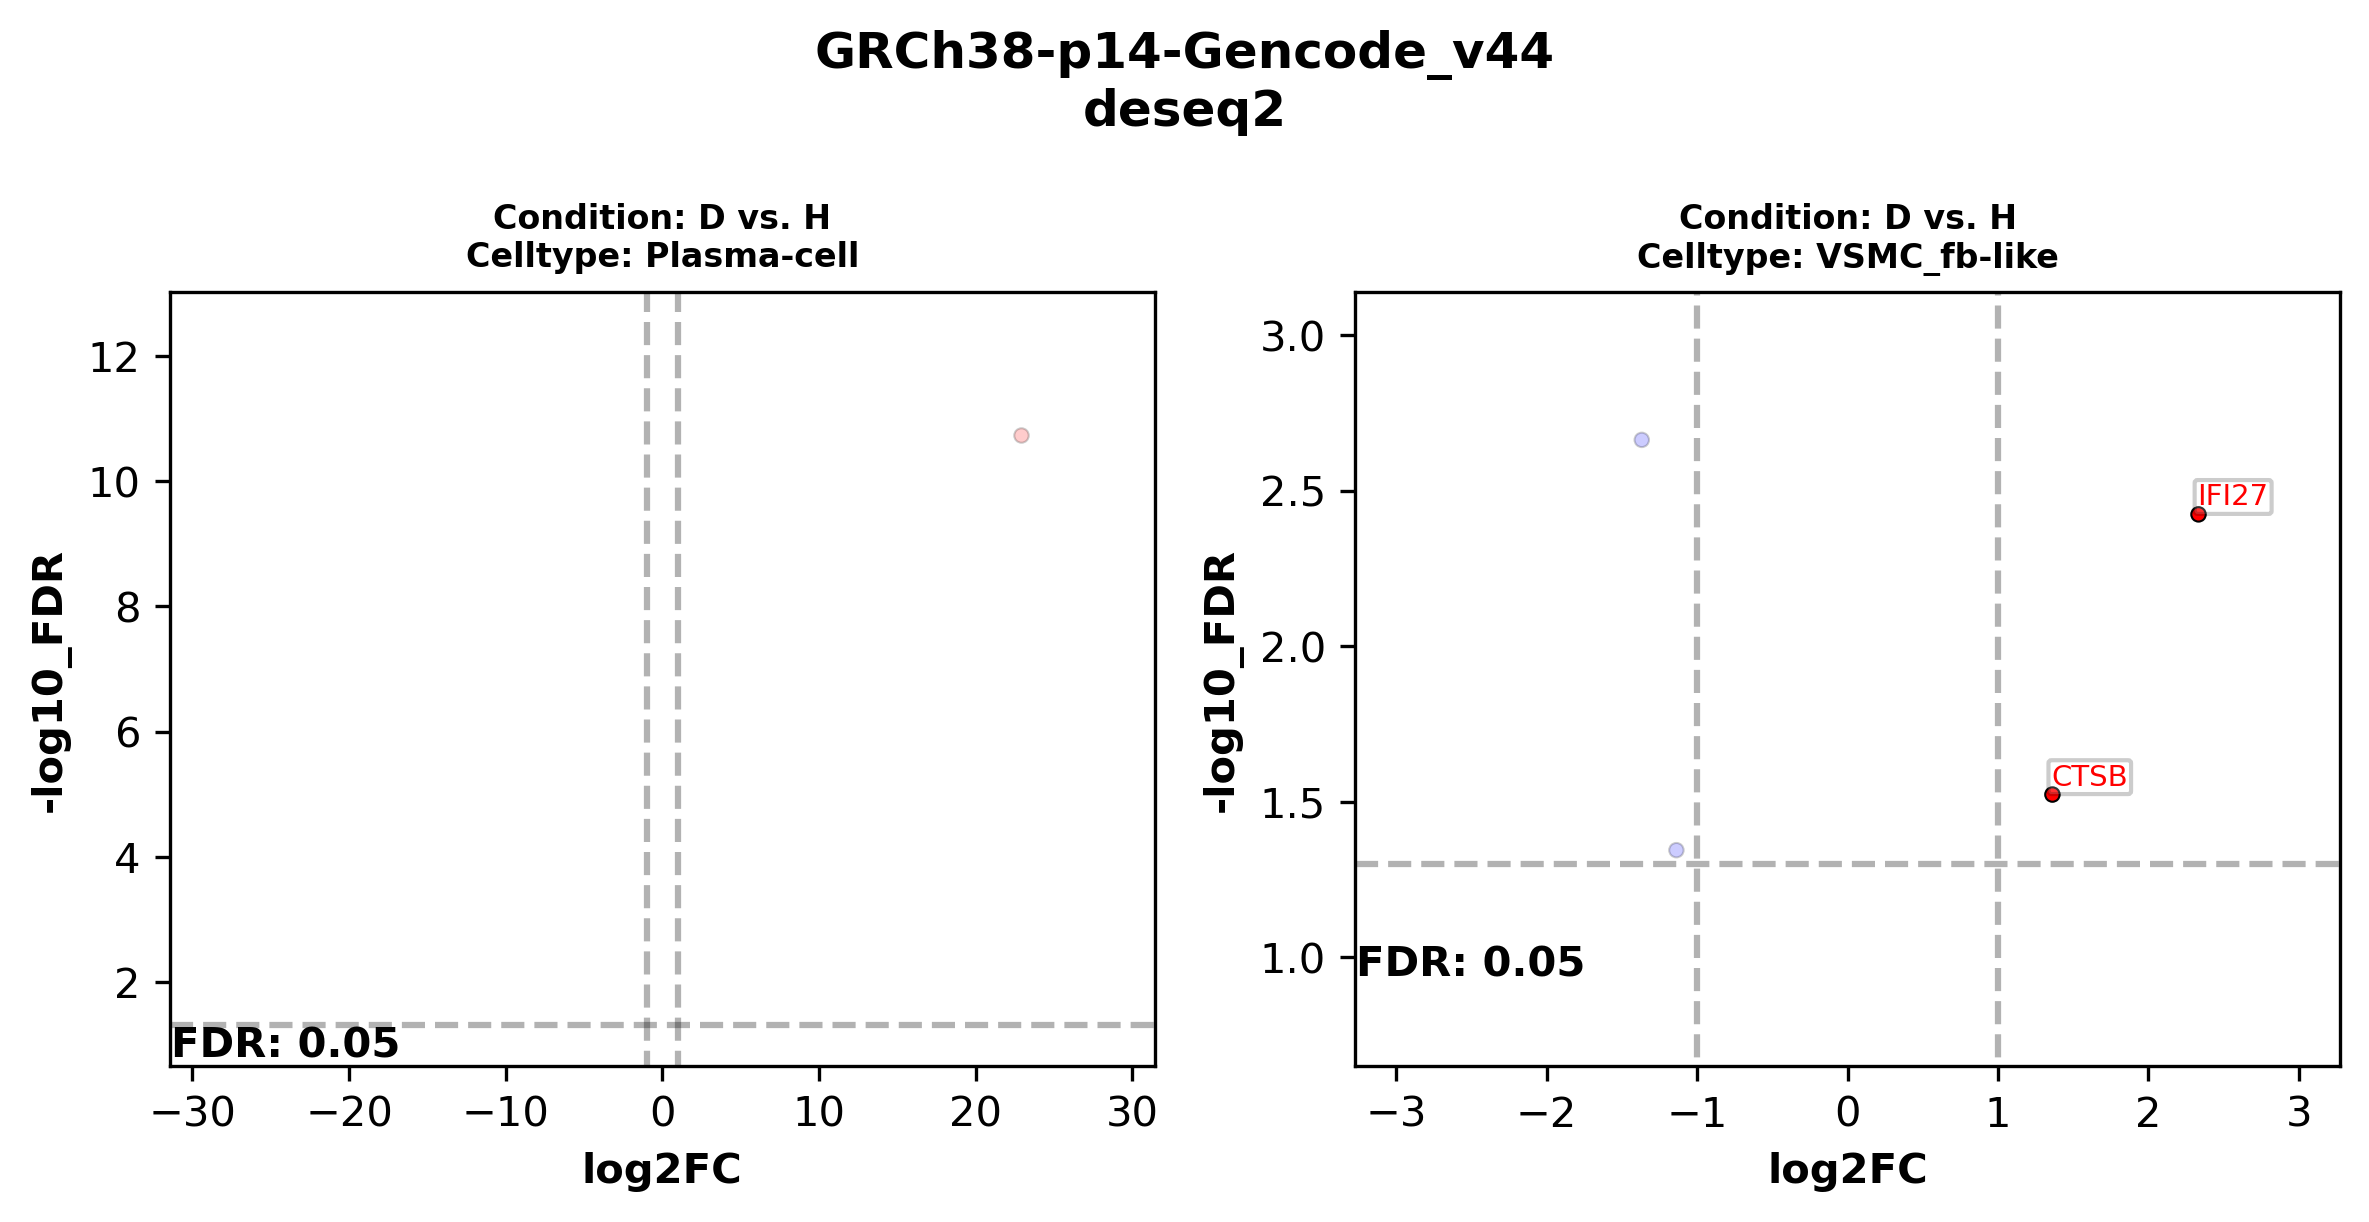

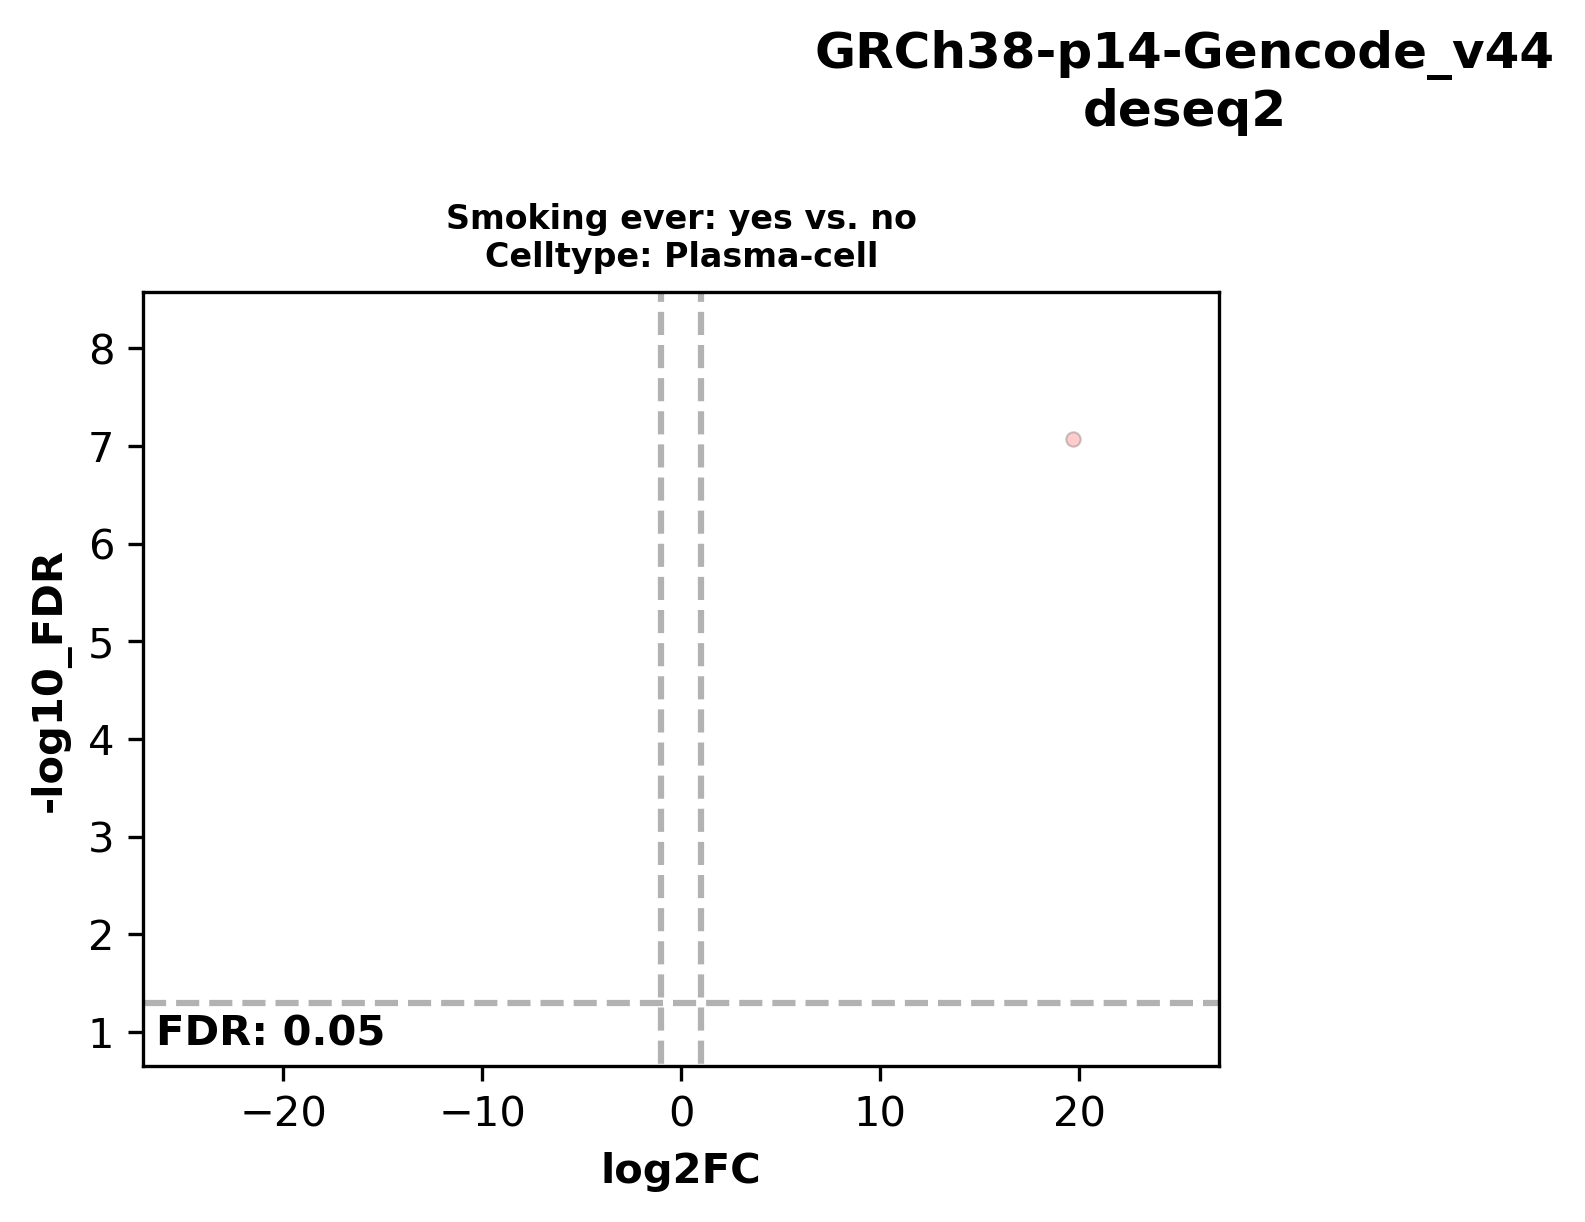

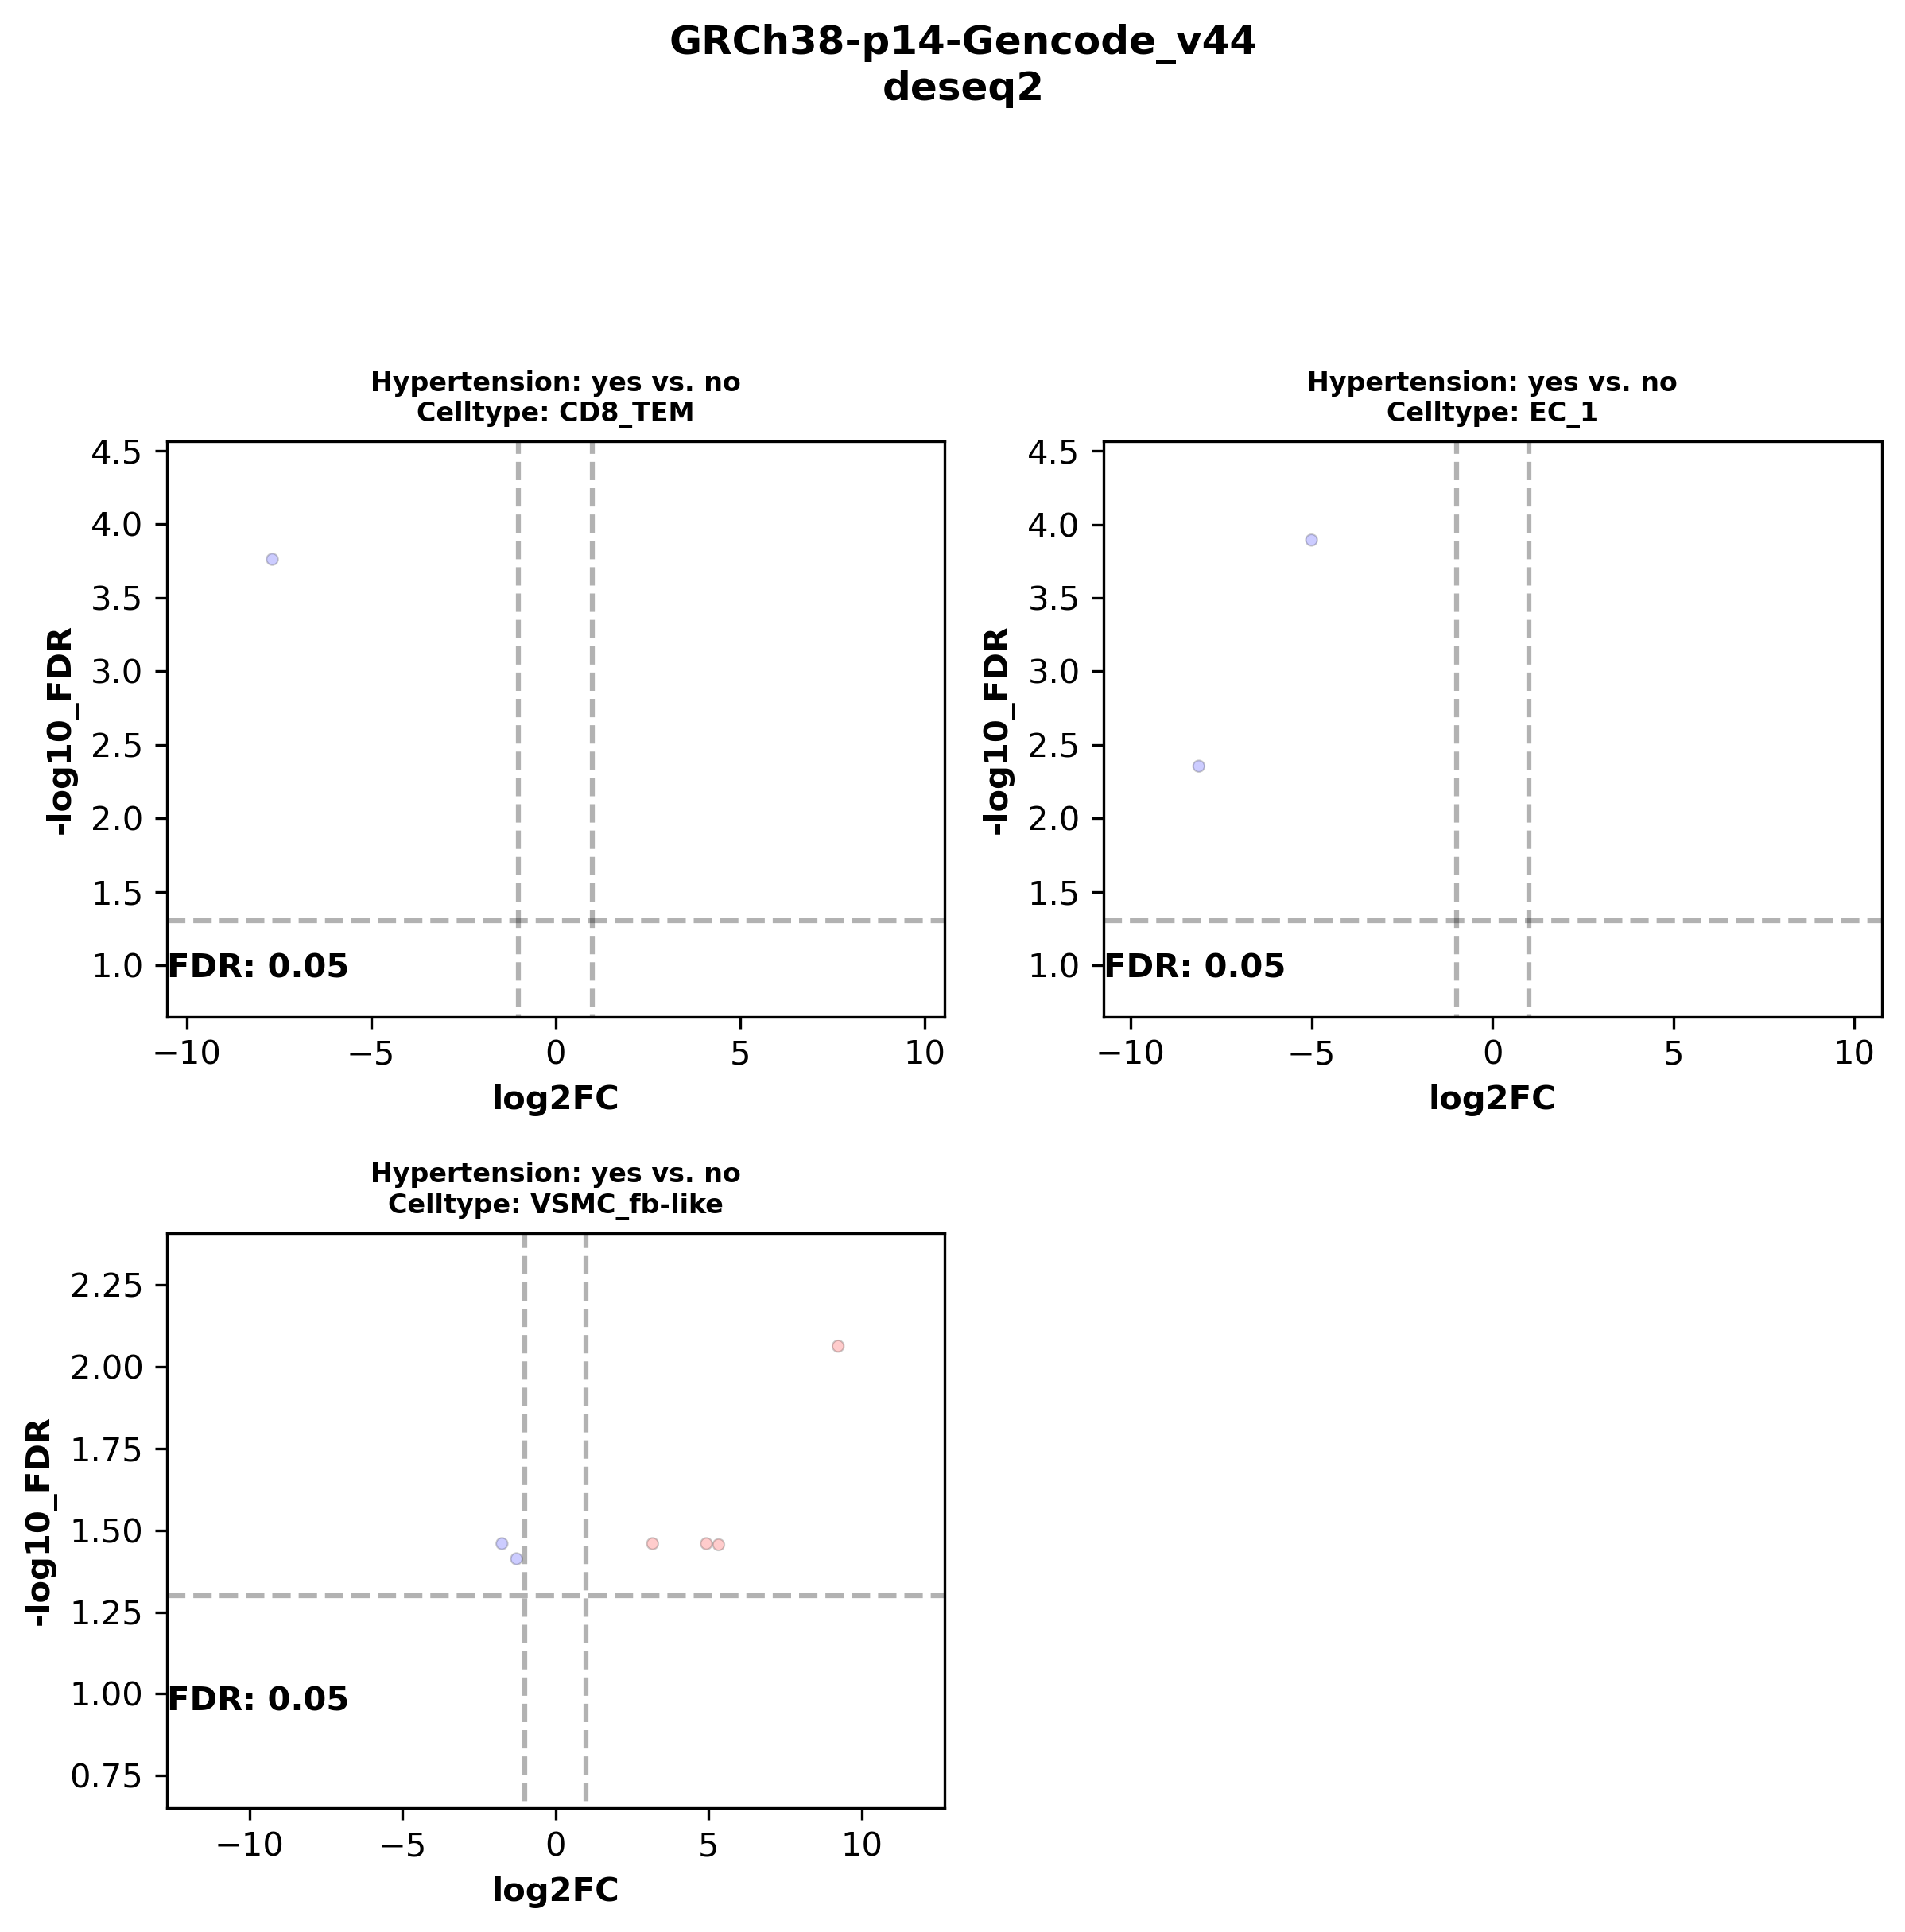

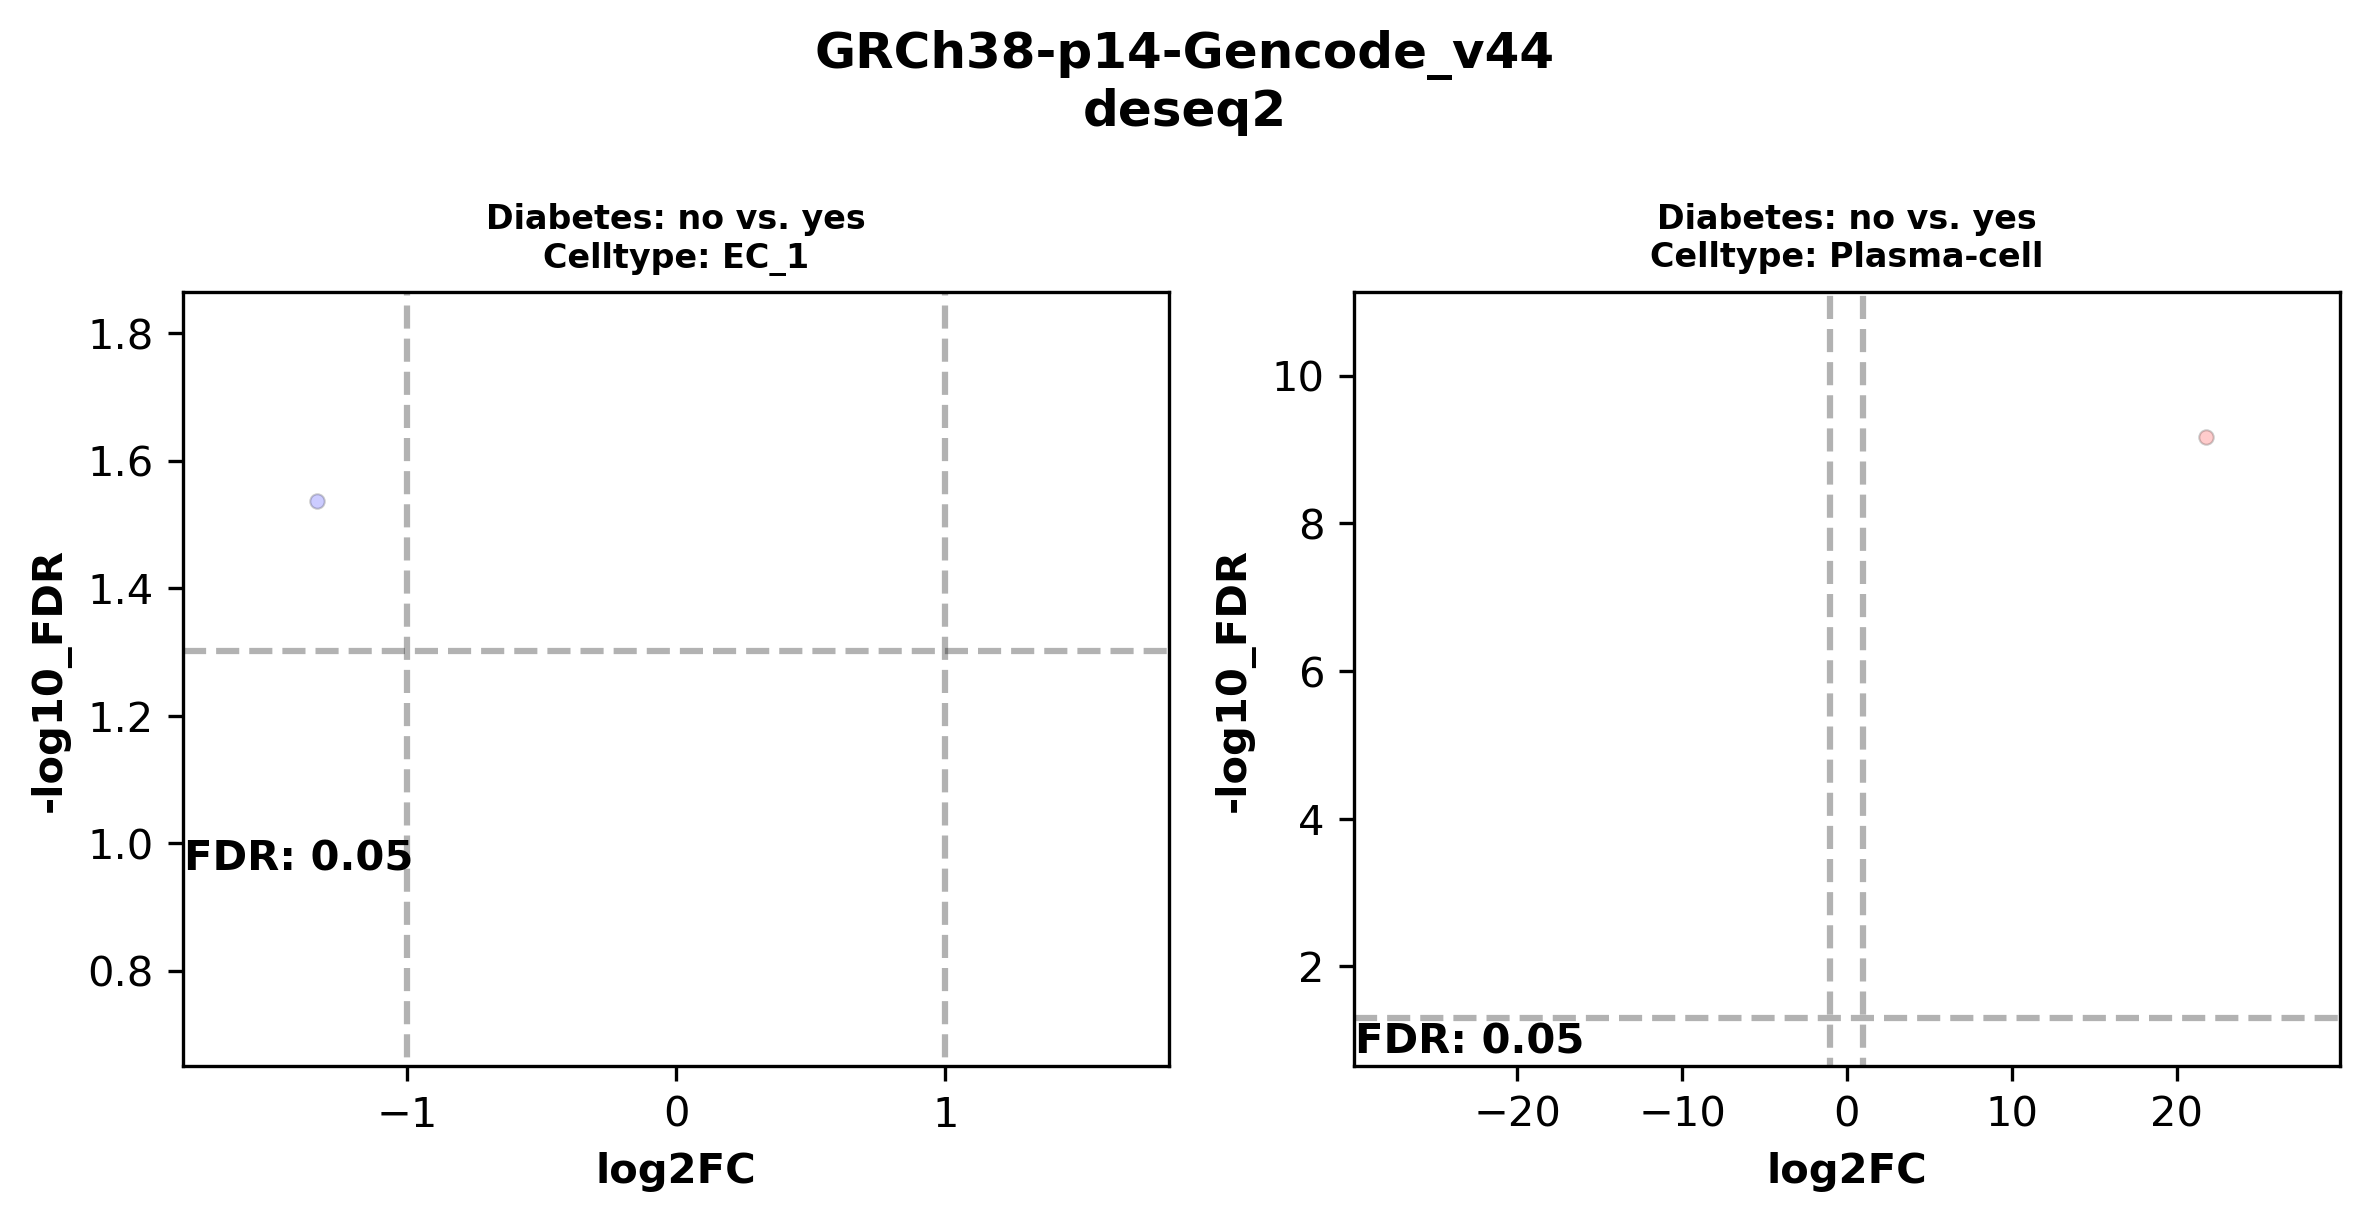

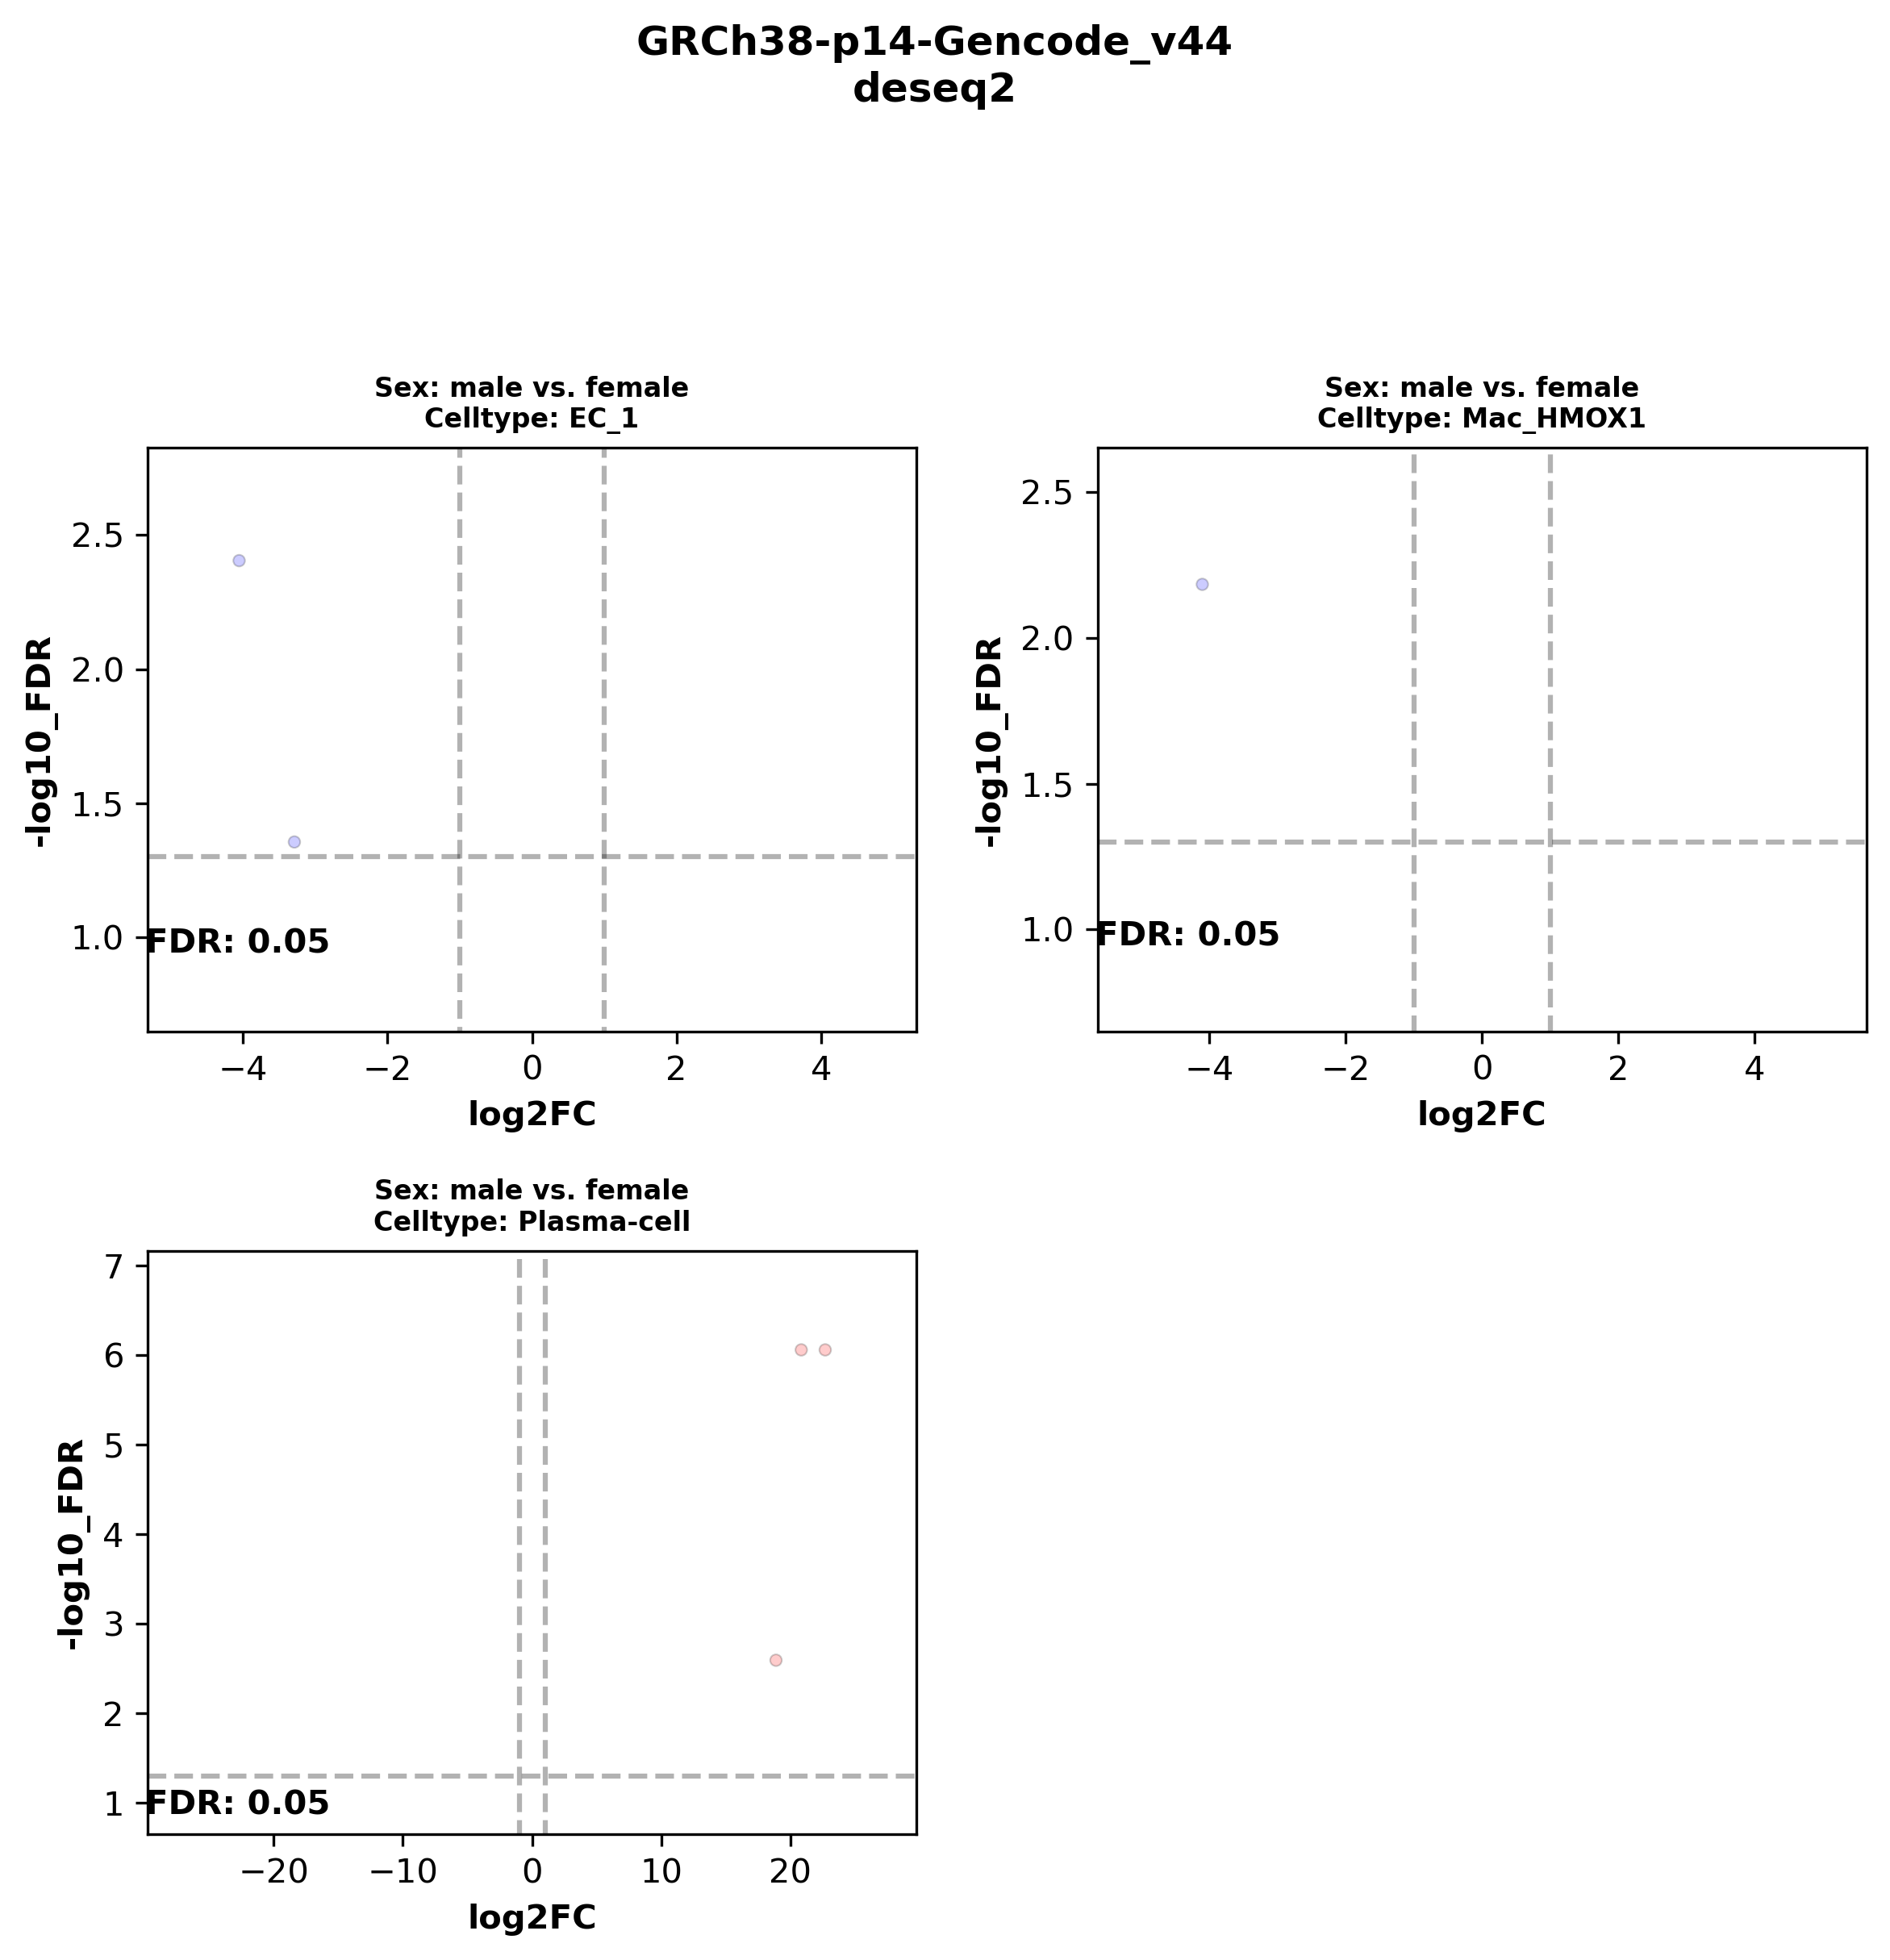

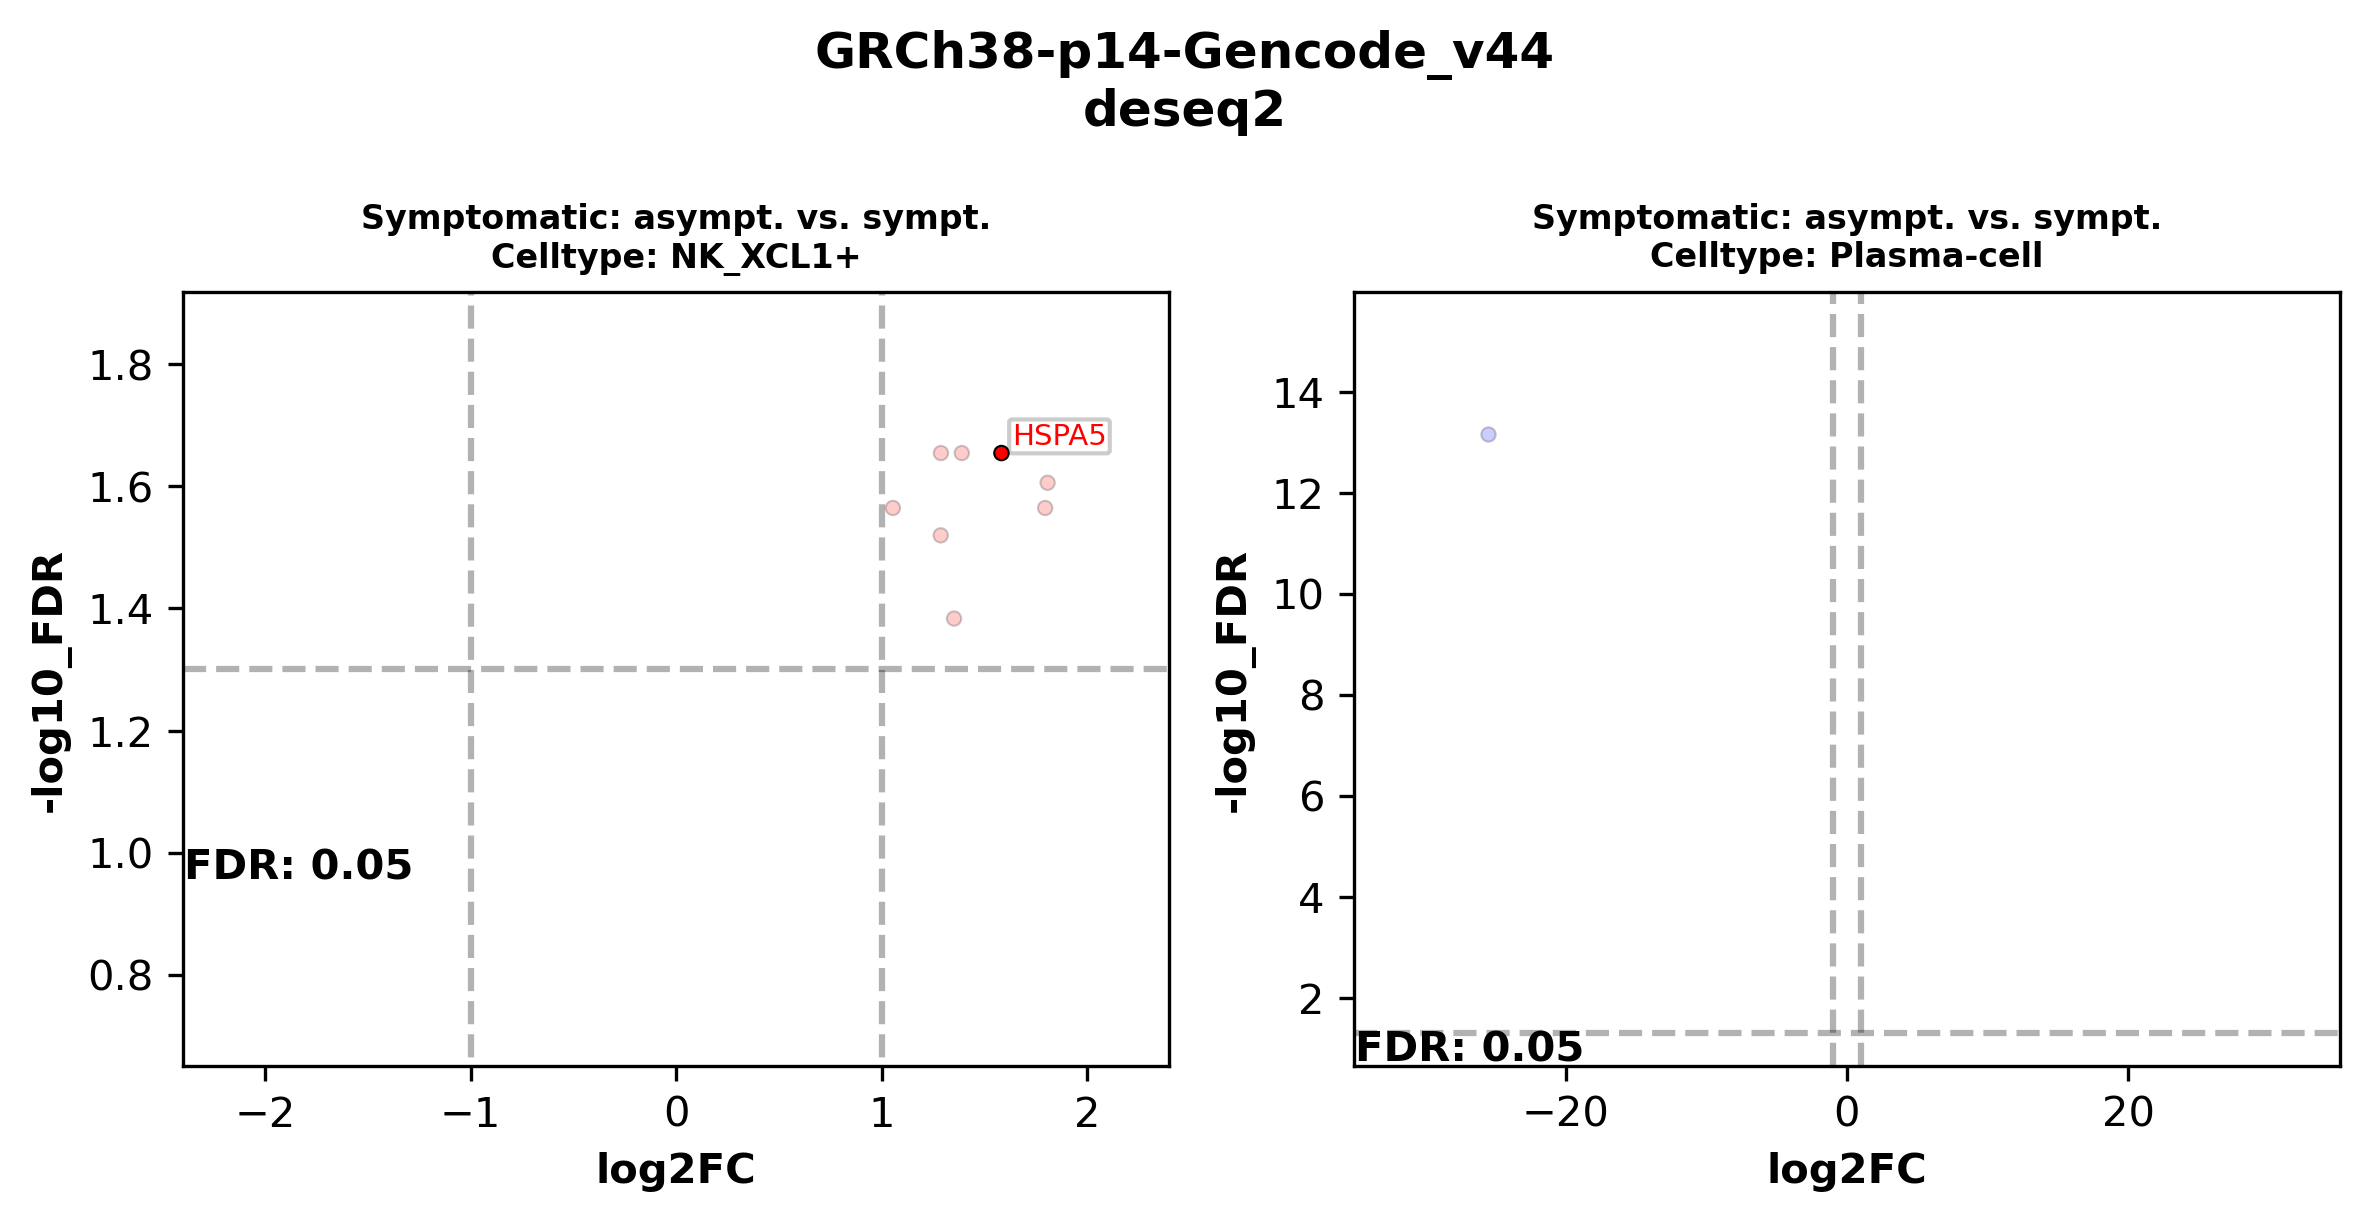

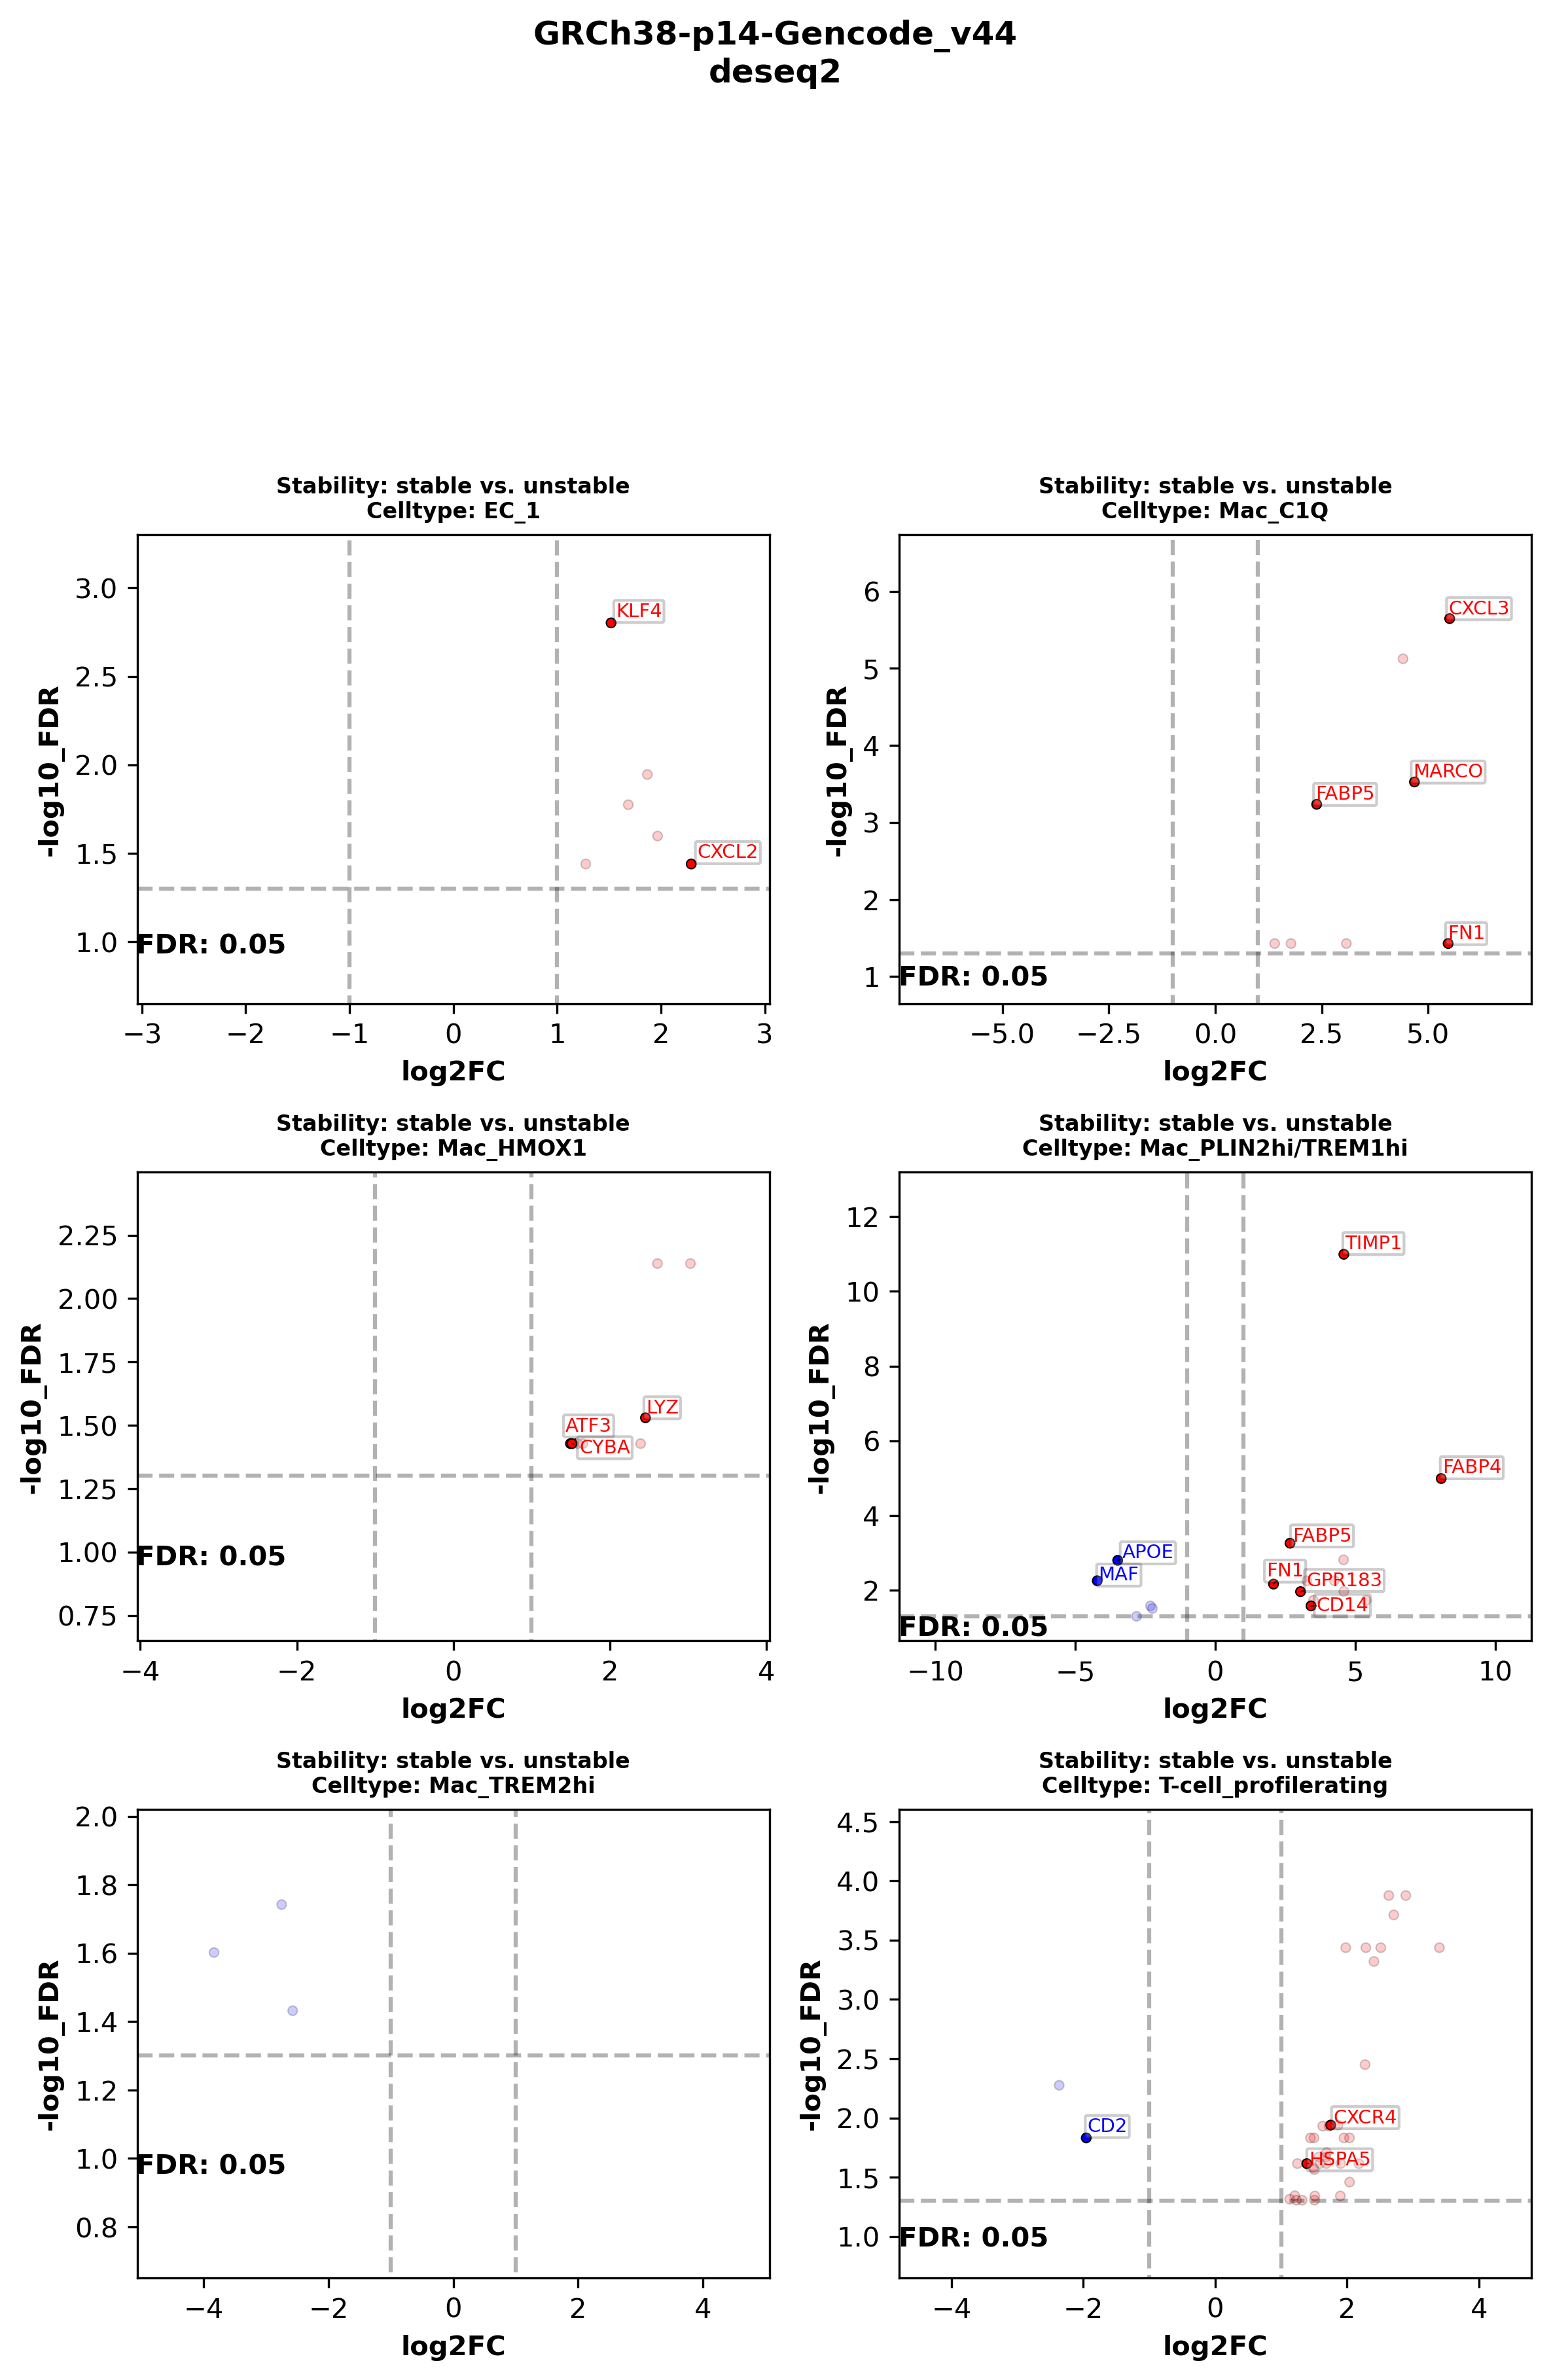

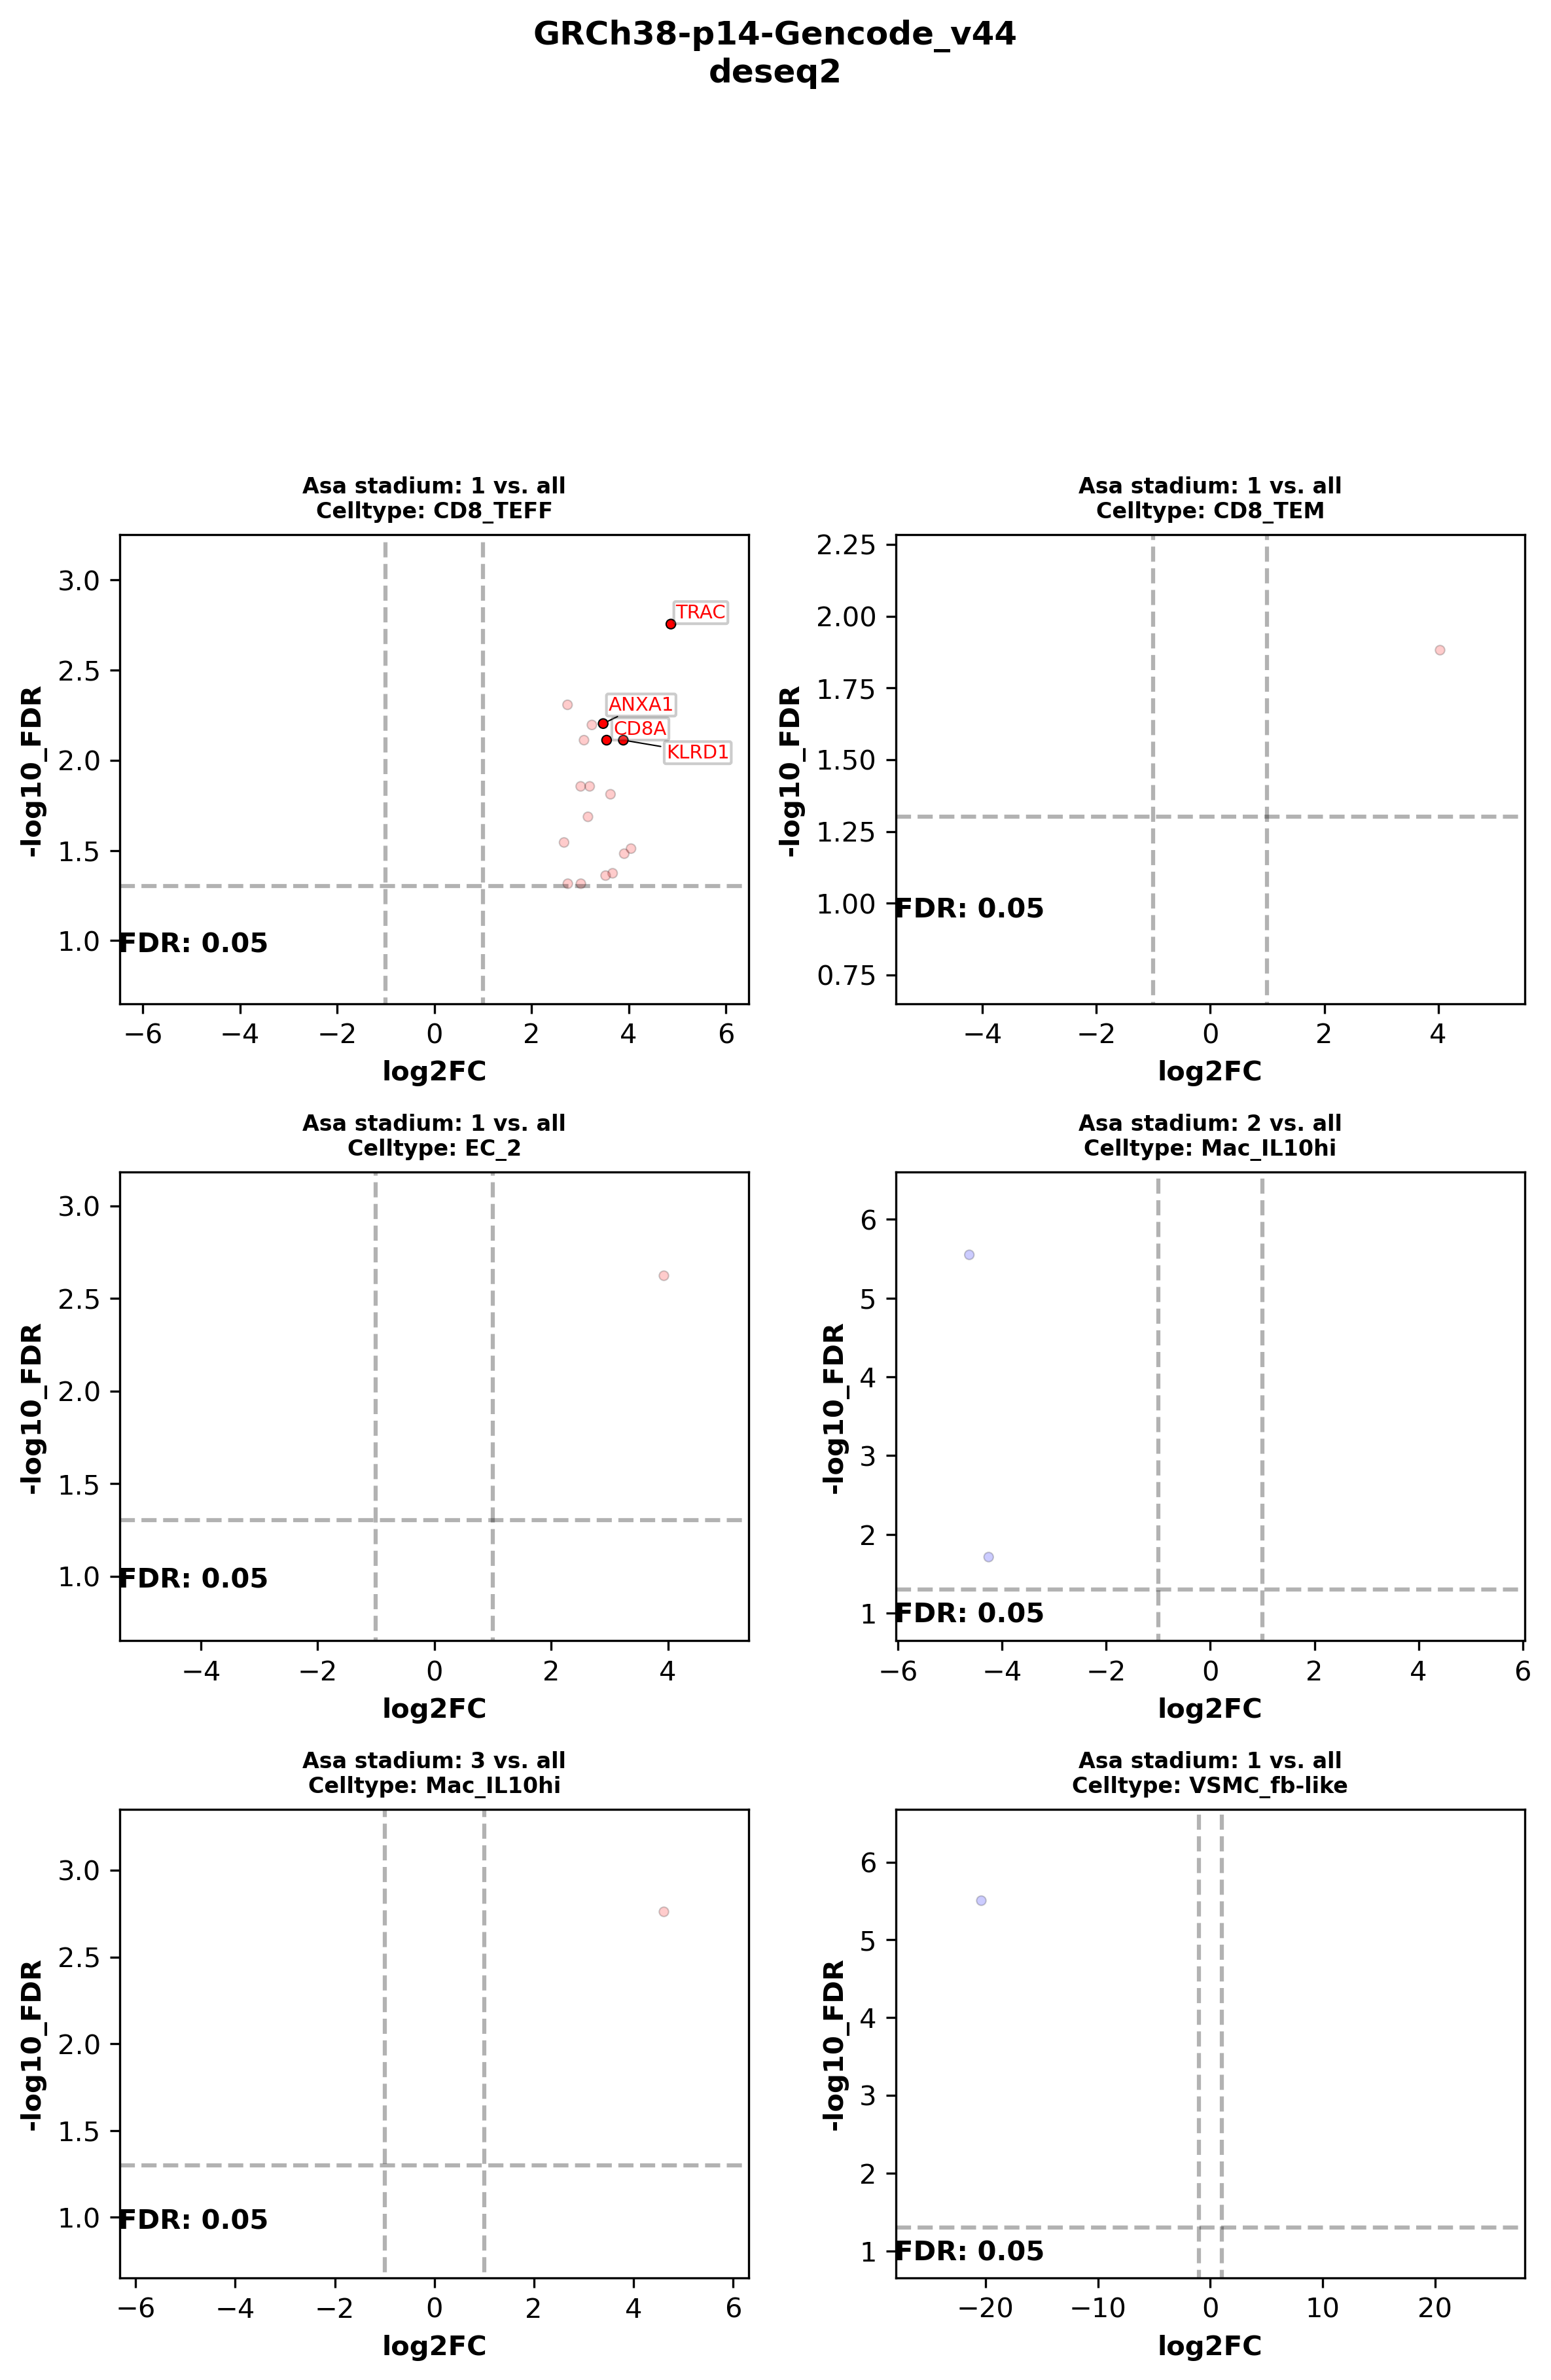

In [11]:
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

log2FC_thr=1
fdr_lev=0.05
padj_thr=-np.log10(fdr_lev)
dge_proc_dir='../../data/scRNA_DGE'


gene_info=pd.read_excel('../../xenium_data/Info about XENIUM panels_060923.xlsx')

## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'

de_methods=['deseq2','wilcoxon']
cellt_var='final_low_level_celltype'

coln_for_dge_list =['condition','Smoking_ever', 'AHA classification','Hypertension', 'Diabetes', 'Sex', 'Symptomatic', 'Stability', 'ASA_stadium',
                        'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation','PAD','Statin','Rupture',][:-1]


## Select which DG expressed gene names will be labelled on the volcano plot
#  ==> top_n_genes: top n genes with highest -log10FDR values in both down & upregulated directions
#. ==> overlapping_xenium: label DE genes, which are overlapping with the Xenium panels
gene_labelling='top_n_genes'
num_top_n_genes=5

gene_labelling='overlapping_xenium'

for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]
   
        #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
        
        ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
    
        for coln_for_dge in coln_for_dge_list[:]:
        #for coln_for_dge in ['Smoking_ever','Hypertension'][1:]:    
            print(coln_for_dge)
    
            if coln_for_dge!='condition':
                adata_=adata[#(~adata.obs['original_sample'].str.contains('_H'))\&
                            (~adata.obs[coln_for_dge].isna())\
                            ,:].copy()
    
            if coln_for_dge=='condition':
                adata_=adata[#adata.obs['patient'].isin(['P1','P2','P3','P4'])\&
                             (~adata.obs[coln_for_dge].isna()),:].copy()
            
            for de_method in de_methods[:1]:
                #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_dge_results.csv.gz')
                fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                try:
                    dge_df_concat=pd.read_csv(fn,index_col=0)
                except FileNotFoundError:
                    continue
    
                ncols=2
                nrows=int(np.ceil(len(dge_df_concat['celltype'].unique())/ncols))
                print(nrows,ncols)
                fig=plt.figure(figsize=(ncols*4,nrows*3.5))
                n=0
    
                x='log2FC'
                y='-log10_FDR'
                
                dge_df_concat['-log10_FDR']=-np.log10(dge_df_concat['padj'])
                x_axis_limit=max(abs(dge_df_concat[x].min()),abs(dge_df_concat[x].max()))*1.1
                y_axis_limit=dge_df_concat[y].max()*1.1
    
                #print('dge_df_concat',dge_df_concat.shape)
                for (celltype, celltype_df) in (dge_df_concat.groupby('celltype')): #.apply(lambda x:x)#sort_values(by=['padj'])
    
                    celltype_cells=adata_.obs.loc[(adata_.obs[cellt_var]==celltype),:]
    
                    clusts=celltype_df['cluster'].astype(str).unique().tolist()
                    clusts.sort()
    
                    #print(celltype)
                    #print(celltype_cells[coln_for_dge].value_counts())
                    #print(pd.crosstab(celltype_cells[coln_for_dge],celltype_cells['original_sample']))
                    #print()
                    for cluster in (clusts):
                    
                        #print(cluster)
                        #cluster=str(cluster)
                    
                        region_dge_df_concat=celltype_df[celltype_df['cluster']==(cluster)]
                        #print(region_dge_df_concat.shape)       
                        if region_dge_df_concat.shape[0]>0:
    
                            celltype_cluster_cells=adata_.obs.loc[(adata_.obs[coln_for_dge]==str(cluster))\
                                                                &(adata_.obs[cellt_var]==celltype),:]
        
                            #print(f"{celltype} cells: {celltype_cluster_cells.shape[0]} - Num of cells in clust {cluster}: - {celltype_cells.shape[0]} - ")
                            
                            
                            ax=fig.add_subplot(nrows,ncols,n+1)
    
                            ## Drop non-significant genes
                            region_dge_df_concat = region_dge_df_concat.loc[(np.abs(region_dge_df_concat['log2FC'])>log2FC_thr)\
                                                                            &(region_dge_df_concat['padj']<fdr_lev)\
                                                                            ,:]
        
                            ## ADD GENE NAME LABELS TO SELECTED GENES
                            if gene_labelling=='top_n_genes':
                                region_dge_df_concat['regulation_dir']=['down' if region_dge_df_concat['log2FC'].tolist()[n]<=0 else 'up' for n in range(len(region_dge_df_concat))]
                                gene_names_to_show=region_dge_df_concat.groupby('regulation_dir').apply(lambda x:x.sort_values(by=['padj'])['gene_hgnc'].tolist()[:num_top_n_genes])
                                gene_names_to_show = list(itertools.chain(*gene_names_to_show.values.flatten()))
        
                            if gene_labelling=='overlapping_xenium':
                                gene_names_to_show = region_dge_df_concat.loc[region_dge_df_concat['gene'].isin(gene_info['Ensembl ID']),'gene_hgnc'].tolist()
                                
                            
                            colors = region_dge_df_concat['log2FC'].apply(lambda x: 'red' if x > 0 else 'blue')
                            alphas= [1.0 if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show else 0.2 for i in range(len(region_dge_df_concat)) ]
                            scatter=ax.scatter(region_dge_df_concat[x],region_dge_df_concat[y],s=12,edgecolors='black',alpha=alphas,linewidths=0.5,c=colors)
                        
                            #ax.axvline(log2FC_thr,)
                            
                            
                            #ax.set_xlim(-x_axis_limit,x_axis_limit)
                            #ax.set_ylim(padj_thr*0.5,y_axis_limit)
                            y_axis_limit=ax.get_ylim()[1]*1.15
                            ax.set_ylim(padj_thr*0.5,y_axis_limit)
                            #ax.set_xlim(-x_axis_limit,x_axis_limit)
                            x_axis_limit=np.max(np.abs(ax.get_xlim()))*1.3
                            ax.set_xlim(-x_axis_limit,x_axis_limit)
    
                            ax.vlines(x=[-log2FC_thr,log2FC_thr], ymin=0,ymax=ax.get_ylim()[1],color='k', ls='--',alpha=0.3)
                            ax.axhline(padj_thr,color='k', ls='--',alpha=0.3)
                        
                            subplot_title=f"{coln_for_dge.replace('_',' ').capitalize()}: {cluster.replace('_',' ').replace('vs','vs.')}\nCelltype: {celltype}"
                            ax.set_title(subplot_title,fontweight='bold',fontsize=8)
                            ax.set_xlabel(x,fontweight='bold')
                            ax.set_ylabel(y,fontweight='bold')
                        
                            #x_axis_limit=max(abs(region_dge_df_concat[x].min()),abs(region_dge_df_concat[x].max()))*1.05
                            
        
                            '''
                            texts=[ax.text(x=region_dge_df_concat[x].tolist()[n],
                                           y=region_dge_df_concat[y].tolist()[n],
                                           s=region_dge_df_concat['gene_hgnc'].tolist()[n]) for n in range(len(region_dge_df_concat)) \
                                                                                            if region_dge_df_concat['gene_hgnc'].tolist()[n] in gene_names_to_show]
    
                            '''
                            texts = [
                                ax.text(
                                    x=region_dge_df_concat[x].iloc[i],
                                    y=region_dge_df_concat[y].iloc[i],
                                    fontsize=7,
                                    s=region_dge_df_concat['gene_hgnc'].iloc[i],
                                    color='red' if region_dge_df_concat['log2FC'].iloc[i] > 0 else 'blue',  # Set label color
                                    bbox=dict(
                                        boxstyle="round,pad=0.1",
                                        edgecolor="black",
                                        facecolor="white",
                                        alpha=0.2
                                    )  # Add bounding box
                                )
           
                                for i in range(len(region_dge_df_concat))
                                if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show
                            ]
        
                            ## Add text of FDR line
                            ax.text(-x_axis_limit*0.75,padj_thr*0.75,f'FDR: {fdr_lev} ',fontsize=10,fontweight='bold',
                                    rotation=0,horizontalalignment='center', 
                                    verticalalignment='center',rotation_mode='default')
                            
                            adjust_text(texts,arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
                        
                            #plt.grid()
                            plt.tight_layout()
                            fig.suptitle(f"{ref_genome}\n{de_method}",fontweight='bold',fontsize=12,y=1.15)
                            n=n+1
                                        
                            dge_proc_dir_='../../data/scRNA_DGE/volcano_plots'
                            os.makedirs(dge_proc_dir_,exist_ok=True)
                            #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                            fn=os.path.join(dge_proc_dir_,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{coln_for_dge}_dge_volcano_plot.png')
                            
                            plt.subplots_adjust(top=0.9)
                            plt.savefig(fn, bbox_inches='tight')
                            #plt.close(fig)
                                
                        
                

#### Suppl.FIG.E

In [ ]:
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)


gene_info=pd.read_excel('../../xenium_data/Info about XENIUM panels_060923.xlsx')


log2FC_thr=0.5
fdr_lev=0.05
padj_thr=-np.log10(fdr_lev)
dge_proc_dir='../../data/scRNA_DGE'

## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'

de_methods=['deseq2','wilcoxon']
cellt_var='final_low_level_celltype'

coln_for_dge_list =['condition','Stability','Smoking_ever', 
                    'AHA classification',
                    'Hypertension', 'Diabetes', 'Sex', 
                    'Symptomatic',  'ASA_stadium',
                    'Dyslipidemia', 'CHD', 
                    'Myocardial infarction', 
                    'Atrial fibrillation','PAD',
                    'Statin','Rupture',][:2]

#coln_for_dge_list=['Dyslipidemia', 'CHD', 
#                    'Myocardial infarction', 
#                    'Atrial fibrillation','PAD',
#                    'Statin','Rupture',][:]

## Select which DG expressed gene names will be labelled on the volcano plot
#  ==> top_n_genes: top n genes with highest -log10FDR values in both down & upregulated directions
#. ==> overlapping_xenium: label DE genes, which are overlapping with the Xenium panels
gene_labelling='top_n_genes'
num_top_n_genes=5

gene_labelling='overlapping_xenium'


for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
        adata=adata_dict[intron_status][ref_genome]
        #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
        
        ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
    
        for coln_for_dge in coln_for_dge_list[:]:
        #for coln_for_dge in ['Smoking_ever','Hypertension'][1:]:    
            print(coln_for_dge)
    
            if coln_for_dge!='condition':
                adata_=adata[#(~adata.obs['original_sample'].str.contains('_H'))\&
                            (~adata.obs[coln_for_dge].isna())\
                            ,:].copy()
    
            if coln_for_dge=='condition':
                adata_=adata[#adata.obs['patient'].isin(['P1','P2','P3','P4'])\&
                             (~adata.obs[coln_for_dge].isna()),:].copy()
            
            for de_method in de_methods[:1]:
                #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_dge_results.csv.gz')
                #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                try:
                    dge_df_concat=pd.read_csv(fn,index_col=0)
                except FileNotFoundError:
                    continue

                ## If condition is the colname, swap the comparison from vontrol vs plaque to plaque vs control, to match comparison in scRNA data
                if dge_df_concat['cluster'].unique()[0]=='no_vs_yes':
                    dge_df_concat['log2FC']=dge_df_concat['log2FC'] * -1
                    dge_df_concat['cluster']='yes_vs_no'


                if coln_for_dge=='Stability':
                    ncols=3
                if coln_for_dge=='condition':
                    ncols=2
                    
                nrows=int(np.ceil(len(dge_df_concat['celltype'].unique())/ncols))
                print(nrows,ncols)
                fig=plt.figure(figsize=(ncols*3.5,nrows*2.8))
                n=0
    
                x='log2FC'
                y='-log10_FDR'
                
                dge_df_concat['-log10_FDR']=-np.log10(dge_df_concat['padj'])
                x_axis_limit=max(abs(dge_df_concat[x].min()),abs(dge_df_concat[x].max()))*1.1
                y_axis_limit=dge_df_concat[y].max()*1.1
    
                #print('dge_df_concat',dge_df_concat.shape)
                for (celltype, celltype_df) in (dge_df_concat.groupby('celltype')): #.apply(lambda x:x)#sort_values(by=['padj'])
    
                    celltype_cells=adata_.obs.loc[(adata_.obs[cellt_var]==celltype),:]

                    if celltype_cells.shape[0]<10:
                        print(f"Skipping {celltype} due to low number of cells:{celltype_cells.shape[0]}")
                        continue

                    ## IF there are two categories and there is a strong imbalance
                    if celltype_cells[coln_for_dge].unique().shape[0]==2 and np.any((celltype_cells[coln_for_dge].value_counts(normalize=True)<0.1).values):
                        print(f"Skipping {celltype} due to low number of cells in one category:{celltype_cells[coln_for_dge].value_counts(normalize=False)}")
                        continue
                        
                    
                    celltype_df['cluster']=celltype_df['cluster'].replace('D_vs_H','plaque_vs_control')
                    
                    clusts=celltype_df['cluster'].astype(str).unique().tolist()
                    clusts.sort()
    
                    
                    ### SAVE SOURCE DATA FOR PLOT 
                    source_df = dge_df_concat.loc[(np.abs(dge_df_concat['log2FC'])>log2FC_thr)\
                              &(dge_df_concat['padj']<fdr_lev),:]
                    source_df['cluster'] = source_df['cluster'].replace('D_vs_H','plaque_vs_control')
                    source_df = source_df[['log2FC','padj','gene_hgnc','celltype','-log10_FDR']]
                    source_df.columns=['log2_fold_change','FDR','Gene_name_HGNC','final_low_level_celltype','-log10_FDR']
                    
                    source_dir=os.path.join(proc_dir,'source_data','first_revision')
                    os.makedirs(source_dir,exist_ok=True)
                
                    if coln_for_dge=='condition':                        
                        fn=os.path.join(source_dir,'Suppl_Fig1.xlsx')
                    
                    if coln_for_dge=='Stability':                        
                        fn=os.path.join(source_dir,'Suppl_FigX4.xlsx')
                    
                    source_df.to_excel(fn)

                    
                    ## PLOT  
                    for cluster in (clusts):
                    
                        #print(cluster)
                        #cluster=str(cluster)
                    
                        region_dge_df_concat=celltype_df[celltype_df['cluster']==(cluster)]
                        #print(region_dge_df_concat.shape)       
                        if region_dge_df_concat.shape[0]>0:
    
                            celltype_cluster_cells=adata_.obs.loc[(adata_.obs[coln_for_dge]==str(cluster))\
                                                                &(adata_.obs[cellt_var]==celltype),:]
        
                            #print(f"{celltype} cells: {celltype_cluster_cells.shape[0]} - Num of cells in clust {cluster}: - {celltype_cells.shape[0]} - ")
                            
                            
                            ax=fig.add_subplot(nrows,ncols,n+1)
    
                            ## Drop non-significant genes
                            region_dge_df_concat = region_dge_df_concat.loc[(np.abs(region_dge_df_concat['log2FC'])>log2FC_thr)\
                                                                             &(region_dge_df_concat['padj']<fdr_lev)\
                                                                            ,:]
        
                            ## ADD GENE NAME LABELS TO SELECTED GENES
                            if gene_labelling=='top_n_genes':
                                region_dge_df_concat['regulation_dir']=['down' if region_dge_df_concat['log2FC'].tolist()[n]<=0 else 'up' for n in range(len(region_dge_df_concat))]
                                gene_names_to_show=region_dge_df_concat.groupby('regulation_dir').apply(lambda x:x.sort_values(by=['padj'])['gene_hgnc'].tolist()[:num_top_n_genes])
                                gene_names_to_show = list(itertools.chain(*gene_names_to_show.values.flatten()))
        
                            if gene_labelling=='overlapping_xenium':
                                gene_names_to_show = region_dge_df_concat.loc[region_dge_df_concat['gene'].isin(gene_info['Ensembl ID']),'gene_hgnc'].tolist()
                                
                            
                            colors = region_dge_df_concat['log2FC'].apply(lambda x: 'red' if x > 0 else 'blue')
                            alphas= [1.0 if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show else 0.2 for i in range(len(region_dge_df_concat)) ]
                            scatter=ax.scatter(region_dge_df_concat[x],region_dge_df_concat[y],s=12,edgecolors='black',alpha=alphas,linewidths=0.5,c=colors)
                        
                            #ax.axvline(log2FC_thr,)
                            
                            
                            #ax.set_xlim(-x_axis_limit,x_axis_limit)
                            #ax.set_ylim(padj_thr*0.5,y_axis_limit)
                            y_axis_limit=ax.get_ylim()[1]*1.15
                            ax.set_ylim(padj_thr*0.5,y_axis_limit)
                            #ax.set_xlim(-x_axis_limit,x_axis_limit)
                            x_axis_limit=np.max(np.abs(ax.get_xlim()))*1.3
                            ax.set_xlim(-x_axis_limit,x_axis_limit)
    
                            ax.vlines(x=[-log2FC_thr,log2FC_thr], ymin=0,ymax=ax.get_ylim()[1],color='k', ls='--',alpha=0.3)
                            ax.axhline(padj_thr,color='k', ls='--',alpha=0.3)
    
                        
                            subplot_title=f"{coln_for_dge.replace('_',' ').capitalize()}: {cluster.replace('_',' ').replace('vs','vs.')}\nCelltype: {celltype}"
                            ax.set_title(subplot_title,fontweight='bold',fontsize=8)
                            ax.set_xlabel(r'$\mathbf{log_2 \, Fold \, change}$' ,)#fontweight='bold')
                            ax.set_ylabel(r'$\mathbf{-log_{10} \, FDR}$',)#fontweight='bold')
                        
                            #x_axis_limit=max(abs(region_dge_df_concat[x].min()),abs(region_dge_df_concat[x].max()))*1.05
                            
        
                            '''
                            texts=[ax.text(x=region_dge_df_concat[x].tolist()[n],
                                           y=region_dge_df_concat[y].tolist()[n],
                                           s=region_dge_df_concat['gene_hgnc'].tolist()[n]) for n in range(len(region_dge_df_concat)) \
                                                                                            if region_dge_df_concat['gene_hgnc'].tolist()[n] in gene_names_to_show]
    
                            '''
                            texts = [
                                ax.text(
                                    x=region_dge_df_concat[x].iloc[i],
                                    y=region_dge_df_concat[y].iloc[i],
                                    fontsize=7,
                                    s=region_dge_df_concat['gene_hgnc'].iloc[i],
                                    color='red' if region_dge_df_concat['log2FC'].iloc[i] > 0 else 'blue',  # Set label color
                                    bbox=dict(
                                        boxstyle="round,pad=0.1",
                                        edgecolor="black",
                                        facecolor="white",
                                        alpha=0.2
                                    )  # Add bounding box
                                )
           
                                for i in range(len(region_dge_df_concat))
                                if region_dge_df_concat['gene_hgnc'].iloc[i] in gene_names_to_show
                            ]
        
                            ## Add text of FDR line
                            '''
                            ax.text(-x_axis_limit*0.9,y_axis_limit*0.9,
                                    f'FDR thr.: {fdr_lev}\nlog2FC thr.:\u00B1{log2FC_thr}',fontsize=8,#fontweight='bold',
                                    rotation=0,horizontalalignment='left', 
                                    verticalalignment='center',rotation_mode='default')
                            '''                                
                            
                            adjust_text(texts,arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
                        
                            #plt.grid()
                            plt.tight_layout()
                            #fig.suptitle(f"{ref_genome}\n{de_method}",fontweight='bold',fontsize=12,y=1.15)
                            n=n+1
                                        
    
                            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
                            save_dir_=os.path.join(proc_dir,'figure_plots','SFigE','scRNA_DGE_volcano_plots')
                            os.makedirs(save_dir_,exist_ok=True)
                            fn=os.path.join(save_dir_,
                                            f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{coln_for_dge}_dge_volcano_plot.png')
                            fig.savefig(fn, dpi=300, bbox_inches='tight')
                        
      
                        
                

# CREATE FINAL DATASET FOR PUBLICATION

## Final columns names

In [5]:
final_colname_descr={'background_fraction':'Cellbender background fraction.',
                     'cell_probability':'Cellbender cell probability.',
                     'droplet_efficiency':'Cellbenderdroplet_efficiency',    
                     'patient':'Patient ID.',
                     'condition':'Sample condition (plaque or control)',
                     'batch':'Sample preprocessing batch number.',
                     'ribo_frac':'Ribosomal transcript fraction.',
                     'mt_frac':'Mitochondrial transcript fraction.',
                     'original_sample':'Original sample of cell, concatenated as the patient ID and sample condition (plaque or control).',
                     'scDblFinder.class':'Doublet class, as determined by scDblFinder.',
                     'scDblFinder.score':'Doublet score, as determined by scDblFinder.',
                     'preparation_kit':'Preparation kit used for library preparation.',
                     'Age':'Patient age.',
                     'Sex':'Patient sex.',
                     'Hypertension':'Presence of hypertension in patient.',
                     'AHA classification':'Classification of plaque per the American Heart Association.',
                     'Diabetes':'Presence of diabetes in patient.',
                     'Smoking':'Smoking status of patient.',
                     'Dyslipidemia':'Presence of dyslipidemia in patient.',
                     'CHD':'Presence of coronary heart disease  in patient.',
                     'BMI':'Body-mass-index of patient.',
                     'Statin':'Statin therapy applied in patient.',
                     'seq_facility':'Facility performing sequencing.',
                                   
                     'Symptomatic':'Variable describing if patient presented symptoms caused by plaque.',
                     'Rupture':'Occurrence of rupture in given sample.',
                     
                     'Stenosis_perc':'% of arterial narrowing.',
                     'Height':'Height of patient in centimeters.',
                     'Weight':'Weight of patient in kilograms.',
                     'Smoking_ever':"Composite label, with current or ex-smokers indicated as 'yes', patients who never smoked with 'no'.",
                     'Myocardial infarction':'Occurrence of previous heart attack in patient.',
                     'Atrial fibrillation':'Presence of atrial fibrillation in patient.',

                     'PAD':'Presence of peripheral artery disease in patient.',

                     'ASA_stadium':'Classification of patient physical status per the American Society of Anaesthesiologists.',
                     'Symptoms':'Description of symptoms caused by plaque in patient.',
                     'final_low_level_celltype':'Final low level celltype, representing main cell identities.',
                     'final_high_level_celltype':'Final low level celltype, representing known subtypes within major identities.',
                    }


def create_readme(column_dict, output_file=None, title="Data Dictionary"):
    """
    Create a README.md file from a column description dictionary.

    Parameters
    ----------
    column_dict : dict
        Dictionary with column names as keys and descriptions as values.
    output_file : str
        Name of the output markdown file.
    title : str
        Title to include at the top of the README.
    """

    with open(output_file, "w") as f:
        f.write(f"# {title}\n\n")
        f.write("This file provides a description of each column in the dataset.\n\n")
        f.write("| Column Name | Description |\n")
        f.write("|-------------|-------------|\n")
        
        for key, value in column_dict.items():
            f.write(f"| `{key}` | {value} |\n")

    print(f"{output_file} file created successfully as '{output_file}'")


def create_readme_bullet(column_dict, output_file="README.md", title="Data Dictionary"):
    """
    Create a README.md file with bullet-formatted column descriptions.

    Parameters
    ----------
    column_dict : dict
        Dictionary with column names as keys and descriptions as values.
    output_file : str
        Name of the output markdown file.
    title : str
        Title to include at the top of the README.
    """

    with open(output_file, "w") as f:
        f.write(f"# {title}\n\n")
        f.write("Below is a list of columns included in this dataset along with their descriptions:\n\n")

        for key, value in column_dict.items():
            f.write(f"- **{key}**: {value}\n")

    print(f"README.md file created successfully as '{output_file}'")

# Run the function
proc_dir_final='../../data/scRNA_final_dataset'
os.makedirs(proc_dir_final,exist_ok=True)
fn=os.path.join(proc_dir_final,f'scRNA_data_column_descriptions.md')
create_readme_bullet(final_colname_descr,
              output_file=fn)



README.md file created successfully as '../../data/scRNA_final_dataset/scRNA_data_column_descriptions.md'


## Save final Anndata file

In [34]:
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']


for intron_status in ['with_intron','without_intron'][:1]:  

    
    for ref_genome in ref_genomes[:1]:
        adata = adata_dict[intron_status][ref_genome]

        adata.obs['condition'] = adata.obs['condition'].replace({'D':'Plaque','H':'Control'}).values
        adata.obs['original_sample'] = adata.obs['original_sample'].astype(str).replace({'_D':'_Plaque','_H':'_Control'},regex=True).values
        adata.obs=adata.obs.rename(columns={'Size':'Height'})

        proc_dir_final='../../data/scRNA_final_dataset'
        os.makedirs(proc_dir_final,exist_ok=True)
        fn=os.path.join(proc_dir_final,
                        f'{ref_genome}_{intron_status}_final_data.h5ad')

        adata_=adata.copy()
        final_colnames = list(final_colname_descr.keys())
        adata_.obs=adata_.obs.loc[:,final_colnames]
        adata_.write(fn,compression='gzip')
